In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os
import sys
sys.path.append("../src")
import NoInterNet_model as NIN
import NoInterNet_fraction_model as NINf
import importlib
import NoLIMItNet_utils as NLIM
importlib.reload(NLIM)

import torch

from torch.utils.data import DataLoader
from torch import nn

In [2]:
from matplotlib.pyplot import rc
import matplotlib.font_manager
rc('font',**{'size':'22','family':'serif','serif':['CMU serif']})
rc('mathtext', **{'fontset':'cm'})
rc('text', usetex=True)
rc('legend',**{'fontsize':'18'})
matplotlib.rcParams['axes.linewidth'] = 1.5
matplotlib.rcParams['axes.labelsize'] = 20
matplotlib.rcParams['xtick.labelsize'] = 15
matplotlib.rcParams['ytick.labelsize'] = 15
matplotlib.rcParams['legend.fontsize'] = 15
#matplotlib.rcParams['legend.title_fontsize'] = 25
matplotlib.rcParams['xtick.major.size'] = 5
matplotlib.rcParams['ytick.major.size'] = 5
matplotlib.rcParams['xtick.minor.size'] = 2.5
matplotlib.rcParams['ytick.minor.size'] = 2.5
matplotlib.rcParams['xtick.major.width'] = 1.5
matplotlib.rcParams['ytick.major.width'] = 1.5
matplotlib.rcParams['xtick.minor.width'] = 1.5
matplotlib.rcParams['ytick.minor.width'] = 1.5
matplotlib.rcParams['axes.titlesize'] = 30
matplotlib.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Running on", device)

Running on cpu


# Routines

In [4]:
def MSE_chi2(test, model, lenl, device, norm_Z=False, reduced=True, thresh=1e-5, Z_min=np.array([0.1]), Z_max=np.array([1.5]), NZ=1, names=['OII'], comp=3):

    test_dataloader_all = DataLoader(test, batch_size=len(test), shuffle=True)
    
    for X, y, n in test_dataloader_all:
        X = X.to(device)
        y = y.to(device)
        pred = model(X)
        
        Z_true = y.detach().numpy()[:,lenl*comp:lenl*comp+NZ]
        Z_pred = pred.detach().numpy()[:,lenl*comp:lenl*comp+NZ]
        Z_erro = pred.detach().numpy()[:,-NZ:]
        
        Z_true = NLIM.inv_minmax(Z_true, Z_min, Z_max)
        Z_pred = NLIM.inv_minmax(Z_pred, Z_min, Z_max)
        Z_erro *= Z_max - Z_min
    
    for i, name in enumerate(names):
        Zt = Z_true[:,i]
        Zp = Z_pred[:,i]
        Ze = Z_erro[:,i]
    
        print(name)
    
        sel = np.sqrt(Ze**2) > thresh
        print(np.sum(np.invert(sel)))
    
        MSE = np.mean((Zt[sel] - Zp[sel])**2, axis=0)
        print('MSE:', MSE)
    
        chi_square = np.sum((Zt[sel] - Zp[sel])**2 / Ze[sel]**2, axis=0)
    
        if reduced: print('Reduced chi2:', chi_square / len(test))
        else: print('chi2:', chi_square)

In [5]:
def plot_history(folder, save=None, log=False):
    history = np.loadtxt(folder + 'history.dat')

    plt.plot(history[:,0], label='Training')
    plt.plot(history[:,1], label='Validation')

    if log:
        plt.yscale('log')

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    if save is not None:
        plt.savefig(save)

    plt.show()

In [6]:
def plot_residual_error(test_dataloader, model, l_max, ls, device, lenl, batch_test=10, N_batches=5, norm_Z=False, max_corr=None, min_corr=None, Z_min=np.array([0.1]), Z_max=np.array([1.5]), NZ=1):
    assert batch_test == 6, 'for now only 6 is aviable'

    sel = ls < l_max
    l_plot = ls[sel]

    count = 1

    for X, y, n in test_dataloader:
        X = X.to(device)
        y = y.to(device)
        pred = model(X)
        fig, ax = plt.subplots(2,3, figsize=(4.5*3, 4*2))

        if max_corr is not None:
            pred.detach()[:,:lenl] = NINf.inv_maxmin_corr(pred.detach()[:,:lenl], max_corr, min_corr)
            y.detach()[:,:lenl] = NINf.inv_maxmin_corr(y.detach()[:,:lenl], max_corr, min_corr)
            pred.detach().numpy()[:,lenl+NZ:2*lenl+NZ] *= (max_corr - min_corr)
    
        for i in range(batch_test):
            k = i//3
            j = i if i < 3 else i -3
            ax[k,j].errorbar(l_plot, 1 - pred.detach()[i,:lenl]/y.detach()[i,:lenl], yerr=np.sqrt((pred.detach().numpy()[i,lenl+NZ:2*lenl+NZ]/y.detach()[i,:lenl])**2),
                              label='After correction')
            ax[k,j].plot(l_plot, (1 - 1/y.detach()[i,:-NZ]) * 1e-5, label='Before correction')
            ax[k,j].axhline(0, color='k', linestyle='dashed')
            ax[k,j].fill_between(l_plot, -0.01, 0.01, color='k', alpha=.1)
            ax[k,j].set_xlabel('$k$', fontsize=9)
            ax[k,j].set_ylabel('Relative error', fontsize=9)
            ax[k,j].legend(fontsize=9)
            Z_true = y.detach()[i,lenl:lenl+NZ]
            Z_pred = pred.detach()[i,lenl:lenl+NZ]
            Z_erro = pred.detach()[i,-NZ:]
            if norm_Z:
                Z_true = NLIM.inv_minmax(Z_true, Z_min, Z_max)
                Z_pred = NLIM.inv_minmax(Z_pred, Z_min, Z_max)
                Z_erro *= Z_max - Z_min
            if NZ == 1:
                ax[k,j].set_title(f'Z_true = {Z_true:.4f} \n Z_meas = {Z_pred:.4f} +- {Z_erro:.4f}', size=11)
            else:
                title = ''
                for l in range(NZ):
                    title += f'Z_true = {Z_true[l]:.4f} \n Z_meas = {Z_pred[l]:.4f} +- {Z_erro[l]:.4f} \n'
                ax[k,j].set_title(title, size=11)
            #plt.semilogx(Pk_int[sel,0], y.detach()[i,:])
        plt.tight_layout()
        plt.show()

        if count == N_batches: return
        else: count += 1

    return

In [7]:
def plot_fraction(test, model, lenl, device, norm_Z=False, pole=False, save=None, equal=False, limits=[0.0, 1.55], title=None, step=None, Z_min=np.array([0.1]), Z_max=np.array([1.5]), NZ=1, Z_names='OIII', correctZ=True, cont=False):

    test_dataloader_all = DataLoader(test, batch_size=len(test), shuffle=True)

    for X, y, n in test_dataloader_all:
        X = X.to(device)
        y = y.to(device)
        pred = model(X)
    
        j = 1
        if correctZ: j += NZ
        if cont: j += 1
        Z_true = y.detach().numpy()[:,lenl*j:lenl*j+NZ]
        Z_pred = pred.detach().numpy()[:,lenl*j:lenl*j+NZ]
        Z_erro = pred.detach().numpy()[:,-NZ:]

        if step is not None:
            Z_true = Z_true[::step]
            Z_pred = Z_pred[::step]
            Z_erro = Z_erro[::step]

        if norm_Z:
            Z_true = NLIM.inv_minmax(Z_true, Z_min, Z_max)
            Z_pred = NLIM.inv_minmax(Z_pred, Z_min, Z_max)
            Z_erro *= Z_max - Z_min
    
    fig, ax = plt.subplots(1, NZ, figsize=(6*NZ, 4.5))

    for i in range(NZ):
        if NZ == 1: cax = ax
        else: cax = ax[i]
        cax.errorbar(Z_true[:,i], Z_pred[:,i], yerr=np.sqrt(Z_erro[:,i]**2), ecolor='tab:orange', capsize=2, elinewidth=.5, marker='.', linestyle='', alpha=.7)
        cax.plot([.09, 2.01], [.09, 2.01], linestyle='dashed', color='k')
        cax.set_xlabel('True')
        cax.set_ylabel('Measured')
        cax.set_xlim(limits[0], limits[1])
        cax.set_ylim(limits[0], limits[1])
        cax.set_title(Z_names[i])

    if title is not None: fig.suptitle(title, size=20)

    if equal: plt.axis('equal')
    
    if save is not None:
        plt.savefig(save, bbox_inches='tight', dpi=300)

    #plt.tight_layout()
    plt.show()

    print('MSE error:', np.mean((Z_true - Z_pred)**2))

In [8]:
def plot_mean_error_f(test, model, l_max, ls, device, lenl, Z1_min, Z2_min, Z1_max=1.51, Z2_max=1.51, l_min=0, norm_Z=False, max_corr=None, min_corr=None, NZ=1, cont=False):

    assert NZ in [1,2], "NZ either 1 or 2, other case are not implemented yet"

    Z1_thresh_low = NLIM.minmax(Z1_min, Z_max=2.0)
    Z1_thresh_top = NLIM.minmax(Z1_max, Z_max=2.0)
    s1 = (test.labels[:,-NZ] > Z1_thresh_low) & (test.labels[:,-NZ] < Z1_thresh_top)

    Z2_thresh_low = NLIM.minmax(Z2_min, Z_max=2.0)
    Z2_thresh_top = NLIM.minmax(Z2_max, Z_max=2.0)
    s2 = (test.labels[:,-(NZ-1)] > Z2_thresh_low) & (test.labels[:,-(NZ-1)] < Z2_thresh_top)

    sf = s1 & s2

    new_test = NIN.PkDataset(test.Pks_int[sf], test.labels[sf], test.norm[sf])

    test_dataloader_all = DataLoader(new_test, batch_size=len(new_test), shuffle=False)
    j = NZ + 1
    if cont: j += 1

    for X, y, n in test_dataloader_all:
        X = X.to(device)
        y = y.to(device)
        pred = model(X)

        #Z_y = y.detach().numpy()[:,lenl]
        #if norm_Z:
        #    Z_y = NLIM.inv_minmax(Z_y)

        pred_n = pred.detach().numpy()[:,:lenl * j]
        y_n = y.detach().numpy()[:,:lenl * j]
        pred_std = pred.detach().numpy()[:,lenl*j+NZ:lenl*j*2+NZ]

        if max_corr is not None:
            pred_n[:,:lenl*j] = NINf.inv_maxmin_corr(pred_n[:,:lenl*j], max_corr, min_corr)
            y_n[:,:lenl*j] = NINf.inv_maxmin_corr(y_n[:,:lenl*j], max_corr, min_corr)
            pred_std *= (max_corr - min_corr)

        p_mean = np.mean(pred_n, axis=0)
        y_mean = np.mean(y_n, axis=0)
        m = 1 - np.mean(pred_n/y_n, axis=0)
        std_mean = np.sqrt(np.mean(pred_std**2, axis=0))
        sm = np.mean(np.sqrt(pred_std**2)/np.abs(y_n), axis=0)/np.sqrt(np.sum(sf))

    return p_mean, y_mean, std_mean, m, sm, np.sum(sf)

In [9]:
def compute_input_gradients(model, dataloader, output_dim=None, device='cpu'):
    """
    Computes the mean absolute gradient of model outputs w.r.t. inputs.

    Parameters:
    -----------
    model : torch.nn.Module
        The PyTorch model.
    dataloader : torch.utils.data.DataLoader
        A DataLoader yielding preprocessed input batches (no labels needed).
    output_dim : int or None
        If specified, computes gradients of output[:, output_dim].
        If None, computes gradients of the full output.sum().
    device : str
        'cpu' or 'cuda'.

    Returns:
    --------
    tot_grad : np.ndarray
        Mean absolute gradient per input feature.
    """
    model.to(device)
    model.eval()

    all_grads = []

    for X, y, n in dataloader:
        X = X.to(device)
        X.requires_grad = True

        # Forward pass
        outputs = model(X)  # shape: (batch_size, output_dim) or (batch_size,)
        
        for i in range(X.size(0)):
            model.zero_grad()
            X.grad = None  # Clear previous gradients
        
            output_i = model(X[i].unsqueeze(0))  # shape: (1, output_dim)
            if output_dim is not None:
                scalar_output = output_i[0, output_dim]
            else:
                scalar_output = output_i.sum()
        
            scalar_output.backward()
            grad_i = X.grad[i].clone().detach().abs().cpu()
            all_grads.append(grad_i)


    all_grads = torch.stack(all_grads)  # shape: (total_samples, input_dim)
    tot_grad = all_grads.mean(dim=0).numpy()

    return tot_grad


In [ ]:
def MCE_multiple_realizations(model, row, ax, l_plot, lenl, test, ls, device, max_corr, min_corr):

    p_mean1, y_mean1, std_mean1, m1, sm1, N1 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 0.10, 0.10, 0.75, 0.75, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2, cont=True)
    p_mean2, y_mean2, std_mean2, m2, sm2, N2 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 0.10, 0.75, 0.75, 1.40, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2, cont=True)
    p_mean3, y_mean3, std_mean3, m3, sm3, N3 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 0.10, 1.40, 0.75, 2.00, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2, cont=True)
    p_mean4, y_mean4, std_mean4, m4, sm4, N4 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 0.75, 0.75, 1.40, 1.40, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2, cont=True)
    p_mean5, y_mean5, std_mean5, m5, sm5, N5 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 0.75, 1.40, 1.40, 2.00, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2, cont=True)
    p_mean6, y_mean6, std_mean6, m6, sm6, N6 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 1.40, 1.40, 2.00, 2.00, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2, cont=True)
    
    #Ha correction
    ax[row,0].errorbar(l_plot, (1 - p_mean1[:lenl]/y_mean1[:lenl]) * 100., yerr=std_mean1[:lenl]/np.abs(y_mean1[:lenl])/np.sqrt(N1)*100., label='$0.10 < Z_{\\rm [OII]} < 0.75$ and $0.10 < Z_{\\rm [OIII]} < 0.75$', linestyle='solid')
    ax[row,0].errorbar(l_plot, (1 - p_mean2[:lenl]/y_mean2[:lenl]) * 100., yerr=std_mean2[:lenl]/np.abs(y_mean2[:lenl])/np.sqrt(N2)*100., label='$0.10 < Z_{\\rm [OII]} < 0.75$ and $0.75 < Z_{\\rm [OIII]} < 1.40$', linestyle='dashed')
    ax[row,0].errorbar(l_plot, (1 - p_mean3[:lenl]/y_mean3[:lenl]) * 100., yerr=std_mean3[:lenl]/np.abs(y_mean3[:lenl])/np.sqrt(N3)*100., label='$0.10 < Z_{\\rm [OII]} < 0.75$ and $1.40 < Z_{\\rm [OIII]} < 2.00$', linestyle='dotted')
    ax[row,0].errorbar(l_plot, (1 - p_mean4[:lenl]/y_mean4[:lenl]) * 100., yerr=std_mean4[:lenl]/np.abs(y_mean4[:lenl])/np.sqrt(N4)*100., label='$0.75 < Z_{\\rm [OII]} < 1.40$ and $0.75 < Z_{\\rm [OIII]} < 1.40$', linestyle='dashdot')
    ax[row,0].errorbar(l_plot, (1 - p_mean5[:lenl]/y_mean5[:lenl]) * 100., yerr=std_mean5[:lenl]/np.abs(y_mean5[:lenl])/np.sqrt(N5)*100., label='$0.75 < Z_{\\rm [OII]} < 1.40$ and $1.40 < Z_{\\rm [OIII]} < 2.00$', linestyle='dotted')
    ax[row,0].errorbar(l_plot, (1 - p_mean6[:lenl]/y_mean6[:lenl]) * 100., yerr=std_mean6[:lenl]/np.abs(y_mean6[:lenl])/np.sqrt(N6)*100., label='$1.40 < Z_{\\rm [OII]} < 2.00$ and $1.40 < Z_{\\rm [OIII]} < 2.00$', linestyle='dashdot')
    
    ax[row,0].axhline(0, color='k', linestyle='dashed')
    ax[row,0].set_xscale('log')
    ax[row,0].set_xlabel('$\\ell$')
    ax[row,0].set_ylim(-10,10)
    ax[row,0].set_xlim(0.,6000)
    ax[row,0].set_ylabel('''MCE H$\\alpha$[$\\%$]''')
    
    ax[row,0].fill_between([0., 6000], -2.5, 2.5, alpha=.2, color='k')
    
    #OII correction
    ax[row,1].errorbar(l_plot, (1 - p_mean1[lenl:lenl*2]/y_mean1[lenl:lenl*2]) * 100., yerr=std_mean1[lenl:lenl*2]/np.abs(y_mean1[lenl:lenl*2])/np.sqrt(N1)*100., label='$0.10 < Z_{\\rm [OII]} < 0.75$ and $0.10 < Z_{\\rm [OIII]} < 0.75$', linestyle='solid')
    ax[row,1].errorbar(l_plot, (1 - p_mean2[lenl:lenl*2]/y_mean2[lenl:lenl*2]) * 100., yerr=std_mean2[lenl:lenl*2]/np.abs(y_mean2[lenl:lenl*2])/np.sqrt(N2)*100., label='$0.10 < Z_{\\rm [OII]} < 0.75$ and $0.75 < Z_{\\rm [OIII]} < 1.40$', linestyle='dashed')
    ax[row,1].errorbar(l_plot, (1 - p_mean3[lenl:lenl*2]/y_mean3[lenl:lenl*2]) * 100., yerr=std_mean3[lenl:lenl*2]/np.abs(y_mean3[lenl:lenl*2])/np.sqrt(N3)*100., label='$0.10 < Z_{\\rm [OII]} < 0.75$ and $1.40 < Z_{\\rm [OIII]} < 2.00$', linestyle='dotted')
    ax[row,1].errorbar(l_plot, (1 - p_mean4[lenl:lenl*2]/y_mean4[lenl:lenl*2]) * 100., yerr=std_mean4[lenl:lenl*2]/np.abs(y_mean4[lenl:lenl*2])/np.sqrt(N4)*100., label='$0.75 < Z_{\\rm [OII]} < 1.40$ and $0.75 < Z_{\\rm [OIII]} < 1.40$', linestyle='dashdot')
    ax[row,1].errorbar(l_plot, (1 - p_mean5[lenl:lenl*2]/y_mean5[lenl:lenl*2]) * 100., yerr=std_mean5[lenl:lenl*2]/np.abs(y_mean5[lenl:lenl*2])/np.sqrt(N5)*100., label='$0.75 < Z_{\\rm [OII]} < 1.40$ and $1.40 < Z_{\\rm [OIII]} < 2.00$', linestyle='dotted')
    ax[row,1].errorbar(l_plot, (1 - p_mean6[lenl:lenl*2]/y_mean6[lenl:lenl*2]) * 100., yerr=std_mean6[lenl:lenl*2]/np.abs(y_mean6[lenl:lenl*2])/np.sqrt(N6)*100., label='$1.40 < Z_{\\rm [OII]} < 2.00$ and $1.40 < Z_{\\rm [OIII]} < 2.00$', linestyle='dashdot')
    
    
    ax[row,1].axhline(0, color='k', linestyle='dashed')
    ax[row,1].set_xscale('log')
    ax[row,1].set_xlabel('$\\ell$')
    ax[row,1].set_ylim(-50,50)
    ax[row,1].set_xlim(0.,6000)
    ax[row,1].set_ylabel('''MCE [OII] [$\\%$]''')
    
    ax[row,1].fill_between([0., 6000], -5, 5, alpha=.2, color='k')
    
    #OIII correction
    ax[row,2].errorbar(l_plot, (1 - p_mean1[lenl*2:lenl*3]/y_mean1[lenl*2:lenl*3]) * 100., yerr=std_mean1[lenl*2:lenl*3]/np.abs(y_mean1[lenl*2:lenl*3])/np.sqrt(N1)*100., label='$0.10 < Z_{\\rm [OII]} < 0.75$ and $0.10 < Z_{\\rm [OIII]} < 0.75$', linestyle='solid')
    ax[row,2].errorbar(l_plot, (1 - p_mean2[lenl*2:lenl*3]/y_mean2[lenl*2:lenl*3]) * 100., yerr=std_mean2[lenl*2:lenl*3]/np.abs(y_mean2[lenl*2:lenl*3])/np.sqrt(N2)*100., label='$0.10 < Z_{\\rm [OII]} < 0.75$ and $0.75 < Z_{\\rm [OIII]} < 1.40$', linestyle='dashed')
    ax[row,2].errorbar(l_plot, (1 - p_mean3[lenl*2:lenl*3]/y_mean3[lenl*2:lenl*3]) * 100., yerr=std_mean3[lenl*2:lenl*3]/np.abs(y_mean3[lenl*2:lenl*3])/np.sqrt(N3)*100., label='$0.10 < Z_{\\rm [OII]} < 0.75$ and $1.40 < Z_{\\rm [OIII]} < 2.00$', linestyle='dotted')
    ax[row,2].errorbar(l_plot, (1 - p_mean4[lenl*2:lenl*3]/y_mean4[lenl*2:lenl*3]) * 100., yerr=std_mean4[lenl*2:lenl*3]/np.abs(y_mean4[lenl*2:lenl*3])/np.sqrt(N4)*100., label='$0.75 < Z_{\\rm [OII]} < 1.40$ and $0.75 < Z_{\\rm [OIII]} < 1.40$', linestyle='dashdot')
    ax[row,2].errorbar(l_plot, (1 - p_mean5[lenl*2:lenl*3]/y_mean5[lenl*2:lenl*3]) * 100., yerr=std_mean5[lenl*2:lenl*3]/np.abs(y_mean5[lenl*2:lenl*3])/np.sqrt(N5)*100., label='$0.75 < Z_{\\rm [OII]} < 1.40$ and $1.40 < Z_{\\rm [OIII]} < 2.00$', linestyle='dotted')
    ax[row,2].errorbar(l_plot, (1 - p_mean6[lenl*2:lenl*3]/y_mean6[lenl*2:lenl*3]) * 100., yerr=std_mean6[lenl*2:lenl*3]/np.abs(y_mean6[lenl*2:lenl*3])/np.sqrt(N6)*100., label='$1.40 < Z_{\\rm [OII]} < 2.00$ and $1.40 < Z_{\\rm [OIII]} < 2.00$', linestyle='dashdot')
    
    
    ax[row,2].axhline(0, color='k', linestyle='dashed')
    ax[row,2].set_xscale('log')
    ax[row,2].set_xlabel('$\\ell$')
    ax[row,2].set_ylim(-50,50)
    ax[row,2].set_xlim(0.,6000)
    ax[row,2].set_ylabel('''MCE [OIII] [$\\%$]''')
    
    ax[row,2].fill_between([0., 6000], -5, 5, alpha=.2, color='k')
    
    #Continuum correction
    ax[row,3].errorbar(l_plot, (1 - p_mean1[lenl*3:lenl*4]/y_mean1[lenl*3:lenl*4]) * 100., yerr=std_mean1[lenl*3:lenl*4]/np.abs(y_mean1[lenl*3:lenl*4])/np.sqrt(N1)*100., label='$0.10 < Z_{\\rm [OII]} < 0.75$ and $0.10 < Z_{\\rm [OIII]} < 0.75$', linestyle='solid')
    ax[row,3].errorbar(l_plot, (1 - p_mean2[lenl*3:lenl*4]/y_mean2[lenl*3:lenl*4]) * 100., yerr=std_mean2[lenl*3:lenl*4]/np.abs(y_mean2[lenl*3:lenl*4])/np.sqrt(N2)*100., label='$0.10 < Z_{\\rm [OII]} < 0.75$ and $0.75 < Z_{\\rm [OIII]} < 1.40$', linestyle='dashed')
    ax[row,3].errorbar(l_plot, (1 - p_mean3[lenl*3:lenl*4]/y_mean3[lenl*3:lenl*4]) * 100., yerr=std_mean3[lenl*3:lenl*4]/np.abs(y_mean3[lenl*3:lenl*4])/np.sqrt(N3)*100., label='$0.10 < Z_{\\rm [OII]} < 0.75$ and $1.40 < Z_{\\rm [OIII]} < 2.00$', linestyle='dotted')
    ax[row,3].errorbar(l_plot, (1 - p_mean4[lenl*3:lenl*4]/y_mean4[lenl*3:lenl*4]) * 100., yerr=std_mean4[lenl*3:lenl*4]/np.abs(y_mean4[lenl*3:lenl*4])/np.sqrt(N4)*100., label='$0.75 < Z_{\\rm [OII]} < 1.40$ and $0.75 < Z_{\\rm [OIII]} < 1.40$', linestyle='dashdot')
    ax[row,3].errorbar(l_plot, (1 - p_mean5[lenl*3:lenl*4]/y_mean5[lenl*3:lenl*4]) * 100., yerr=std_mean5[lenl*3:lenl*4]/np.abs(y_mean5[lenl*3:lenl*4])/np.sqrt(N5)*100., label='$0.75 < Z_{\\rm [OII]} < 1.40$ and $1.40 < Z_{\\rm [OIII]} < 2.00$', linestyle='dotted')
    ax[row,3].errorbar(l_plot, (1 - p_mean6[lenl*3:lenl*4]/y_mean6[lenl*3:lenl*4]) * 100., yerr=std_mean6[lenl*3:lenl*4]/np.abs(y_mean6[lenl*3:lenl*4])/np.sqrt(N6)*100., label='$1.40 < Z_{\\rm [OII]} < 2.00$ and $1.40 < Z_{\\rm [OIII]} < 2.00$', linestyle='dashdot')
    
    
    ax[row,3].axhline(0, color='k', linestyle='dashed')
    ax[row,3].set_xscale('log')
    ax[row,3].set_xlabel('$\\ell$')
    ax[row,3].set_ylim(-10,10)
    ax[row,3].set_xlim(0.,6000)
    ax[row,3].set_ylabel('''MCE Continuum [$\\%$]''')
    
    ax[row,3].fill_between([0., 6000], -2.5, 2.5, alpha=.2, color='k')



# Results

## Line only

### Non-scattered

#### Constrain 1 ch

In [ ]:
dir = '../trained-models/Ha_OII_OIII-ch27-A27-l5e-2/NoLMItNet-Logloss-sb1024-component-corrections-moments/'

min_corr = np.load(dir+'min_correction.npy')
max_corr = np.load(dir+'max_correction.npy')

min_Cls = np.load(dir+'min_Cls.npy')
max_Cls = np.load(dir+'max_Cls.npy')

Cls, labels, lenl, max_corr, min_corr = NLIM.load_Cls_multiples("local-Cls_Ha_OII_OIII_1024-cross.csv", 27, 5000, 30, True, True, Z_names=['Z_OII', 'Z_OIII'], Z_min=np.array([0.1,0.1]), Z_max=np.array([2.0,2.0]), int_names=['Ha_OII_OIII'], true_names=['Ha', 'OII', 'OIII'], contam_name='Ha_OII_OIII', input_channels=np.array([27]))

Cls = NINf.maxmin_corr(Cls, max_Cls, min_Cls)
norm = np.ones(len(Cls))

train_fraction = 0.75
val_fraction = 0.9

n_train = int(len(Cls)*train_fraction)
n_val = int(len(Cls)*val_fraction)
    
Cls_test = Cls[n_val:]

labels_test = labels[n_val:]

norm_test = np.array(norm[n_val:, np.newaxis])

test = NIN.PkDataset(Cls_test, labels_test, norm_test)

test_batch = 6
test_dataloader = DataLoader(test, batch_size=test_batch, shuffle=False)

print(lenl)

99


1 64 32
2 32 16
3 16 32
4 32 64
5 64 128
6 128 256


/home/cagliari/Documents/Work/LAPTh/interloper-IM/trained-models/../src/NoInterNet_model.py:203: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.lo

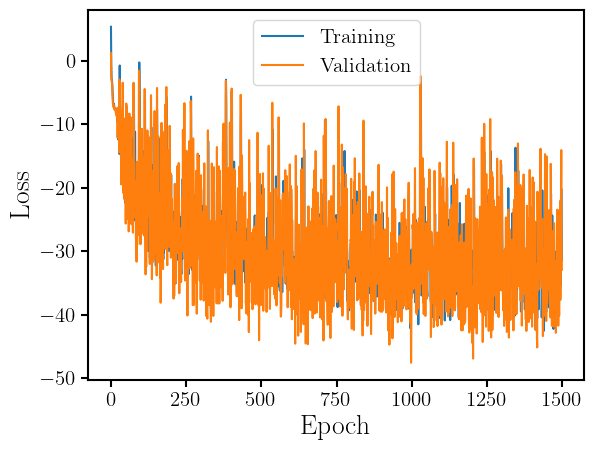

In [65]:
input_size = lenl
output_size = lenl * 3
neurons, n_out = 64, 64 * 3
n_min = 16

model = NLIM.NoLIMItNet_fraction_compress_inference(input_size, neurons, output_size, n_out, n_min, 2).to(device)
NIN.resume(model, dir+"best_model-64.pth", device)

plot_history(dir)

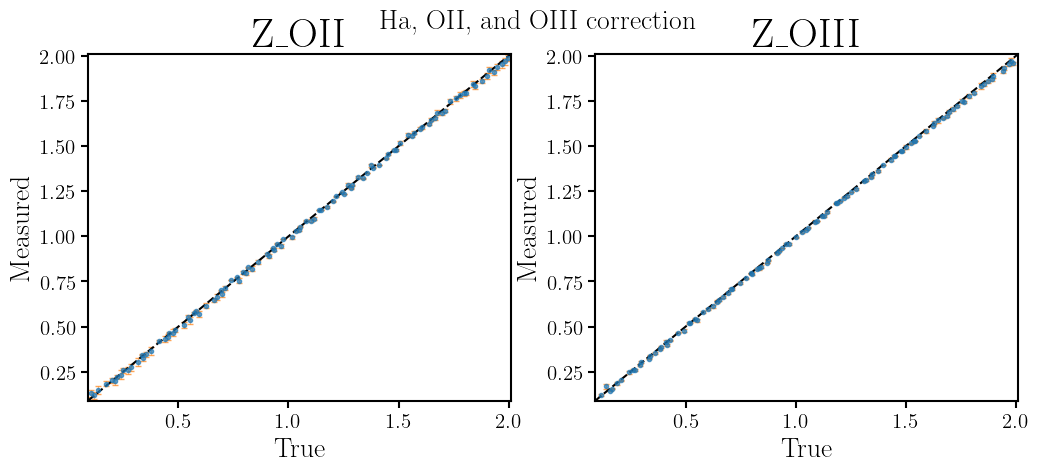

MSE error: 0.000119167154


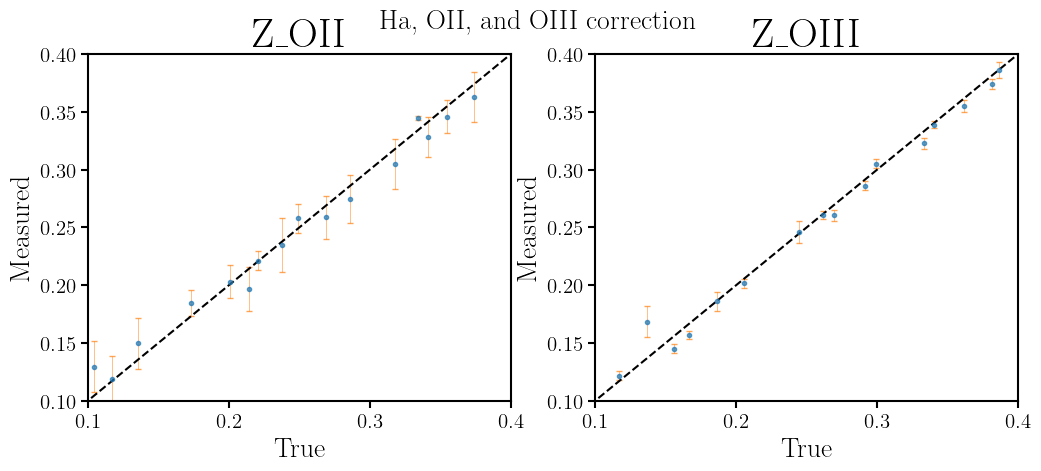

MSE error: 0.00011916705


In [66]:
plot_fraction(test, model, lenl=lenl, device=device, norm_Z=True, save=None, limits=[0.09, 2.01], title='Ha, OII, and OIII correction', Z_names=['Z_OII', 'Z_OIII'], Z_min=np.array([0.1,0.1]), Z_max=np.array([2.0,2.0]), NZ=2)
plot_fraction(test, model, lenl=lenl, device=device, norm_Z=True, save=None, limits=[0.1, 0.4], title='Ha, OII, and OIII correction', Z_names=['Z_OII', 'Z_OIII'], Z_min=np.array([0.1,0.1]), Z_max=np.array([2.0,2.0]), NZ=2)

In [13]:
MSE_chi2(test, model, lenl, device, norm_Z=True, thresh=1e-3, Z_min=np.array([0.1,0.1]), Z_max=np.array([2.0,2.0]), NZ=2, names=['OII', 'OIII'])

OII
6
MSE: 0.00014525166
Reduced chi2: 5.421336349931735
OIII
11
MSE: 9.7581054e-05
Reduced chi2: 3.564291648494387


In [ ]:
plot_fraction(test, model, lenl=lenl, device=device, norm_Z=True, save=None, limits=[0.1, 0.5], title='', Z_names=['[OII]', '[OIII]'], Z_min=np.array([0.1,0.1]), Z_max=np.array([2.0,2.0]), NZ=2)

/tmp/ipykernel_7579/3357952586.py:36: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax[0].set_xlim(0.,6000)
/tmp/ipykernel_7579/3357952586.py:59: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax[1].set_xlim(0.,6000)
/tmp/ipykernel_7579/3357952586.py:80: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax[2].set_xlim(0.,6000)


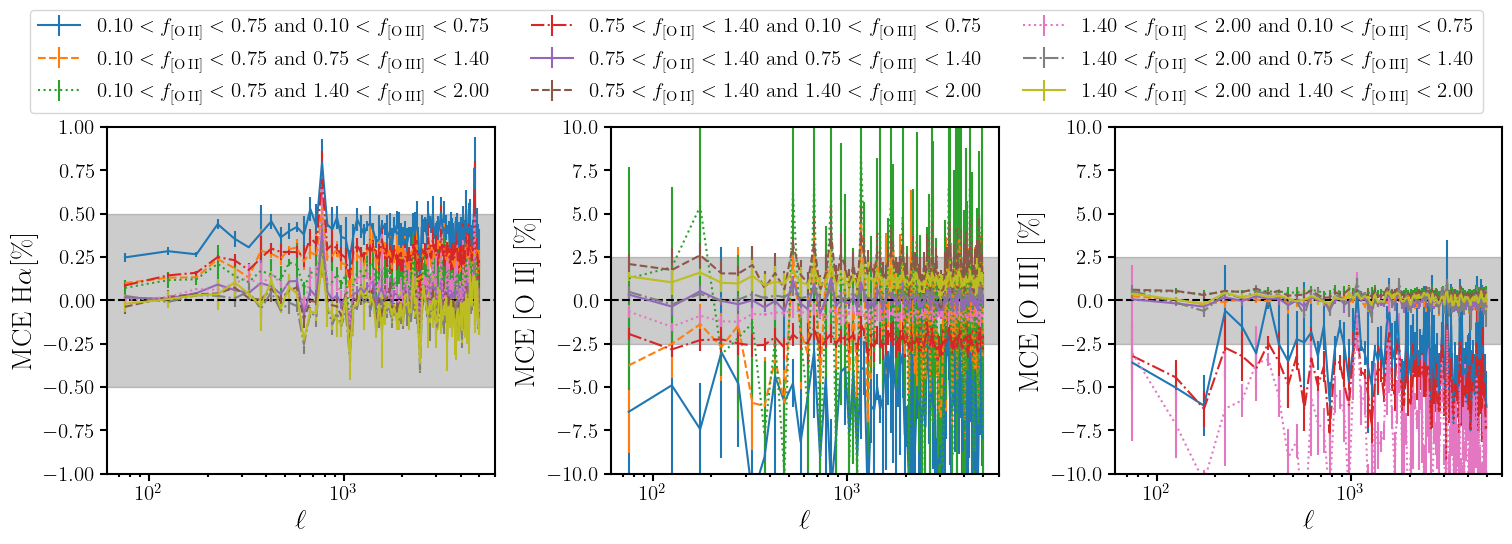

In [ ]:
Cl_int = np.load("Cl_Ha_0.npy")
ls = Cl_int[0,0,1:]

p_mean1, y_mean1, std_mean1, m1, sm1, N1 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 0.10, 0.10, 0.75, 0.75, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2)
p_mean2, y_mean2, std_mean2, m2, sm2, N2 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 0.10, 0.75, 0.75, 1.40, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2)
p_mean3, y_mean3, std_mean3, m3, sm3, N3 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 0.10, 1.40, 0.75, 2.00, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2)
p_mean4, y_mean4, std_mean4, m4, sm4, N4 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 0.75, 0.10, 1.40, 0.75, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2)
p_mean5, y_mean5, std_mean5, m5, sm5, N5 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 0.75, 0.75, 1.40, 1.40, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2)
p_mean6, y_mean6, std_mean6, m6, sm6, N6 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 0.75, 1.40, 1.40, 2.00, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2)
p_mean7, y_mean7, std_mean7, m7, sm7, N7 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 1.40, 0.10, 2.00, 0.75, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2)
p_mean8, y_mean8, std_mean8, m8, sm8, N8 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 1.40, 0.75, 2.00, 1.40, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2)
p_mean9, y_mean9, std_mean9, m9, sm9, N9 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 1.40, 1.40, 2.00, 2.00, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2)


sel = (ls> 30.) & (ls < 5000)
l_plot = ls[sel]

fig, ax = plt.subplots(1, 3, figsize=(6*3, 4.5*1))

#Ha correction
ax[0].errorbar(l_plot, (1 - p_mean1[:lenl]/y_mean1[:lenl]) * 100., yerr=std_mean1[:lenl]/np.abs(y_mean1[:lenl])/np.sqrt(N1)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='solid')
ax[0].errorbar(l_plot, (1 - p_mean2[:lenl]/y_mean2[:lenl]) * 100., yerr=std_mean2[:lenl]/np.abs(y_mean2[:lenl])/np.sqrt(N2)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='dashed')
ax[0].errorbar(l_plot, (1 - p_mean3[:lenl]/y_mean3[:lenl]) * 100., yerr=std_mean3[:lenl]/np.abs(y_mean3[:lenl])/np.sqrt(N3)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='dotted')
ax[0].errorbar(l_plot, (1 - p_mean4[:lenl]/y_mean4[:lenl]) * 100., yerr=std_mean4[:lenl]/np.abs(y_mean4[:lenl])/np.sqrt(N4)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='dashdot')
ax[0].errorbar(l_plot, (1 - p_mean5[:lenl]/y_mean5[:lenl]) * 100., yerr=std_mean5[:lenl]/np.abs(y_mean5[:lenl])/np.sqrt(N5)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='solid')
ax[0].errorbar(l_plot, (1 - p_mean6[:lenl]/y_mean6[:lenl]) * 100., yerr=std_mean6[:lenl]/np.abs(y_mean6[:lenl])/np.sqrt(N6)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='dashed')
ax[0].errorbar(l_plot, (1 - p_mean7[:lenl]/y_mean7[:lenl]) * 100., yerr=std_mean7[:lenl]/np.abs(y_mean7[:lenl])/np.sqrt(N7)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='dotted')
ax[0].errorbar(l_plot, (1 - p_mean8[:lenl]/y_mean8[:lenl]) * 100., yerr=std_mean8[:lenl]/np.abs(y_mean8[:lenl])/np.sqrt(N8)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='dashdot')
ax[0].errorbar(l_plot, (1 - p_mean9[:lenl]/y_mean9[:lenl]) * 100., yerr=std_mean9[:lenl]/np.abs(y_mean9[:lenl])/np.sqrt(N9)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='solid')


ax[0].axhline(0, color='k', linestyle='dashed')
ax[0].set_xscale('log')
ax[0].set_xlabel('$\\ell$')
ax[0].set_ylim(-1,1)
ax[0].set_xlim(0.,6000)
ax[0].set_ylabel('''MCE H$\\alpha$[$\\%$]''')

ax[0].fill_between([0., 6000], -0.5, 0.5, alpha=.2, color='k')

ax[0].legend(ncols=3, loc='lower center', bbox_to_anchor=(1.675,1.01))

#OII correction
ax[1].errorbar(l_plot, (1 - p_mean1[lenl:lenl*2]/y_mean1[lenl:lenl*2]) * 100., yerr=std_mean1[lenl:lenl*2]/np.abs(y_mean1[lenl:lenl*2])/np.sqrt(N1)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='solid')
ax[1].errorbar(l_plot, (1 - p_mean2[lenl:lenl*2]/y_mean2[lenl:lenl*2]) * 100., yerr=std_mean2[lenl:lenl*2]/np.abs(y_mean2[lenl:lenl*2])/np.sqrt(N2)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='dashed')
ax[1].errorbar(l_plot, (1 - p_mean3[lenl:lenl*2]/y_mean3[lenl:lenl*2]) * 100., yerr=std_mean3[lenl:lenl*2]/np.abs(y_mean3[lenl:lenl*2])/np.sqrt(N3)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='dotted')
ax[1].errorbar(l_plot, (1 - p_mean4[lenl:lenl*2]/y_mean4[lenl:lenl*2]) * 100., yerr=std_mean4[lenl:lenl*2]/np.abs(y_mean4[lenl:lenl*2])/np.sqrt(N4)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='dashdot')
ax[1].errorbar(l_plot, (1 - p_mean5[lenl:lenl*2]/y_mean5[lenl:lenl*2]) * 100., yerr=std_mean5[lenl:lenl*2]/np.abs(y_mean5[lenl:lenl*2])/np.sqrt(N5)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='solid')
ax[1].errorbar(l_plot, (1 - p_mean6[lenl:lenl*2]/y_mean6[lenl:lenl*2]) * 100., yerr=std_mean6[lenl:lenl*2]/np.abs(y_mean6[lenl:lenl*2])/np.sqrt(N6)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='dashed')
ax[1].errorbar(l_plot, (1 - p_mean7[lenl:lenl*2]/y_mean7[lenl:lenl*2]) * 100., yerr=std_mean7[lenl:lenl*2]/np.abs(y_mean7[lenl:lenl*2])/np.sqrt(N7)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='dotted')
ax[1].errorbar(l_plot, (1 - p_mean8[lenl:lenl*2]/y_mean8[lenl:lenl*2]) * 100., yerr=std_mean8[lenl:lenl*2]/np.abs(y_mean8[lenl:lenl*2])/np.sqrt(N8)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='dashdot')
ax[1].errorbar(l_plot, (1 - p_mean9[lenl:lenl*2]/y_mean9[lenl:lenl*2]) * 100., yerr=std_mean9[lenl:lenl*2]/np.abs(y_mean9[lenl:lenl*2])/np.sqrt(N9)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='solid')


ax[1].axhline(0, color='k', linestyle='dashed')
ax[1].set_xscale('log')
ax[1].set_xlabel('$\\ell$')
ax[1].set_ylim(-10,10)
ax[1].set_xlim(0.,6000)
ax[1].set_ylabel('''MCE [O II] [$\\%$]''')

ax[1].fill_between([0., 6000], -2.5, 2.5, alpha=.2, color='k')

#OIII correction
ax[2].errorbar(l_plot, (1 - p_mean1[lenl*2:lenl*3]/y_mean1[lenl*2:lenl*3]) * 100., yerr=std_mean1[lenl*2:lenl*3]/np.abs(y_mean1[lenl*2:lenl*3])/np.sqrt(N1)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='solid')
ax[2].errorbar(l_plot, (1 - p_mean2[lenl*2:lenl*3]/y_mean2[lenl*2:lenl*3]) * 100., yerr=std_mean2[lenl*2:lenl*3]/np.abs(y_mean2[lenl*2:lenl*3])/np.sqrt(N2)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='dashed')
ax[2].errorbar(l_plot, (1 - p_mean3[lenl*2:lenl*3]/y_mean3[lenl*2:lenl*3]) * 100., yerr=std_mean3[lenl*2:lenl*3]/np.abs(y_mean3[lenl*2:lenl*3])/np.sqrt(N3)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='dotted')
ax[2].errorbar(l_plot, (1 - p_mean4[lenl*2:lenl*3]/y_mean4[lenl*2:lenl*3]) * 100., yerr=std_mean4[lenl*2:lenl*3]/np.abs(y_mean4[lenl*2:lenl*3])/np.sqrt(N4)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='dashdot')
ax[2].errorbar(l_plot, (1 - p_mean5[lenl*2:lenl*3]/y_mean5[lenl*2:lenl*3]) * 100., yerr=std_mean5[lenl*2:lenl*3]/np.abs(y_mean5[lenl*2:lenl*3])/np.sqrt(N5)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='solid')
ax[2].errorbar(l_plot, (1 - p_mean6[lenl*2:lenl*3]/y_mean6[lenl*2:lenl*3]) * 100., yerr=std_mean6[lenl*2:lenl*3]/np.abs(y_mean6[lenl*2:lenl*3])/np.sqrt(N6)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='dashed')
ax[2].errorbar(l_plot, (1 - p_mean7[lenl*2:lenl*3]/y_mean7[lenl*2:lenl*3]) * 100., yerr=std_mean7[lenl*2:lenl*3]/np.abs(y_mean7[lenl*2:lenl*3])/np.sqrt(N7)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='dotted')
ax[2].errorbar(l_plot, (1 - p_mean8[lenl*2:lenl*3]/y_mean8[lenl*2:lenl*3]) * 100., yerr=std_mean8[lenl*2:lenl*3]/np.abs(y_mean8[lenl*2:lenl*3])/np.sqrt(N8)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='dashdot')
ax[2].errorbar(l_plot, (1 - p_mean9[lenl*2:lenl*3]/y_mean9[lenl*2:lenl*3]) * 100., yerr=std_mean9[lenl*2:lenl*3]/np.abs(y_mean9[lenl*2:lenl*3])/np.sqrt(N9)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='solid')


ax[2].axhline(0, color='k', linestyle='dashed')
ax[2].set_xscale('log')
ax[2].set_xlabel('$\\ell$')
ax[2].set_ylim(-10,10)
ax[2].set_xlim(0.,6000)
ax[2].set_ylabel('''MCE [O III] [$\\%$]''')

ax[2].fill_between([0., 6000], -2.5, 2.5, alpha=.2, color='k')

plt.subplots_adjust(wspace=0.3)

#plt.savefig('../figures/MCE-no-scatter-1ch.pdf', bbox_inches='tight')
plt.show()

In [34]:
grads = compute_input_gradients(model, test_dataloader)
print(grads.shape)

(99,)


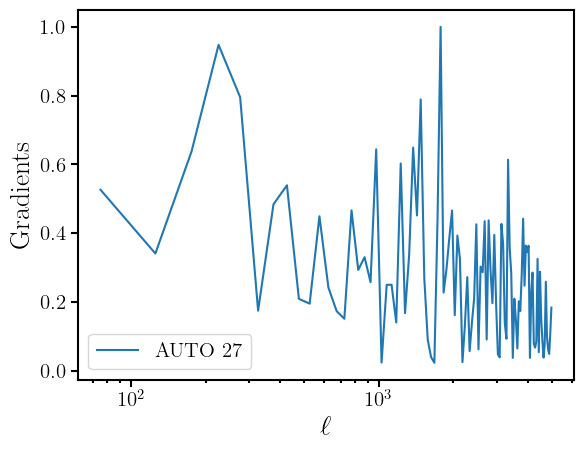

In [ ]:
Cl_int = np.load("Cl_Ha_0.npy")
ls = Cl_int[0,0,1:]


sel = (ls> 30.) & (ls < 5000)
l_plot = ls[sel]

maxgrad = np.max(grads)

#Ha correction
plt.semilogx(l_plot, grads[:lenl] / maxgrad, label='AUTO 27', linestyle='solid')

plt.xlabel('$\\ell$')
plt.ylabel('Gradients')
plt.legend(ncols=2)

plt.show()

#### Constrain 3 ch + cross

In [ ]:
dir = '../trained-models/Ha_OII_OIII-ch27-A27A38A51C38C51C49-l5e-2/NoLMItNet-Logloss-sb1024-component-corrections-moments/'

min_corr = np.load(dir+'min_correction.npy')
max_corr = np.load(dir+'max_correction.npy')

min_Cls = np.load(dir+'min_Cls.npy')
max_Cls = np.load(dir+'max_Cls.npy')

Cls, labels, lenl, max_corr, min_corr = NLIM.load_Cls_auto_and_cross("local-Cls_Ha_OII_OIII_1024-cross.csv", 27, 5000, 30, True, True, Z_names=['Z_OII', 'Z_OIII'], Z_min=np.array([0.1,0.1]), Z_max=np.array([2.0,2.0]), auto_names=['Ha_OII_OIII'], cross_names=['OII_all_cross_1', 'OIII_all_cross_1'], true_names=['Ha', 'OII', 'OIII'], contam_name='Ha_OII_OIII', input_channels=np.array([27,38,51]), add_cross=['OIII_all_cross'], add_channel=[38])

Cls = NINf.maxmin_corr(Cls, max_Cls, min_Cls)
norm = np.ones(len(Cls))

train_fraction = 0.75
val_fraction = 0.9

n_train = int(len(Cls)*train_fraction)
n_val = int(len(Cls)*val_fraction)
    
Cls_test = Cls[n_val:]

labels_test = labels[n_val:]

norm_test = np.array(norm[n_val:, np.newaxis])

test = NIN.PkDataset(Cls_test, labels_test, norm_test)

test_batch = 6
test_dataloader = DataLoader(test, batch_size=test_batch, shuffle=False)

1 64 32
2 32 16
3 16 32
4 32 64
5 64 128
6 128 256


/home/cagliari/Documents/Work/LAPTh/interloper-IM/trained-models/../src/NoInterNet_model.py:203: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.lo

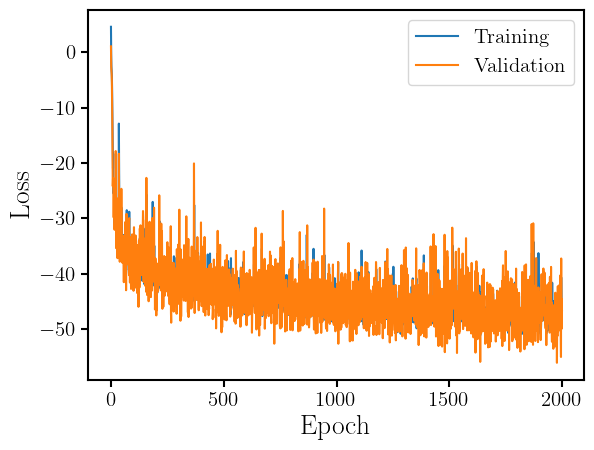

In [69]:
input_size = lenl * 6
output_size = lenl * 3
neurons, n_out = 64, 64 * 3
n_min = 16

model = NLIM.NoLIMItNet_fraction_compress_inference(input_size, neurons, output_size, n_out, n_min, 2).to(device)
NIN.resume(model, dir+"best_model-64.pth", device)

plot_history(dir)

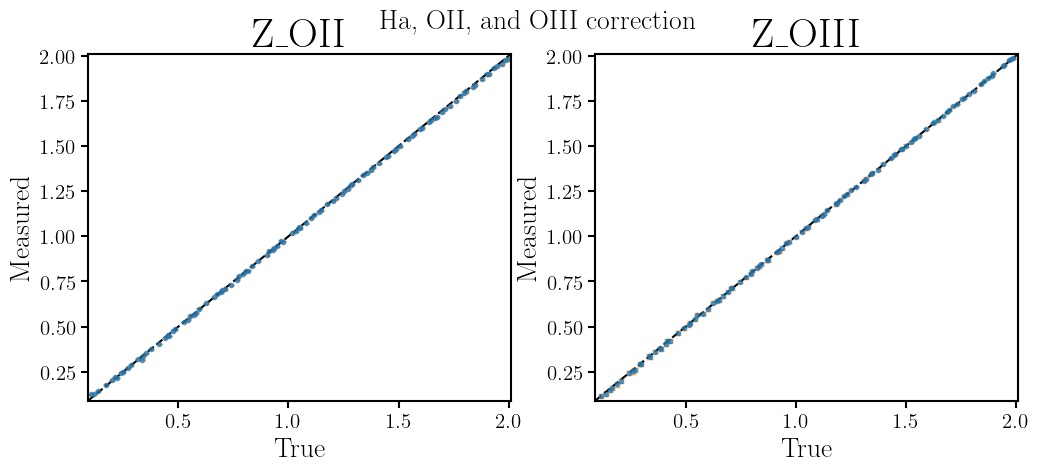

MSE error: 2.6936155e-05


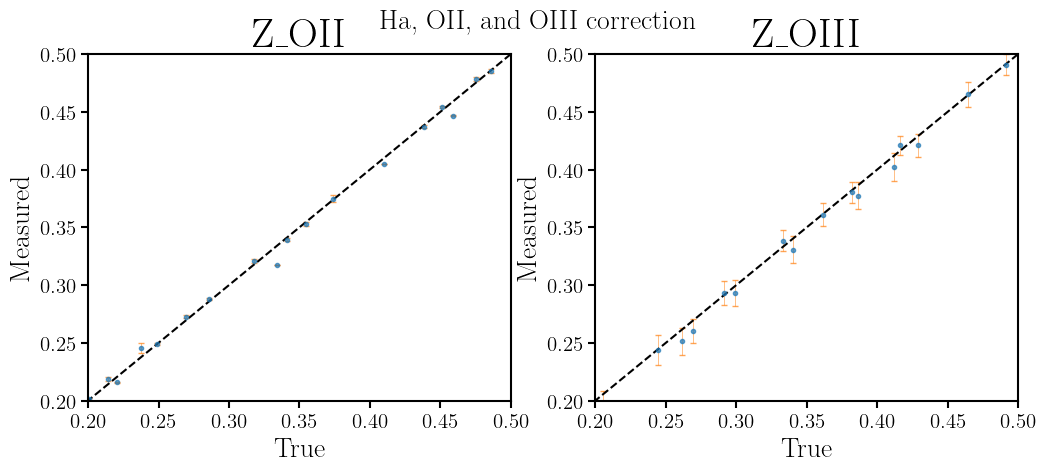

MSE error: 2.6935866e-05


In [70]:
plot_fraction(test, model, lenl=lenl, device=device, norm_Z=True, save=None, limits=[0.09, 2.01], title='Ha, OII, and OIII correction', Z_names=['Z_OII', 'Z_OIII'], Z_min=np.array([0.1,0.1]), Z_max=np.array([2.0,2.0]), NZ=2)
plot_fraction(test, model, lenl=lenl, device=device, norm_Z=True, save=None, limits=[0.2, 0.5], title='Ha, OII, and OIII correction', Z_names=['Z_OII', 'Z_OIII'], Z_min=np.array([0.1,0.1]), Z_max=np.array([2.0,2.0]), NZ=2)

In [18]:
MSE_chi2(test, model, lenl, device, norm_Z=True, thresh=1e-3, Z_min=np.array([0.1,0.1]), Z_max=np.array([2.0,2.0]), NZ=2, names=['OII', 'OIII'])

OII
12
MSE: 3.2549902e-05
Reduced chi2: 6.490096897754855
OIII
9
MSE: 1.964877e-05
Reduced chi2: 0.5740062380299985


/tmp/ipykernel_7579/4017143287.py:36: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax[0].set_xlim(0.,6000)
/tmp/ipykernel_7579/4017143287.py:59: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax[1].set_xlim(0.,6000)
/tmp/ipykernel_7579/4017143287.py:80: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax[2].set_xlim(0.,6000)


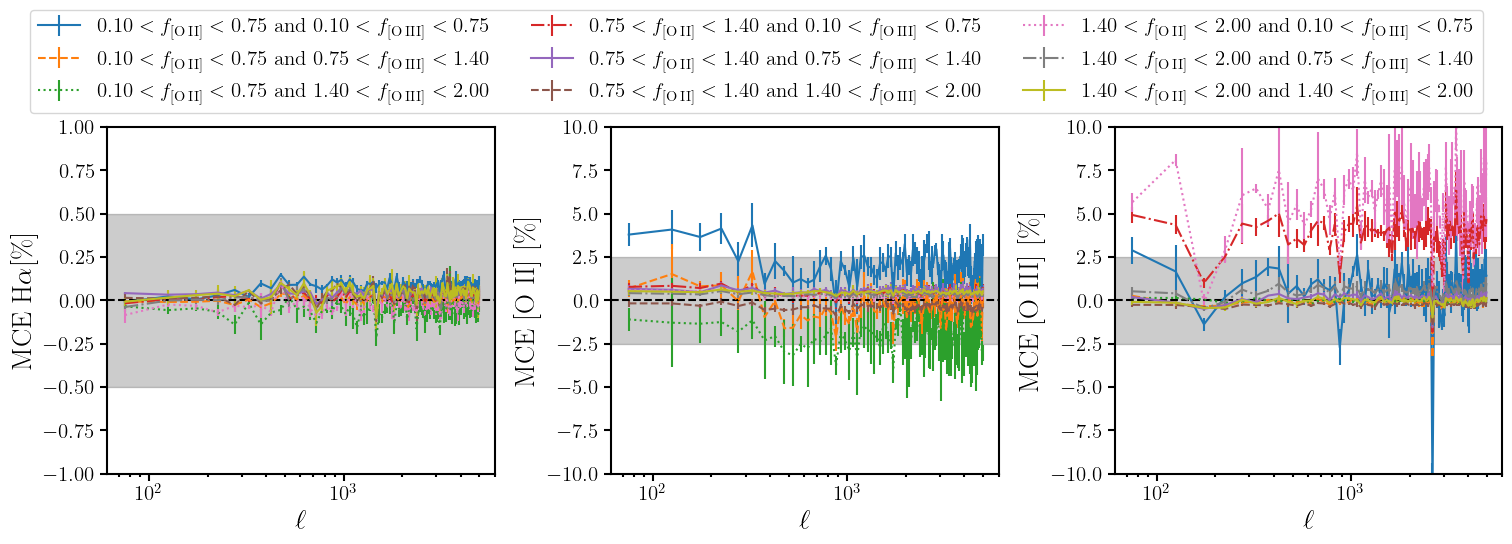

In [ ]:
Cl_int = np.load("Cl_Ha_0.npy")
ls = Cl_int[0,0,1:]

p_mean1, y_mean1, std_mean1, m1, sm1, N1 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 0.10, 0.10, 0.75, 0.75, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2)
p_mean2, y_mean2, std_mean2, m2, sm2, N2 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 0.10, 0.75, 0.75, 1.40, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2)
p_mean3, y_mean3, std_mean3, m3, sm3, N3 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 0.10, 1.40, 0.75, 2.00, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2)
p_mean4, y_mean4, std_mean4, m4, sm4, N4 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 0.75, 0.10, 1.40, 0.75, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2)
p_mean5, y_mean5, std_mean5, m5, sm5, N5 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 0.75, 0.75, 1.40, 1.40, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2)
p_mean6, y_mean6, std_mean6, m6, sm6, N6 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 0.75, 1.40, 1.40, 2.00, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2)
p_mean7, y_mean7, std_mean7, m7, sm7, N7 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 1.40, 0.10, 2.00, 0.75, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2)
p_mean8, y_mean8, std_mean8, m8, sm8, N8 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 1.40, 0.75, 2.00, 1.40, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2)
p_mean9, y_mean9, std_mean9, m9, sm9, N9 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 1.40, 1.40, 2.00, 2.00, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2)


sel = (ls> 30.) & (ls < 5000)
l_plot = ls[sel]

fig, ax = plt.subplots(1, 3, figsize=(6*3, 4.5*1))

#Ha correction
ax[0].errorbar(l_plot, (1 - p_mean1[:lenl]/y_mean1[:lenl]) * 100., yerr=std_mean1[:lenl]/np.abs(y_mean1[:lenl])/np.sqrt(N1)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='solid')
ax[0].errorbar(l_plot, (1 - p_mean2[:lenl]/y_mean2[:lenl]) * 100., yerr=std_mean2[:lenl]/np.abs(y_mean2[:lenl])/np.sqrt(N2)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='dashed')
ax[0].errorbar(l_plot, (1 - p_mean3[:lenl]/y_mean3[:lenl]) * 100., yerr=std_mean3[:lenl]/np.abs(y_mean3[:lenl])/np.sqrt(N3)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='dotted')
ax[0].errorbar(l_plot, (1 - p_mean4[:lenl]/y_mean4[:lenl]) * 100., yerr=std_mean4[:lenl]/np.abs(y_mean4[:lenl])/np.sqrt(N4)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='dashdot')
ax[0].errorbar(l_plot, (1 - p_mean5[:lenl]/y_mean5[:lenl]) * 100., yerr=std_mean5[:lenl]/np.abs(y_mean5[:lenl])/np.sqrt(N5)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='solid')
ax[0].errorbar(l_plot, (1 - p_mean6[:lenl]/y_mean6[:lenl]) * 100., yerr=std_mean6[:lenl]/np.abs(y_mean6[:lenl])/np.sqrt(N6)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='dashed')
ax[0].errorbar(l_plot, (1 - p_mean7[:lenl]/y_mean7[:lenl]) * 100., yerr=std_mean7[:lenl]/np.abs(y_mean7[:lenl])/np.sqrt(N7)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='dotted')
ax[0].errorbar(l_plot, (1 - p_mean8[:lenl]/y_mean8[:lenl]) * 100., yerr=std_mean8[:lenl]/np.abs(y_mean8[:lenl])/np.sqrt(N8)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='dashdot')
ax[0].errorbar(l_plot, (1 - p_mean9[:lenl]/y_mean9[:lenl]) * 100., yerr=std_mean9[:lenl]/np.abs(y_mean9[:lenl])/np.sqrt(N9)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='solid')


ax[0].axhline(0, color='k', linestyle='dashed')
ax[0].set_xscale('log')
ax[0].set_xlabel('$\\ell$')
ax[0].set_ylim(-1,1)
ax[0].set_xlim(0.,6000)
ax[0].set_ylabel('''MCE H$\\alpha$[$\\%$]''')

ax[0].fill_between([0., 6000], -0.5, 0.5, alpha=.2, color='k')

ax[0].legend(ncols=3, loc='lower center', bbox_to_anchor=(1.675,1.01))

#OII correction
ax[1].errorbar(l_plot, (1 - p_mean1[lenl:lenl*2]/y_mean1[lenl:lenl*2]) * 100., yerr=std_mean1[lenl:lenl*2]/np.abs(y_mean1[lenl:lenl*2])/np.sqrt(N1)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='solid')
ax[1].errorbar(l_plot, (1 - p_mean2[lenl:lenl*2]/y_mean2[lenl:lenl*2]) * 100., yerr=std_mean2[lenl:lenl*2]/np.abs(y_mean2[lenl:lenl*2])/np.sqrt(N2)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='dashed')
ax[1].errorbar(l_plot, (1 - p_mean3[lenl:lenl*2]/y_mean3[lenl:lenl*2]) * 100., yerr=std_mean3[lenl:lenl*2]/np.abs(y_mean3[lenl:lenl*2])/np.sqrt(N3)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='dotted')
ax[1].errorbar(l_plot, (1 - p_mean4[lenl:lenl*2]/y_mean4[lenl:lenl*2]) * 100., yerr=std_mean4[lenl:lenl*2]/np.abs(y_mean4[lenl:lenl*2])/np.sqrt(N4)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='dashdot')
ax[1].errorbar(l_plot, (1 - p_mean5[lenl:lenl*2]/y_mean5[lenl:lenl*2]) * 100., yerr=std_mean5[lenl:lenl*2]/np.abs(y_mean5[lenl:lenl*2])/np.sqrt(N5)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='solid')
ax[1].errorbar(l_plot, (1 - p_mean6[lenl:lenl*2]/y_mean6[lenl:lenl*2]) * 100., yerr=std_mean6[lenl:lenl*2]/np.abs(y_mean6[lenl:lenl*2])/np.sqrt(N6)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='dashed')
ax[1].errorbar(l_plot, (1 - p_mean7[lenl:lenl*2]/y_mean7[lenl:lenl*2]) * 100., yerr=std_mean7[lenl:lenl*2]/np.abs(y_mean7[lenl:lenl*2])/np.sqrt(N7)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='dotted')
ax[1].errorbar(l_plot, (1 - p_mean8[lenl:lenl*2]/y_mean8[lenl:lenl*2]) * 100., yerr=std_mean8[lenl:lenl*2]/np.abs(y_mean8[lenl:lenl*2])/np.sqrt(N8)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='dashdot')
ax[1].errorbar(l_plot, (1 - p_mean9[lenl:lenl*2]/y_mean9[lenl:lenl*2]) * 100., yerr=std_mean9[lenl:lenl*2]/np.abs(y_mean9[lenl:lenl*2])/np.sqrt(N9)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='solid')


ax[1].axhline(0, color='k', linestyle='dashed')
ax[1].set_xscale('log')
ax[1].set_xlabel('$\\ell$')
ax[1].set_ylim(-10,10)
ax[1].set_xlim(0.,6000)
ax[1].set_ylabel('''MCE [O II] [$\\%$]''')

ax[1].fill_between([0., 6000], -2.5, 2.5, alpha=.2, color='k')

#OIII correction
ax[2].errorbar(l_plot, (1 - p_mean1[lenl*2:lenl*3]/y_mean1[lenl*2:lenl*3]) * 100., yerr=std_mean1[lenl*2:lenl*3]/np.abs(y_mean1[lenl*2:lenl*3])/np.sqrt(N1)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='solid')
ax[2].errorbar(l_plot, (1 - p_mean2[lenl*2:lenl*3]/y_mean2[lenl*2:lenl*3]) * 100., yerr=std_mean2[lenl*2:lenl*3]/np.abs(y_mean2[lenl*2:lenl*3])/np.sqrt(N2)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='dashed')
ax[2].errorbar(l_plot, (1 - p_mean3[lenl*2:lenl*3]/y_mean3[lenl*2:lenl*3]) * 100., yerr=std_mean3[lenl*2:lenl*3]/np.abs(y_mean3[lenl*2:lenl*3])/np.sqrt(N3)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='dotted')
ax[2].errorbar(l_plot, (1 - p_mean4[lenl*2:lenl*3]/y_mean4[lenl*2:lenl*3]) * 100., yerr=std_mean4[lenl*2:lenl*3]/np.abs(y_mean4[lenl*2:lenl*3])/np.sqrt(N4)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='dashdot')
ax[2].errorbar(l_plot, (1 - p_mean5[lenl*2:lenl*3]/y_mean5[lenl*2:lenl*3]) * 100., yerr=std_mean5[lenl*2:lenl*3]/np.abs(y_mean5[lenl*2:lenl*3])/np.sqrt(N5)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='solid')
ax[2].errorbar(l_plot, (1 - p_mean6[lenl*2:lenl*3]/y_mean6[lenl*2:lenl*3]) * 100., yerr=std_mean6[lenl*2:lenl*3]/np.abs(y_mean6[lenl*2:lenl*3])/np.sqrt(N6)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='dashed')
ax[2].errorbar(l_plot, (1 - p_mean7[lenl*2:lenl*3]/y_mean7[lenl*2:lenl*3]) * 100., yerr=std_mean7[lenl*2:lenl*3]/np.abs(y_mean7[lenl*2:lenl*3])/np.sqrt(N7)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='dotted')
ax[2].errorbar(l_plot, (1 - p_mean8[lenl*2:lenl*3]/y_mean8[lenl*2:lenl*3]) * 100., yerr=std_mean8[lenl*2:lenl*3]/np.abs(y_mean8[lenl*2:lenl*3])/np.sqrt(N8)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='dashdot')
ax[2].errorbar(l_plot, (1 - p_mean9[lenl*2:lenl*3]/y_mean9[lenl*2:lenl*3]) * 100., yerr=std_mean9[lenl*2:lenl*3]/np.abs(y_mean9[lenl*2:lenl*3])/np.sqrt(N9)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='solid')


ax[2].axhline(0, color='k', linestyle='dashed')
ax[2].set_xscale('log')
ax[2].set_xlabel('$\\ell$')
ax[2].set_ylim(-10,10)
ax[2].set_xlim(0.,6000)
ax[2].set_ylabel('''MCE [O III] [$\\%$]''')

ax[2].fill_between([0., 6000], -2.5, 2.5, alpha=.2, color='k')

plt.subplots_adjust(wspace=0.3)

#plt.savefig('../figures/MCE-no-scatter-AC.pdf', bbox_inches='tight')
plt.show()

In [41]:
grads = compute_input_gradients(model, test_dataloader)
print(grads.shape)

(594,)


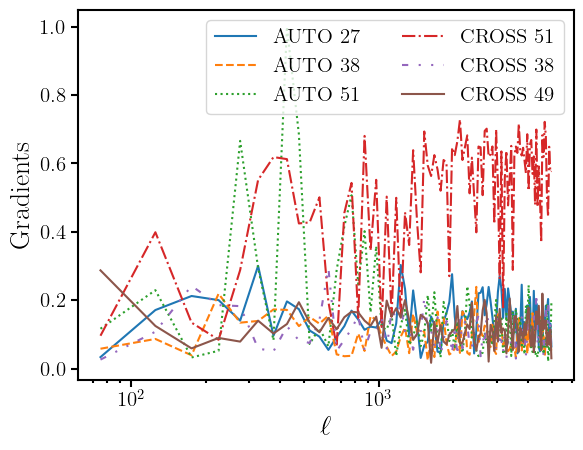

In [ ]:
Cl_int = np.load("Cl_Ha_0.npy")
ls = Cl_int[0,0,1:]


sel = (ls> 30.) & (ls < 5000)
l_plot = ls[sel]

maxgrad = np.max(grads)

#Ha correction
plt.semilogx(l_plot, grads[:lenl] / maxgrad, label='AUTO 27', linestyle='solid')
plt.semilogx(l_plot, grads[lenl:lenl*2] / maxgrad, label='AUTO 38', linestyle='dashed')
plt.semilogx(l_plot, grads[lenl*2:lenl*3] / maxgrad, label='AUTO 51', linestyle='dotted')
plt.semilogx(l_plot, grads[lenl*3:lenl*4] / maxgrad, label='CROSS 51', linestyle='dashdot')
plt.semilogx(l_plot, grads[lenl*4:lenl*5] / maxgrad, label='CROSS 38', linestyle= (0, (3, 5, 1, 5, 1, 5)))
plt.semilogx(l_plot, grads[lenl*5:lenl*6] / maxgrad, label='CROSS 49', linestyle= 'solid')

plt.xlabel('$\\ell$')
plt.ylabel('Gradients')
plt.legend(ncols=2)

plt.show()

### Scattered

#### Constrained, Target: H $\alpha$, interlopers: OII, OIII, channel 27, AUTO27+AUTO38+AUTO51+CROSS38+CROSS51+CROSS49 $\lambda=0.05$

In [ ]:
dir = '../trained-models/Ha_OII_OIII_scattered-ch27-A27A38A51C38C51C49-l5e-2/NoLMItNet-Logloss-sb1024-component-corrections-moments/'

min_corr = np.load(dir+'min_correction.npy')
max_corr = np.load(dir+'max_correction.npy')

min_Cls = np.load(dir+'min_Cls.npy')
max_Cls = np.load(dir+'max_Cls.npy')

Cls, labels, lenl, max_corr, min_corr = NLIM.load_Cls_auto_and_cross("local-Cls_Ha_OII_OIII_1024-scattered-lambda.csv", 27, 5000, 30, True, True, Z_names=['Z_OII', 'Z_OIII'], Z_min=np.array([0.1,0.1]), Z_max=np.array([2.0,2.0]), auto_names=['Ha_OII_OIII'], cross_names=['OII_all_cross_1', 'OIII_all_cross_1'], true_names=['Ha', 'OII', 'OIII'], contam_name='Ha_OII_OIII', input_channels=np.array([27,38,51]), add_cross=['OIII_all_cross'], add_channel=[38])

Cls = NINf.maxmin_corr(Cls, max_Cls, min_Cls)
norm = np.ones(len(Cls))

train_fraction = 0.75
val_fraction = 0.9

n_train = int(len(Cls)*train_fraction)
n_val = int(len(Cls)*val_fraction)
    
Cls_test = Cls[n_val:]

labels_test = labels[n_val:]

norm_test = np.array(norm[n_val:, np.newaxis])

test = NIN.PkDataset(Cls_test, labels_test, norm_test)

test_batch = 6
test_dataloader = DataLoader(test, batch_size=test_batch, shuffle=False)

1 64 32
2 32 16
3 16 32
4 32 64
5 64 128
6 128 256


/home/cagliari/Documents/Work/LAPTh/interloper-IM/trained-models/../src/NoInterNet_model.py:203: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.lo

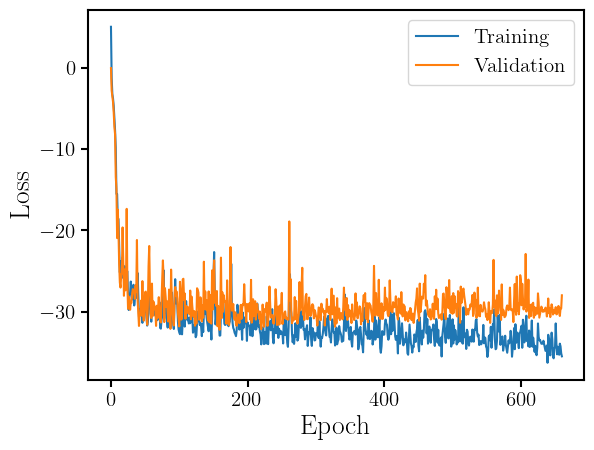

In [73]:
input_size = lenl * 6
output_size = lenl * 3
neurons, n_out = 64, 64 * 3
n_min = 16

model = NLIM.NoLIMItNet_fraction_compress_inference(input_size, neurons, output_size, n_out, n_min, 2).to(device)
NIN.resume(model, dir+"best_model-64.pth", device)

plot_history(dir)

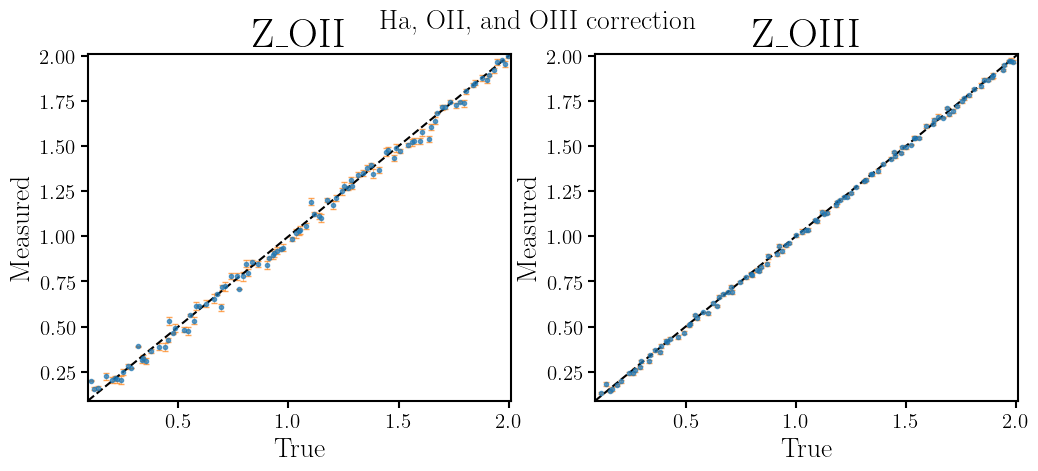

MSE error: 0.0007260424


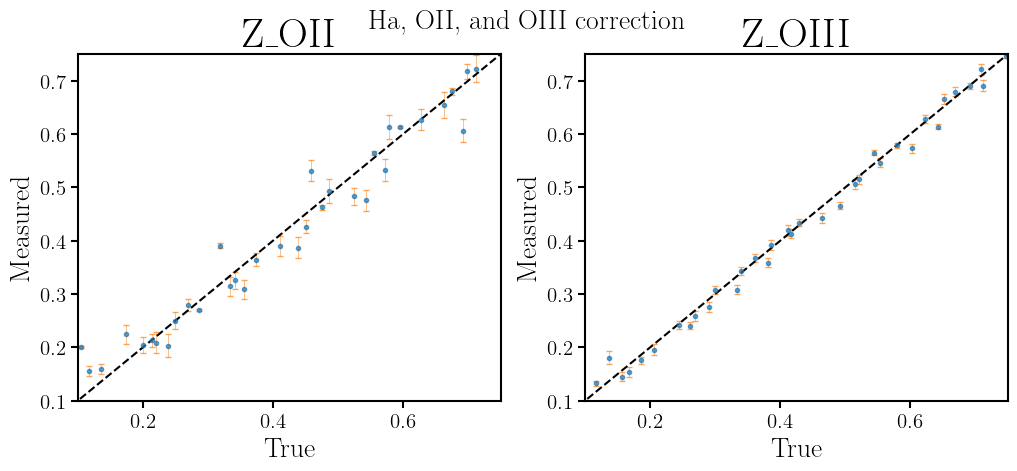

MSE error: 0.0007260418


In [74]:
plot_fraction(test, model, lenl=lenl, device=device, norm_Z=True, save=None, limits=[0.09, 2.01], title='Ha, OII, and OIII correction', Z_names=['Z_OII', 'Z_OIII'], Z_min=np.array([0.1,0.1]), Z_max=np.array([2.0,2.0]), NZ=2)
plot_fraction(test, model, lenl=lenl, device=device, norm_Z=True, save=None, limits=[0.1, 0.75], title='Ha, OII, and OIII correction', Z_names=['Z_OII', 'Z_OIII'], Z_min=np.array([0.1,0.1]), Z_max=np.array([2.0,2.0]), NZ=2)

In [23]:
MSE_chi2(test, model, lenl, device, norm_Z=True, thresh=1e-3, Z_min=np.array([0.1,0.1]), Z_max=np.array([2.0,2.0]), NZ=2, names=['OII', 'OIII'])

OII
1
MSE: 0.0012290644
Reduced chi2: 29.52657814396238
OIII
0
MSE: 0.00019202846
Reduced chi2: 3.2445557233199334


In [ ]:
plot_fraction(test, model, lenl=lenl, device=device, norm_Z=True, save=None, limits=[0.1, 02.0], title='', Z_names=['Multi-channel [OIII]'], Z_min=np.array([0.1]), Z_max=np.array([2.0]), NZ=1)

/tmp/ipykernel_7579/1073553756.py:36: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax[0].set_xlim(0.,6000)
/tmp/ipykernel_7579/1073553756.py:59: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax[1].set_xlim(0.,6000)
/tmp/ipykernel_7579/1073553756.py:80: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax[2].set_xlim(0.,6000)


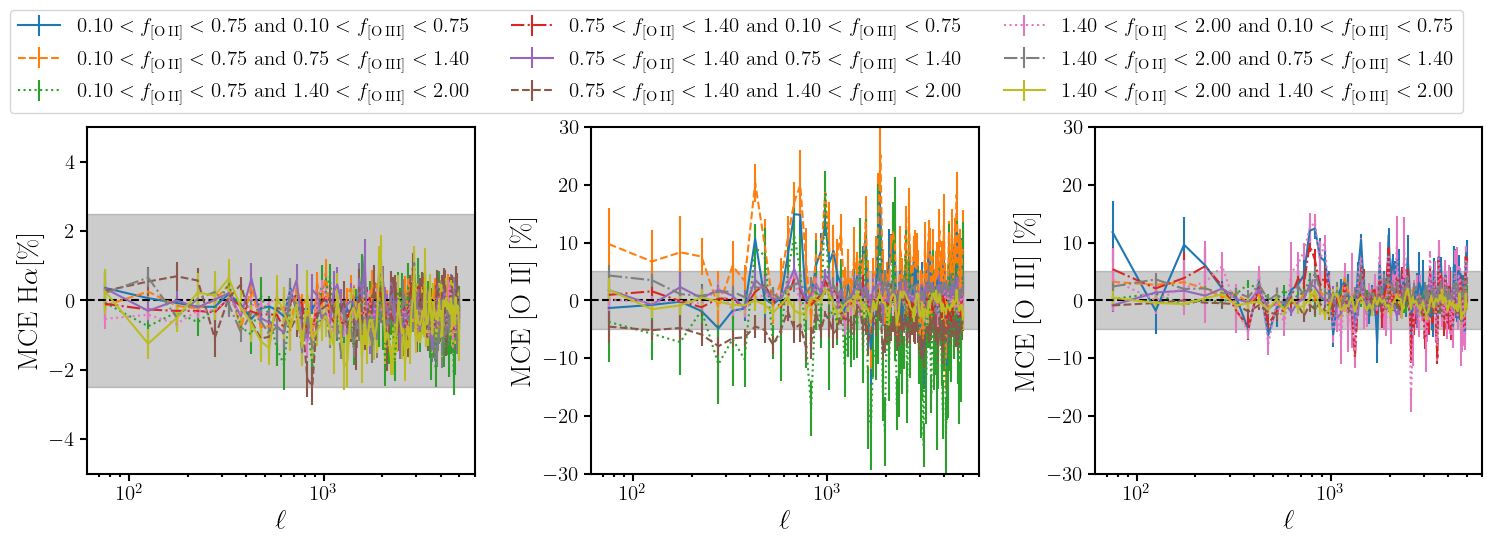

In [ ]:
Cl_int = np.load("/home/cagliari/Documents/Work/LAPTh/Cls/Ha/Cl_Ha_0.npy")
ls = Cl_int[0,0,1:]

p_mean1, y_mean1, std_mean1, m1, sm1, N1 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 0.10, 0.10, 0.75, 0.75, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2)
p_mean2, y_mean2, std_mean2, m2, sm2, N2 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 0.10, 0.75, 0.75, 1.40, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2)
p_mean3, y_mean3, std_mean3, m3, sm3, N3 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 0.10, 1.40, 0.75, 2.00, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2)
p_mean4, y_mean4, std_mean4, m4, sm4, N4 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 0.75, 0.10, 1.40, 0.75, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2)
p_mean5, y_mean5, std_mean5, m5, sm5, N5 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 0.75, 0.75, 1.40, 1.40, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2)
p_mean6, y_mean6, std_mean6, m6, sm6, N6 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 0.75, 1.40, 1.40, 2.00, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2)
p_mean7, y_mean7, std_mean7, m7, sm7, N7 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 1.40, 0.10, 2.00, 0.75, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2)
p_mean8, y_mean8, std_mean8, m8, sm8, N8 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 1.40, 0.75, 2.00, 1.40, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2)
p_mean9, y_mean9, std_mean9, m9, sm9, N9 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 1.40, 1.40, 2.00, 2.00, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2)


sel = (ls> 30.) & (ls < 5000)
l_plot = ls[sel]

fig, ax = plt.subplots(1, 3, figsize=(6*3, 4.5*1))

#Ha correction
ax[0].errorbar(l_plot, (1 - p_mean1[:lenl]/y_mean1[:lenl]) * 100., yerr=std_mean1[:lenl]/np.abs(y_mean1[:lenl])/np.sqrt(N1)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='solid')
ax[0].errorbar(l_plot, (1 - p_mean2[:lenl]/y_mean2[:lenl]) * 100., yerr=std_mean2[:lenl]/np.abs(y_mean2[:lenl])/np.sqrt(N2)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='dashed')
ax[0].errorbar(l_plot, (1 - p_mean3[:lenl]/y_mean3[:lenl]) * 100., yerr=std_mean3[:lenl]/np.abs(y_mean3[:lenl])/np.sqrt(N3)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='dotted')
ax[0].errorbar(l_plot, (1 - p_mean4[:lenl]/y_mean4[:lenl]) * 100., yerr=std_mean4[:lenl]/np.abs(y_mean4[:lenl])/np.sqrt(N4)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='dashdot')
ax[0].errorbar(l_plot, (1 - p_mean5[:lenl]/y_mean5[:lenl]) * 100., yerr=std_mean5[:lenl]/np.abs(y_mean5[:lenl])/np.sqrt(N5)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='solid')
ax[0].errorbar(l_plot, (1 - p_mean6[:lenl]/y_mean6[:lenl]) * 100., yerr=std_mean6[:lenl]/np.abs(y_mean6[:lenl])/np.sqrt(N6)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='dashed')
ax[0].errorbar(l_plot, (1 - p_mean7[:lenl]/y_mean7[:lenl]) * 100., yerr=std_mean7[:lenl]/np.abs(y_mean7[:lenl])/np.sqrt(N7)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='dotted')
ax[0].errorbar(l_plot, (1 - p_mean8[:lenl]/y_mean8[:lenl]) * 100., yerr=std_mean8[:lenl]/np.abs(y_mean8[:lenl])/np.sqrt(N8)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='dashdot')
ax[0].errorbar(l_plot, (1 - p_mean9[:lenl]/y_mean9[:lenl]) * 100., yerr=std_mean9[:lenl]/np.abs(y_mean9[:lenl])/np.sqrt(N9)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='solid')


ax[0].axhline(0, color='k', linestyle='dashed')
ax[0].set_xscale('log')
ax[0].set_xlabel('$\\ell$')
ax[0].set_ylim(-5,5)
ax[0].set_xlim(0.,6000)
ax[0].set_ylabel('''MCE H$\\alpha$[$\\%$]''')

ax[0].fill_between([0., 6000], -2.5, 2.5, alpha=.2, color='k')

ax[0].legend(ncols=3, loc='lower center', bbox_to_anchor=(1.675,1.01))

#OII correction
ax[1].errorbar(l_plot, (1 - p_mean1[lenl:lenl*2]/y_mean1[lenl:lenl*2]) * 100., yerr=std_mean1[lenl:lenl*2]/np.abs(y_mean1[lenl:lenl*2])/np.sqrt(N1)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='solid')
ax[1].errorbar(l_plot, (1 - p_mean2[lenl:lenl*2]/y_mean2[lenl:lenl*2]) * 100., yerr=std_mean2[lenl:lenl*2]/np.abs(y_mean2[lenl:lenl*2])/np.sqrt(N2)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='dashed')
ax[1].errorbar(l_plot, (1 - p_mean3[lenl:lenl*2]/y_mean3[lenl:lenl*2]) * 100., yerr=std_mean3[lenl:lenl*2]/np.abs(y_mean3[lenl:lenl*2])/np.sqrt(N3)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='dotted')
ax[1].errorbar(l_plot, (1 - p_mean4[lenl:lenl*2]/y_mean4[lenl:lenl*2]) * 100., yerr=std_mean4[lenl:lenl*2]/np.abs(y_mean4[lenl:lenl*2])/np.sqrt(N4)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='dashdot')
ax[1].errorbar(l_plot, (1 - p_mean5[lenl:lenl*2]/y_mean5[lenl:lenl*2]) * 100., yerr=std_mean5[lenl:lenl*2]/np.abs(y_mean5[lenl:lenl*2])/np.sqrt(N5)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='solid')
ax[1].errorbar(l_plot, (1 - p_mean6[lenl:lenl*2]/y_mean6[lenl:lenl*2]) * 100., yerr=std_mean6[lenl:lenl*2]/np.abs(y_mean6[lenl:lenl*2])/np.sqrt(N6)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='dashed')
ax[1].errorbar(l_plot, (1 - p_mean7[lenl:lenl*2]/y_mean7[lenl:lenl*2]) * 100., yerr=std_mean7[lenl:lenl*2]/np.abs(y_mean7[lenl:lenl*2])/np.sqrt(N7)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='dotted')
ax[1].errorbar(l_plot, (1 - p_mean8[lenl:lenl*2]/y_mean8[lenl:lenl*2]) * 100., yerr=std_mean8[lenl:lenl*2]/np.abs(y_mean8[lenl:lenl*2])/np.sqrt(N8)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='dashdot')
ax[1].errorbar(l_plot, (1 - p_mean9[lenl:lenl*2]/y_mean9[lenl:lenl*2]) * 100., yerr=std_mean9[lenl:lenl*2]/np.abs(y_mean9[lenl:lenl*2])/np.sqrt(N9)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='solid')


ax[1].axhline(0, color='k', linestyle='dashed')
ax[1].set_xscale('log')
ax[1].set_xlabel('$\\ell$')
ax[1].set_ylim(-30,30)
ax[1].set_xlim(0.,6000)
ax[1].set_ylabel('''MCE [O II] [$\\%$]''')

ax[1].fill_between([0., 6000], -5, 5, alpha=.2, color='k')

#OIII correction
ax[2].errorbar(l_plot, (1 - p_mean1[lenl*2:lenl*3]/y_mean1[lenl*2:lenl*3]) * 100., yerr=std_mean1[lenl*2:lenl*3]/np.abs(y_mean1[lenl*2:lenl*3])/np.sqrt(N1)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='solid')
ax[2].errorbar(l_plot, (1 - p_mean2[lenl*2:lenl*3]/y_mean2[lenl*2:lenl*3]) * 100., yerr=std_mean2[lenl*2:lenl*3]/np.abs(y_mean2[lenl*2:lenl*3])/np.sqrt(N2)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='dashed')
ax[2].errorbar(l_plot, (1 - p_mean3[lenl*2:lenl*3]/y_mean3[lenl*2:lenl*3]) * 100., yerr=std_mean3[lenl*2:lenl*3]/np.abs(y_mean3[lenl*2:lenl*3])/np.sqrt(N3)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='dotted')
ax[2].errorbar(l_plot, (1 - p_mean4[lenl*2:lenl*3]/y_mean4[lenl*2:lenl*3]) * 100., yerr=std_mean4[lenl*2:lenl*3]/np.abs(y_mean4[lenl*2:lenl*3])/np.sqrt(N4)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='dashdot')
ax[2].errorbar(l_plot, (1 - p_mean5[lenl*2:lenl*3]/y_mean5[lenl*2:lenl*3]) * 100., yerr=std_mean5[lenl*2:lenl*3]/np.abs(y_mean5[lenl*2:lenl*3])/np.sqrt(N5)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='solid')
ax[2].errorbar(l_plot, (1 - p_mean6[lenl*2:lenl*3]/y_mean6[lenl*2:lenl*3]) * 100., yerr=std_mean6[lenl*2:lenl*3]/np.abs(y_mean6[lenl*2:lenl*3])/np.sqrt(N6)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='dashed')
ax[2].errorbar(l_plot, (1 - p_mean7[lenl*2:lenl*3]/y_mean7[lenl*2:lenl*3]) * 100., yerr=std_mean7[lenl*2:lenl*3]/np.abs(y_mean7[lenl*2:lenl*3])/np.sqrt(N7)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='dotted')
ax[2].errorbar(l_plot, (1 - p_mean8[lenl*2:lenl*3]/y_mean8[lenl*2:lenl*3]) * 100., yerr=std_mean8[lenl*2:lenl*3]/np.abs(y_mean8[lenl*2:lenl*3])/np.sqrt(N8)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='dashdot')
ax[2].errorbar(l_plot, (1 - p_mean9[lenl*2:lenl*3]/y_mean9[lenl*2:lenl*3]) * 100., yerr=std_mean9[lenl*2:lenl*3]/np.abs(y_mean9[lenl*2:lenl*3])/np.sqrt(N9)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='solid')


ax[2].axhline(0, color='k', linestyle='dashed')
ax[2].set_xscale('log')
ax[2].set_xlabel('$\\ell$')
ax[2].set_ylim(-30,30)
ax[2].set_xlim(0.,6000)
ax[2].set_ylabel('''MCE [O III] [$\\%$]''')

ax[2].fill_between([0., 6000], -5, 5, alpha=.2, color='k')

plt.subplots_adjust(wspace=0.3)

#plt.savefig('../figures/MCE-scatter-AC.pdf', bbox_inches='tight')
plt.show()

In [48]:
grads = compute_input_gradients(model, test_dataloader)
print(grads.shape)

(594,)


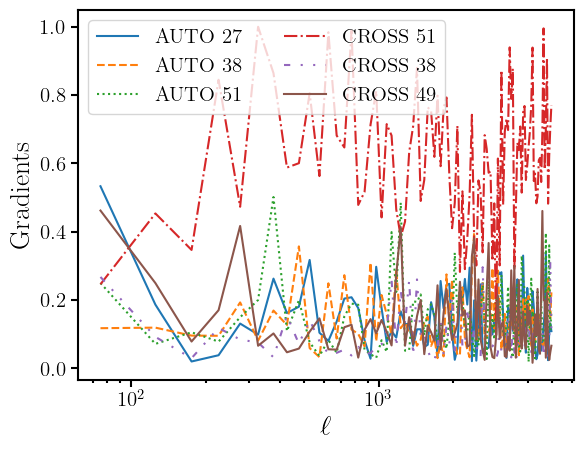

In [ ]:
Cl_int = np.load("Cl_Ha_0.npy")
ls = Cl_int[0,0,1:]


sel = (ls> 30.) & (ls < 5000)
l_plot = ls[sel]

maxgrad = np.max(grads)

#Ha correction
plt.semilogx(l_plot, grads[:lenl] / maxgrad, label='AUTO 27', linestyle='solid')
plt.semilogx(l_plot, grads[lenl:lenl*2] / maxgrad, label='AUTO 38', linestyle='dashed')
plt.semilogx(l_plot, grads[lenl*2:lenl*3] / maxgrad, label='AUTO 51', linestyle='dotted')
plt.semilogx(l_plot, grads[lenl*3:lenl*4] / maxgrad, label='CROSS 51', linestyle='dashdot')
plt.semilogx(l_plot, grads[lenl*4:lenl*5] / maxgrad, label='CROSS 38', linestyle= (0, (3, 5, 1, 5, 1, 5)))
plt.semilogx(l_plot, grads[lenl*5:lenl*6] / maxgrad, label='CROSS 49', linestyle= 'solid')

plt.xlabel('$\\ell$')
plt.ylabel('Gradients')
plt.legend(ncols=2)

plt.show()

#### Constrained, Target: H $\alpha$, interlopers: OII, OIII, channel 27, AUTO27

In [ ]:
dir = '../trained-models/Ha_OII_OIII_scattered-ch27-A27-l5e-2/NoLMItNet-Logloss-sb1024-component-corrections-moments/'

min_corr = np.load(dir+'min_correction.npy')
max_corr = np.load(dir+'max_correction.npy')

min_Cls = np.load(dir+'min_Cls.npy')
max_Cls = np.load(dir+'max_Cls.npy')

Cls, labels, lenl, max_corr, min_corr = NLIM.load_Cls_multiples("local-Cls_Ha_OII_OIII_1024-scattered-2.csv", 27, 5000, 30, True, True, Z_names=['Z_OII', 'Z_OIII'], Z_min=np.array([0.1,0.1]), Z_max=np.array([2.0,2.0]), int_names=['Ha_OII_OIII'], true_names=['Ha', 'OII', 'OIII'], contam_name='Ha_OII_OIII', input_channels=np.array([27]))

Cls = NINf.maxmin_corr(Cls, max_Cls, min_Cls)
norm = np.ones(len(Cls))

train_fraction = 0.75
val_fraction = 0.9

n_train = int(len(Cls)*train_fraction)
n_val = int(len(Cls)*val_fraction)
    
Cls_test = Cls[n_val:]

labels_test = labels[n_val:]

norm_test = np.array(norm[n_val:, np.newaxis])

test = NIN.PkDataset(Cls_test, labels_test, norm_test)

test_batch = 6
test_dataloader = DataLoader(test, batch_size=test_batch, shuffle=False)

1 64 32
2 32 16
3 16 32
4 32 64
5 64 128
6 128 256


/home/cagliari/Documents/Work/LAPTh/interloper-IM/trained-models/../src/NoInterNet_model.py:203: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.lo

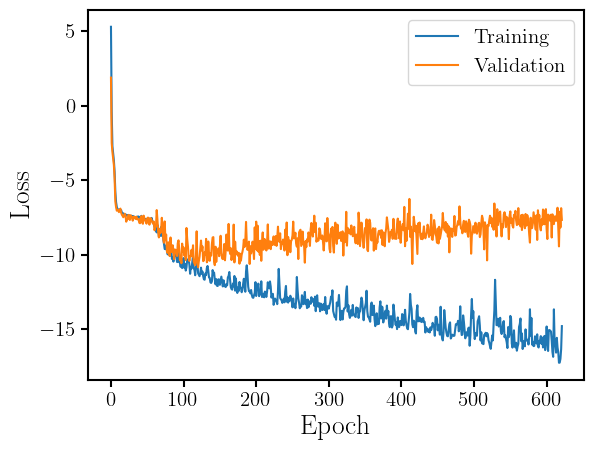

In [71]:
input_size = lenl * 1
output_size = lenl * 3
neurons, n_out = 64, 64 * 3
n_min = 16

model = NLIM.NoLIMItNet_fraction_compress_inference(input_size, neurons, output_size, n_out, n_min, 2).to(device)
NIN.resume(model, dir+"best_model-64.pth", device)

plot_history(dir)

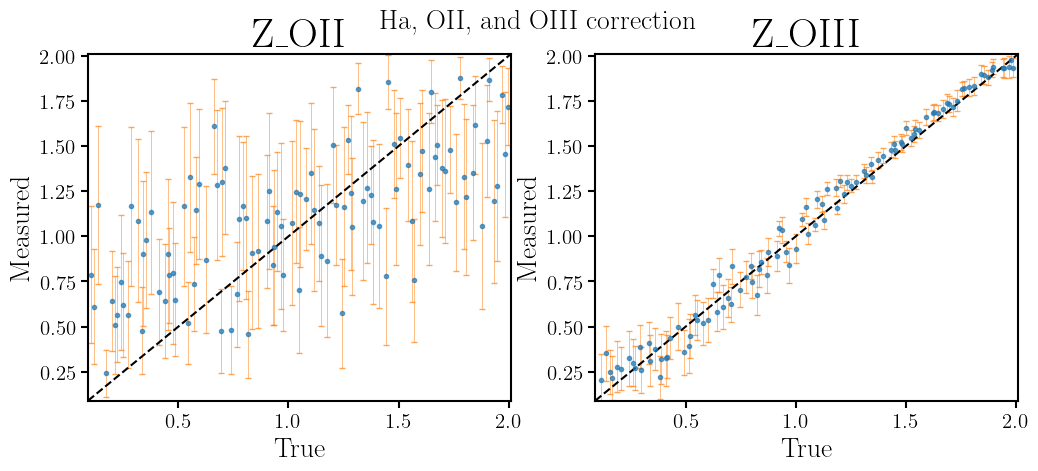

MSE error: 0.089426644


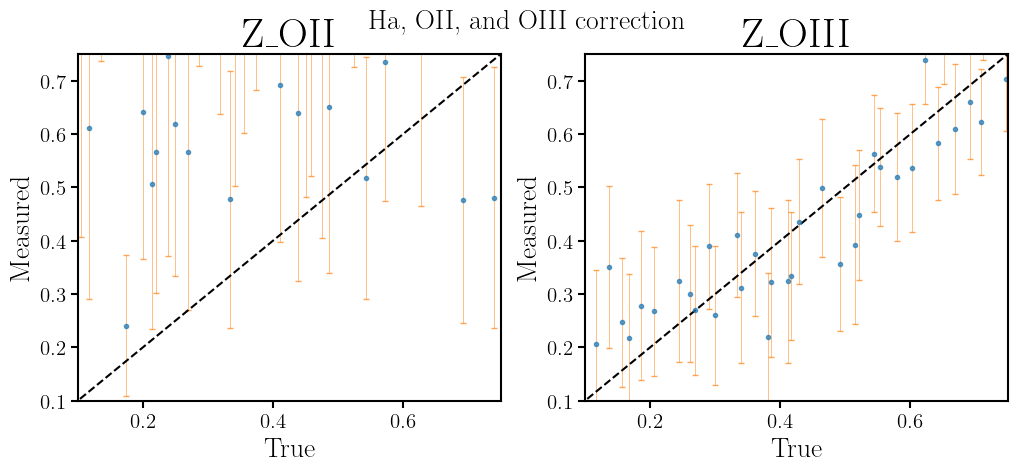

MSE error: 0.08942665


In [72]:
plot_fraction(test, model, lenl=lenl, device=device, norm_Z=True, save=None, limits=[0.09, 2.01], title='Ha, OII, and OIII correction', Z_names=['Z_OII', 'Z_OIII'], Z_min=np.array([0.1,0.1]), Z_max=np.array([2.0,2.0]), NZ=2)
plot_fraction(test, model, lenl=lenl, device=device, norm_Z=True, save=None, limits=[0.1, 0.75], title='Ha, OII, and OIII correction', Z_names=['Z_OII', 'Z_OIII'], Z_min=np.array([0.1,0.1]), Z_max=np.array([2.0,2.0]), NZ=2)

In [73]:
MSE_chi2(test, model, lenl, device, norm_Z=True, thresh=1e-3, Z_min=np.array([0.1,0.1]), Z_max=np.array([2.0,2.0]), NZ=2, names=['OII', 'OIII'])

OII
0
MSE: 0.17400901
Reduced chi2: 1.5105439713857707
OIII
0
MSE: 0.0048442916
Reduced chi2: 1.1830377671325092


In [ ]:
plot_fraction(test, model, lenl=lenl, device=device, norm_Z=True, save=None, limits=[0.1, 2.0], title='', Z_names=['Single-channel [OIII]'], Z_min=np.array([0.1]), Z_max=np.array([2.0]), NZ=1)

## Continuum

### Scatter

#### Constrained, Target: H $\alpha$, interlopers: OII, OIII, channel 27, AUTO27+AUTO38+AUTO51+CROSS38+CROSS51+CROSS49 $\lambda=0.05$

In [ ]:
dir = '../trained-models/Ha_OII_OIII_Cont_scattered-ch27-A27A38A51C38C51C49-l5e-2/NoLMItNet-Logloss-sb1024-component-corrections-moments/'

min_corr = np.load(dir+'min_correction.npy')
max_corr = np.load(dir+'max_correction.npy')

min_Cls = np.load(dir+'min_Cls.npy')
max_Cls = np.load(dir+'max_Cls.npy')

Cls, labels, lenl, max_corr, min_corr = NLIM.load_Cls_auto_and_cross("local-Cls_Ha_OII_OIII_Cont_1024-scattered-02.csv", 27, 5000, 30, True, True, Z_names=['Z_OII', 'Z_OIII'], Z_min=np.array([0.1,0.1]), Z_max=np.array([2.0,2.0]), auto_names=['Ha_OII_OIII_Cont'], cross_names=['OII_all_cross_1', 'OIII_all_cross_1'], true_names=['Ha', 'OII', 'OIII', 'Cont'], contam_name='Ha_OII_OIII_Cont', input_channels=np.array([27,38,51]), add_cross=['OIII_all_cross'], add_channel=[38])

Cls = NINf.maxmin_corr(Cls, max_Cls, min_Cls)
norm = np.ones(len(Cls))

train_fraction = 0.75
val_fraction = 0.9

n_train = int(len(Cls)*train_fraction)
n_val = int(len(Cls)*val_fraction)
    
Cls_test = Cls[n_val:]

labels_test = labels[n_val:]

norm_test = np.array(norm[n_val:, np.newaxis])

test = NIN.PkDataset(Cls_test, labels_test, norm_test)

test_batch = 6
test_dataloader = DataLoader(test, batch_size=test_batch, shuffle=False)

1 64 32
2 32 16
3 16 32
4 32 64
5 64 128
6 128 256


/home/cagliari/Documents/Work/LAPTh/interloper-IM/trained-models/../src/NoInterNet_model.py:203: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.lo

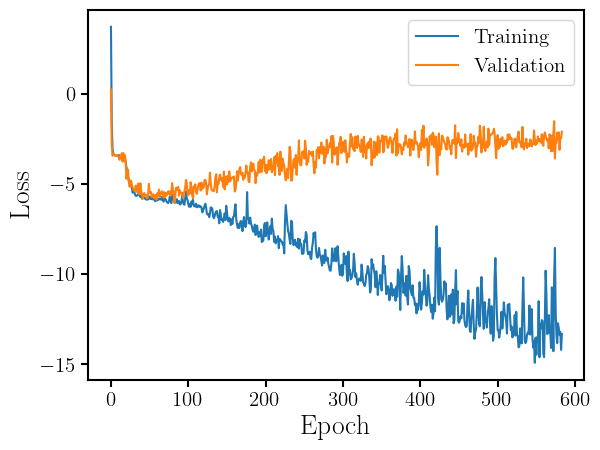

In [60]:
input_size = lenl * 6
output_size = lenl * 4
neurons, n_out = 64, 64 * 4
n_min = 16

model = NLIM.NoLIMItNet_fraction_compress_inference(input_size, neurons, output_size, n_out, n_min, 2).to(device)
NIN.resume(model, dir+"best_model-64.pth", device)

plot_history(dir)

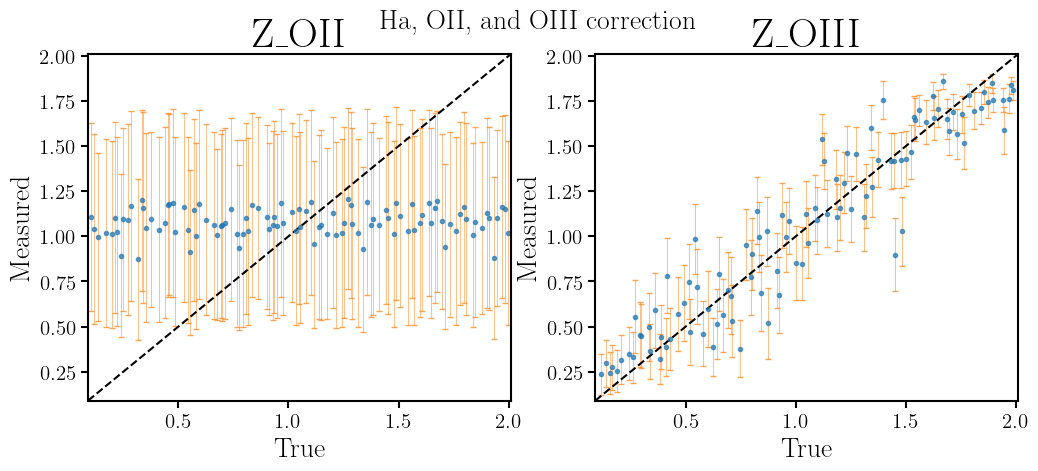

MSE error: 0.16699179


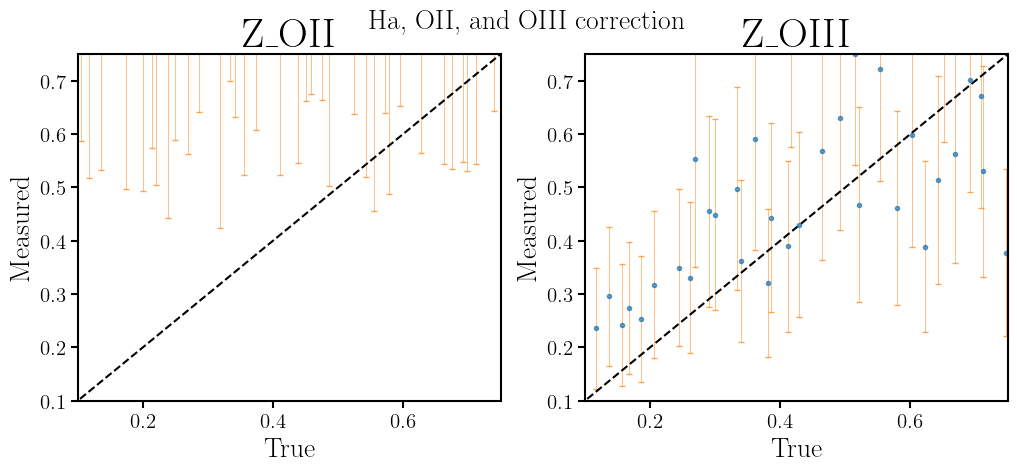

MSE error: 0.1669918


In [61]:
plot_fraction(test, model, lenl=lenl, device=device, norm_Z=True, save=None, limits=[0.09, 2.01], title='Ha, OII, and OIII correction', Z_names=['Z_OII', 'Z_OIII'], Z_min=np.array([0.1,0.1]), Z_max=np.array([2.0,2.0]), NZ=2, cont=True)
plot_fraction(test, model, lenl=lenl, device=device, norm_Z=True, save=None, limits=[0.1, 0.75], title='Ha, OII, and OIII correction', Z_names=['Z_OII', 'Z_OIII'], Z_min=np.array([0.1,0.1]), Z_max=np.array([2.0,2.0]), NZ=2, cont=True)

In [62]:
MSE_chi2(test, model, lenl, device, norm_Z=True, thresh=1e-3, Z_min=np.array([0.1,0.1]), Z_max=np.array([2.0,2.0]), NZ=2, names=['OII', 'OIII'], comp=4)

OII
0
MSE: 0.30196646
Reduced chi2: 1.1751780093294903
OIII
0
MSE: 0.032017082
Reduced chi2: 1.8009197642502275


In [ ]:
plot_fraction(test, model, lenl=lenl, device=device, norm_Z=True, save=None, limits=[0.09, 2.01], title='', Z_names=['[OII]', '[OIII]'], Z_min=np.array([0.1,0.1]), Z_max=np.array([2.0,2.0]), NZ=2, cont=True)


/tmp/ipykernel_7579/1982132481.py:34: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax[0,0].set_xlim(0.,6000)
/tmp/ipykernel_7579/1982132481.py:57: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax[0,1].set_xlim(0.,6000)
/tmp/ipykernel_7579/1982132481.py:78: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax[1,0].set_xlim(0.,6000)
/tmp/ipykernel_7579/1982132481.py:99: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax[1,1].set_xlim(0.,6000)


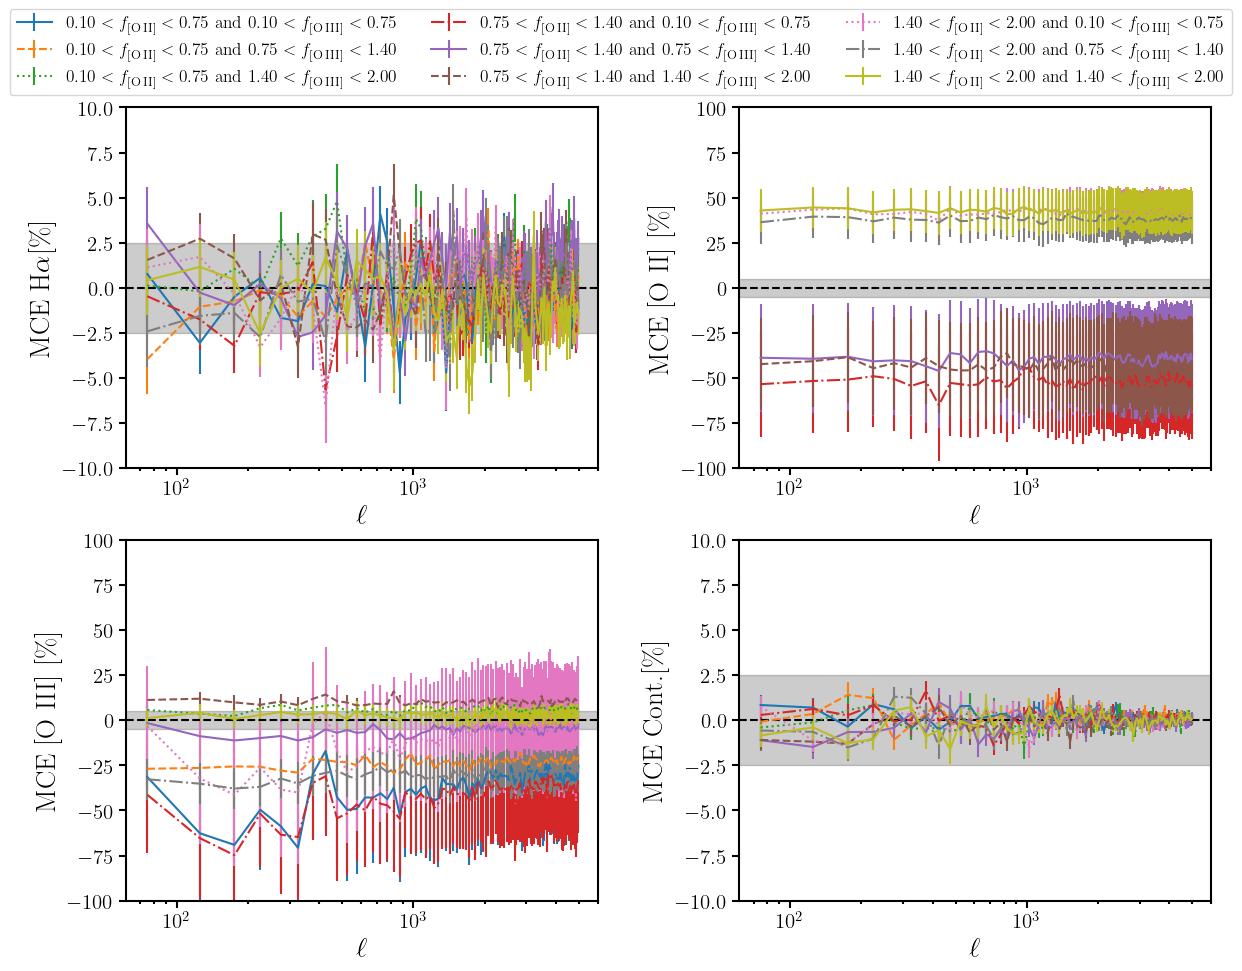

In [ ]:
Cl_int = np.load("Cl_Ha_0.npy")
ls = Cl_int[0,0,1:]

p_mean1, y_mean1, std_mean1, m1, sm1, N1 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 0.10, 0.10, 0.75, 0.75, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2, cont=True)
p_mean2, y_mean2, std_mean2, m2, sm2, N2 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 0.10, 0.75, 0.75, 1.40, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2, cont=True)
p_mean3, y_mean3, std_mean3, m3, sm3, N3 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 0.10, 1.40, 0.75, 2.00, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2, cont=True)
p_mean4, y_mean4, std_mean4, m4, sm4, N4 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 0.75, 0.10, 1.40, 0.75, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2, cont=True)
p_mean5, y_mean5, std_mean5, m5, sm5, N5 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 0.75, 0.75, 1.40, 1.40, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2, cont=True)
p_mean6, y_mean6, std_mean6, m6, sm6, N6 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 0.75, 1.40, 1.40, 2.00, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2, cont=True)
p_mean7, y_mean7, std_mean7, m7, sm7, N7 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 1.40, 0.10, 2.00, 0.75, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2, cont=True)
p_mean8, y_mean8, std_mean8, m8, sm8, N8 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 1.40, 0.75, 2.00, 1.40, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2, cont=True)
p_mean9, y_mean9, std_mean9, m9, sm9, N9 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 1.40, 1.40, 2.00, 2.00, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2, cont=True)

sel = (ls> 30.) & (ls < 5000)
l_plot = ls[sel]

fig, ax = plt.subplots(2, 2, figsize=(6*2+2, 4.5*2+1.3))

#Ha correction
ax[0,0].errorbar(l_plot, (1 - p_mean1[:lenl]/y_mean1[:lenl]) * 100., yerr=std_mean1[:lenl]/np.abs(y_mean1[:lenl])/np.sqrt(N1)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='solid')
ax[0,0].errorbar(l_plot, (1 - p_mean2[:lenl]/y_mean2[:lenl]) * 100., yerr=std_mean2[:lenl]/np.abs(y_mean2[:lenl])/np.sqrt(N2)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='dashed')
ax[0,0].errorbar(l_plot, (1 - p_mean3[:lenl]/y_mean3[:lenl]) * 100., yerr=std_mean3[:lenl]/np.abs(y_mean3[:lenl])/np.sqrt(N3)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='dotted')
ax[0,0].errorbar(l_plot, (1 - p_mean4[:lenl]/y_mean4[:lenl]) * 100., yerr=std_mean4[:lenl]/np.abs(y_mean4[:lenl])/np.sqrt(N4)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='dashdot')
ax[0,0].errorbar(l_plot, (1 - p_mean5[:lenl]/y_mean5[:lenl]) * 100., yerr=std_mean5[:lenl]/np.abs(y_mean5[:lenl])/np.sqrt(N5)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='solid')
ax[0,0].errorbar(l_plot, (1 - p_mean6[:lenl]/y_mean6[:lenl]) * 100., yerr=std_mean6[:lenl]/np.abs(y_mean6[:lenl])/np.sqrt(N6)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='dashed')
ax[0,0].errorbar(l_plot, (1 - p_mean7[:lenl]/y_mean7[:lenl]) * 100., yerr=std_mean7[:lenl]/np.abs(y_mean7[:lenl])/np.sqrt(N7)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='dotted')
ax[0,0].errorbar(l_plot, (1 - p_mean8[:lenl]/y_mean8[:lenl]) * 100., yerr=std_mean8[:lenl]/np.abs(y_mean8[:lenl])/np.sqrt(N8)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='dashdot')
ax[0,0].errorbar(l_plot, (1 - p_mean9[:lenl]/y_mean9[:lenl]) * 100., yerr=std_mean9[:lenl]/np.abs(y_mean9[:lenl])/np.sqrt(N9)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='solid')

ax[0,0].axhline(0, color='k', linestyle='dashed')
ax[0,0].set_xscale('log')
ax[0,0].set_xlabel('$\\ell$')
ax[0,0].set_ylim(-10,10)
ax[0,0].set_xlim(0.,6000)
ax[0,0].set_ylabel('''MCE H$\\alpha$[$\\%$]''')

ax[0,0].fill_between([0., 6000], -2.5, 2.5, alpha=.2, color='k')

ax[0,0].legend(ncols=3, loc='lower center', bbox_to_anchor=(1.05,1.01), fontsize=12.5)

#OII correction
ax[0,1].errorbar(l_plot, (1 - p_mean1[lenl:lenl*2]/y_mean1[lenl:lenl*2]) * 100., yerr=std_mean1[lenl:lenl*2]/np.abs(y_mean1[lenl:lenl*2])/np.sqrt(N1)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='solid')
ax[0,1].errorbar(l_plot, (1 - p_mean2[lenl:lenl*2]/y_mean2[lenl:lenl*2]) * 100., yerr=std_mean2[lenl:lenl*2]/np.abs(y_mean2[lenl:lenl*2])/np.sqrt(N2)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='dashed')
ax[0,1].errorbar(l_plot, (1 - p_mean3[lenl:lenl*2]/y_mean3[lenl:lenl*2]) * 100., yerr=std_mean3[lenl:lenl*2]/np.abs(y_mean3[lenl:lenl*2])/np.sqrt(N3)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='dotted')
ax[0,1].errorbar(l_plot, (1 - p_mean4[lenl:lenl*2]/y_mean4[lenl:lenl*2]) * 100., yerr=std_mean4[lenl:lenl*2]/np.abs(y_mean4[lenl:lenl*2])/np.sqrt(N4)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='dashdot')
ax[0,1].errorbar(l_plot, (1 - p_mean5[lenl:lenl*2]/y_mean5[lenl:lenl*2]) * 100., yerr=std_mean5[lenl:lenl*2]/np.abs(y_mean5[lenl:lenl*2])/np.sqrt(N5)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='solid')
ax[0,1].errorbar(l_plot, (1 - p_mean6[lenl:lenl*2]/y_mean6[lenl:lenl*2]) * 100., yerr=std_mean6[lenl:lenl*2]/np.abs(y_mean6[lenl:lenl*2])/np.sqrt(N6)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='dashed')
ax[0,1].errorbar(l_plot, (1 - p_mean7[lenl:lenl*2]/y_mean7[lenl:lenl*2]) * 100., yerr=std_mean7[lenl:lenl*2]/np.abs(y_mean7[lenl:lenl*2])/np.sqrt(N7)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='dotted')
ax[0,1].errorbar(l_plot, (1 - p_mean8[lenl:lenl*2]/y_mean8[lenl:lenl*2]) * 100., yerr=std_mean8[lenl:lenl*2]/np.abs(y_mean8[lenl:lenl*2])/np.sqrt(N8)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='dashdot')
ax[0,1].errorbar(l_plot, (1 - p_mean9[lenl:lenl*2]/y_mean9[lenl:lenl*2]) * 100., yerr=std_mean9[lenl:lenl*2]/np.abs(y_mean9[lenl:lenl*2])/np.sqrt(N9)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='solid')


ax[0,1].axhline(0, color='k', linestyle='dashed')
ax[0,1].set_xscale('log')
ax[0,1].set_xlabel('$\\ell$')
ax[0,1].set_ylim(-100,100)
ax[0,1].set_xlim(0.,6000)
ax[0,1].set_ylabel('''MCE [O II] [$\\%$]''')

ax[0,1].fill_between([0., 6000], -5, 5, alpha=.2, color='k')

#OIII correction
ax[1,0].errorbar(l_plot, (1 - p_mean1[lenl*2:lenl*3]/y_mean1[lenl*2:lenl*3]) * 100., yerr=std_mean1[lenl*2:lenl*3]/np.abs(y_mean1[lenl*2:lenl*3])/np.sqrt(N1)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $0.10 < f_{\\rm [O\,III]} < 0.75$' , linestyle='solid')
ax[1,0].errorbar(l_plot, (1 - p_mean2[lenl*2:lenl*3]/y_mean2[lenl*2:lenl*3]) * 100., yerr=std_mean2[lenl*2:lenl*3]/np.abs(y_mean2[lenl*2:lenl*3])/np.sqrt(N2)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='dashed')
ax[1,0].errorbar(l_plot, (1 - p_mean3[lenl*2:lenl*3]/y_mean3[lenl*2:lenl*3]) * 100., yerr=std_mean3[lenl*2:lenl*3]/np.abs(y_mean3[lenl*2:lenl*3])/np.sqrt(N3)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='dotted')
ax[1,0].errorbar(l_plot, (1 - p_mean4[lenl*2:lenl*3]/y_mean4[lenl*2:lenl*3]) * 100., yerr=std_mean4[lenl*2:lenl*3]/np.abs(y_mean4[lenl*2:lenl*3])/np.sqrt(N4)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='dashdot')
ax[1,0].errorbar(l_plot, (1 - p_mean5[lenl*2:lenl*3]/y_mean5[lenl*2:lenl*3]) * 100., yerr=std_mean5[lenl*2:lenl*3]/np.abs(y_mean5[lenl*2:lenl*3])/np.sqrt(N5)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='solid')
ax[1,0].errorbar(l_plot, (1 - p_mean6[lenl*2:lenl*3]/y_mean6[lenl*2:lenl*3]) * 100., yerr=std_mean6[lenl*2:lenl*3]/np.abs(y_mean6[lenl*2:lenl*3])/np.sqrt(N6)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='dashed')
ax[1,0].errorbar(l_plot, (1 - p_mean7[lenl*2:lenl*3]/y_mean7[lenl*2:lenl*3]) * 100., yerr=std_mean7[lenl*2:lenl*3]/np.abs(y_mean7[lenl*2:lenl*3])/np.sqrt(N7)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='dotted')
ax[1,0].errorbar(l_plot, (1 - p_mean8[lenl*2:lenl*3]/y_mean8[lenl*2:lenl*3]) * 100., yerr=std_mean8[lenl*2:lenl*3]/np.abs(y_mean8[lenl*2:lenl*3])/np.sqrt(N8)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='dashdot')
ax[1,0].errorbar(l_plot, (1 - p_mean9[lenl*2:lenl*3]/y_mean9[lenl*2:lenl*3]) * 100., yerr=std_mean9[lenl*2:lenl*3]/np.abs(y_mean9[lenl*2:lenl*3])/np.sqrt(N9)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='solid')


ax[1,0].axhline(0, color='k', linestyle='dashed')
ax[1,0].set_xscale('log')
ax[1,0].set_xlabel('$\\ell$')
ax[1,0].set_ylim(-100,100)
ax[1,0].set_xlim(0.,6000)
ax[1,0].set_ylabel('''MCE [O III] [$\\%$]''')

ax[1,0].fill_between([0., 6000], -5, 5, alpha=.2, color='k')

#Continuum correction
ax[1,1].errorbar(l_plot, (1 - p_mean1[lenl*3:lenl*4]/y_mean1[lenl*3:lenl*4]) * 100., yerr=std_mean1[lenl*3:lenl*4]/np.abs(y_mean1[lenl*3:lenl*4])/np.sqrt(N1)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='solid')
ax[1,1].errorbar(l_plot, (1 - p_mean2[lenl*3:lenl*4]/y_mean2[lenl*3:lenl*4]) * 100., yerr=std_mean2[lenl*3:lenl*4]/np.abs(y_mean2[lenl*3:lenl*4])/np.sqrt(N2)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='dashed')
ax[1,1].errorbar(l_plot, (1 - p_mean3[lenl*3:lenl*4]/y_mean3[lenl*3:lenl*4]) * 100., yerr=std_mean3[lenl*3:lenl*4]/np.abs(y_mean3[lenl*3:lenl*4])/np.sqrt(N3)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='dotted')
ax[1,1].errorbar(l_plot, (1 - p_mean4[lenl*3:lenl*4]/y_mean4[lenl*3:lenl*4]) * 100., yerr=std_mean4[lenl*3:lenl*4]/np.abs(y_mean4[lenl*3:lenl*4])/np.sqrt(N4)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='dashdot')
ax[1,1].errorbar(l_plot, (1 - p_mean5[lenl*3:lenl*4]/y_mean5[lenl*3:lenl*4]) * 100., yerr=std_mean5[lenl*3:lenl*4]/np.abs(y_mean5[lenl*3:lenl*4])/np.sqrt(N5)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='solid')
ax[1,1].errorbar(l_plot, (1 - p_mean6[lenl*3:lenl*4]/y_mean6[lenl*3:lenl*4]) * 100., yerr=std_mean6[lenl*3:lenl*4]/np.abs(y_mean6[lenl*3:lenl*4])/np.sqrt(N6)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='dashed')
ax[1,1].errorbar(l_plot, (1 - p_mean7[lenl*3:lenl*4]/y_mean7[lenl*3:lenl*4]) * 100., yerr=std_mean7[lenl*3:lenl*4]/np.abs(y_mean7[lenl*3:lenl*4])/np.sqrt(N7)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='dotted')
ax[1,1].errorbar(l_plot, (1 - p_mean8[lenl*3:lenl*4]/y_mean8[lenl*3:lenl*4]) * 100., yerr=std_mean8[lenl*3:lenl*4]/np.abs(y_mean8[lenl*3:lenl*4])/np.sqrt(N8)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='dashdot')
ax[1,1].errorbar(l_plot, (1 - p_mean9[lenl*3:lenl*4]/y_mean9[lenl*3:lenl*4]) * 100., yerr=std_mean9[lenl*3:lenl*4]/np.abs(y_mean9[lenl*3:lenl*4])/np.sqrt(N9)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='solid')


ax[1,1].axhline(0, color='k', linestyle='dashed')
ax[1,1].set_xscale('log')
ax[1,1].set_xlabel('$\\ell$')
ax[1,1].set_ylim(-10,10)
ax[1,1].set_xlim(0.,6000)
ax[1,1].set_ylabel('''MCE Cont.[$\\%$]''')

ax[1,1].fill_between([0., 6000], -2.5, 2.5, alpha=.2, color='k')

plt.subplots_adjust(wspace=0.3)

#plt.savefig('../figures/MCE-scatter02-Cont-multich.pdf', bbox_inches='tight')
plt.show()

In [80]:
grads = compute_input_gradients(model, test_dataloader)
print(grads.shape)

(594,)


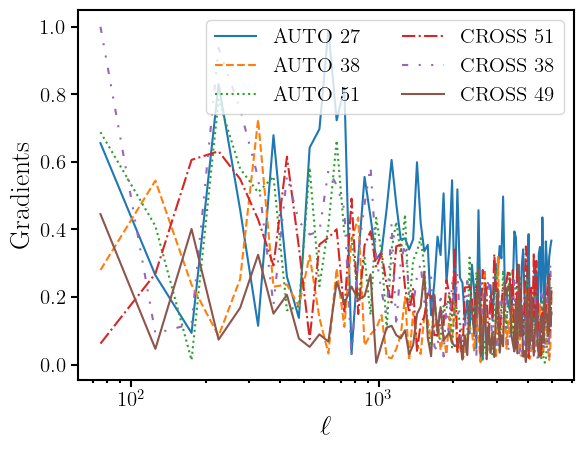

In [ ]:
Cl_int = np.load("Cl_Ha_0.npy")
ls = Cl_int[0,0,1:]


sel = (ls> 30.) & (ls < 5000)
l_plot = ls[sel]

maxgrad = np.max(grads)

#Ha correction
plt.semilogx(l_plot, grads[:lenl] / maxgrad, label='AUTO 27', linestyle='solid')
plt.semilogx(l_plot, grads[lenl:lenl*2] / maxgrad, label='AUTO 38', linestyle='dashed')
plt.semilogx(l_plot, grads[lenl*2:lenl*3] / maxgrad, label='AUTO 51', linestyle='dotted')
plt.semilogx(l_plot, grads[lenl*3:lenl*4] / maxgrad, label='CROSS 51', linestyle='dashdot')
plt.semilogx(l_plot, grads[lenl*4:lenl*5] / maxgrad, label='CROSS 38', linestyle= (0, (3, 5, 1, 5, 1, 5)))
plt.semilogx(l_plot, grads[lenl*5:lenl*6] / maxgrad, label='CROSS 49', linestyle= 'solid')

plt.xlabel('$\\ell$')
plt.ylabel('Gradients')
plt.legend(ncols=2)

plt.show()

#### Constrained, Target: H $\alpha$, interlopers: OII, OIII, channel 27, AUTO27+AUTO38+AUTO51+CROSS38+CROSS51+CROSS49 $\lambda=0.05$ scatter 01

In [ ]:
dir = '../trained-models/Ha_OII_OIII_Cont_scattered01-ch27-A27A38A51C38C51C49-l5e-2/NoLMItNet-Logloss-sb1024-component-corrections-moments/'

min_corr = np.load(dir+'min_correction.npy')
max_corr = np.load(dir+'max_correction.npy')

min_Cls = np.load(dir+'min_Cls.npy')
max_Cls = np.load(dir+'max_Cls.npy')

Cls, labels, lenl, max_corr, min_corr = NLIM.load_Cls_auto_and_cross("local-Cls_Ha_OII_OIII_Cont_1024-scattered-01.csv", 27, 5000, 30, True, True, Z_names=['Z_OII', 'Z_OIII'], Z_min=np.array([0.1,0.1]), Z_max=np.array([2.0,2.0]), auto_names=['Ha_OII_OIII_Cont'], cross_names=['OII_all_cross_1', 'OIII_all_cross_1'], true_names=['Ha', 'OII', 'OIII', 'Cont'], contam_name='Ha_OII_OIII_Cont', input_channels=np.array([27,38,51]), add_cross=['OIII_all_cross'], add_channel=[38])

Cls = NINf.maxmin_corr(Cls, max_Cls, min_Cls)
norm = np.ones(len(Cls))

train_fraction = 0.75
val_fraction = 0.9

n_train = int(len(Cls)*train_fraction)
n_val = int(len(Cls)*val_fraction)
    
Cls_test = Cls[n_val:]

labels_test = labels[n_val:]

norm_test = np.array(norm[n_val:, np.newaxis])

test = NIN.PkDataset(Cls_test, labels_test, norm_test)

test_batch = 6
test_dataloader = DataLoader(test, batch_size=test_batch, shuffle=False)

1 64 32
2 32 16
3 16 32
4 32 64
5 64 128
6 128 256


/home/cagliari/Documents/Work/LAPTh/interloper-IM/trained-models/../src/NoInterNet_model.py:203: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.lo

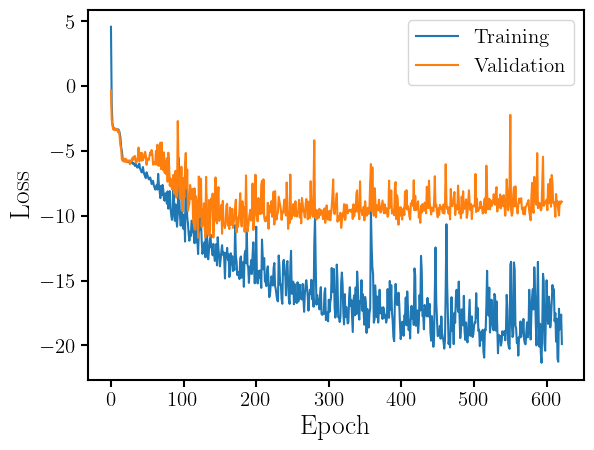

In [55]:
input_size = lenl * 6
output_size = lenl * 4
neurons, n_out = 64, 64 * 4
n_min = 16

model = NLIM.NoLIMItNet_fraction_compress_inference(input_size, neurons, output_size, n_out, n_min, 2).to(device)
NIN.resume(model, dir+"best_model-64.pth", device)

plot_history(dir)

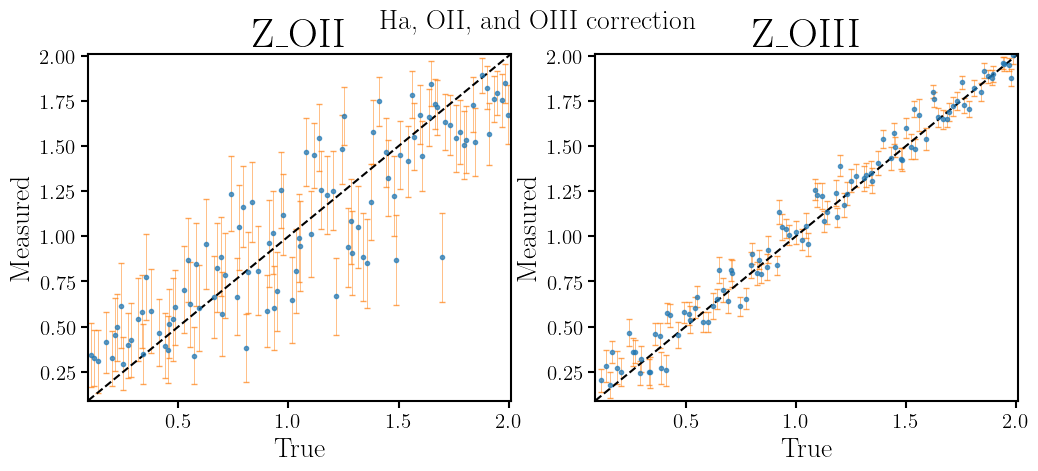

MSE error: 0.036322348


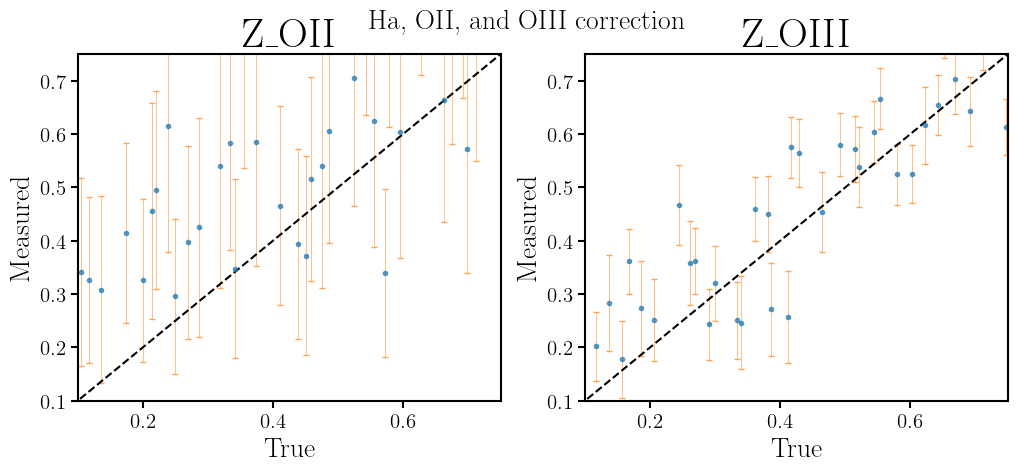

MSE error: 0.036322393


In [56]:
plot_fraction(test, model, lenl=lenl, device=device, norm_Z=True, save=None, limits=[0.09, 2.01], title='Ha, OII, and OIII correction', Z_names=['Z_OII', 'Z_OIII'], Z_min=np.array([0.1,0.1]), Z_max=np.array([2.0,2.0]), NZ=2, cont=True)
plot_fraction(test, model, lenl=lenl, device=device, norm_Z=True, save=None, limits=[0.1, 0.75], title='Ha, OII, and OIII correction', Z_names=['Z_OII', 'Z_OIII'], Z_min=np.array([0.1,0.1]), Z_max=np.array([2.0,2.0]), NZ=2, cont=True)

In [57]:
MSE_chi2(test, model, lenl, device, norm_Z=True, thresh=1e-3, Z_min=np.array([0.1,0.1]), Z_max=np.array([2.0,2.0]), NZ=2, names=['OII', 'OIII'], comp=4)

OII
0
MSE: 0.06502326
Reduced chi2: 1.5930520955798695
OIII
0
MSE: 0.0076215127
Reduced chi2: 2.248579451181356


In [ ]:
plot_fraction(test, model, lenl=lenl, device=device, norm_Z=True, save=None, limits=[0.09, 2.01], title='', Z_names=['[OII]', '[OIII]'], Z_min=np.array([0.1,0.1]), Z_max=np.array([2.0,2.0]), NZ=2, cont=True)


/tmp/ipykernel_7579/591512074.py:34: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax[0,0].set_xlim(0.,6000)
/tmp/ipykernel_7579/591512074.py:57: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax[0,1].set_xlim(0.,6000)
/tmp/ipykernel_7579/591512074.py:78: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax[1,0].set_xlim(0.,6000)
/tmp/ipykernel_7579/591512074.py:99: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax[1,1].set_xlim(0.,6000)


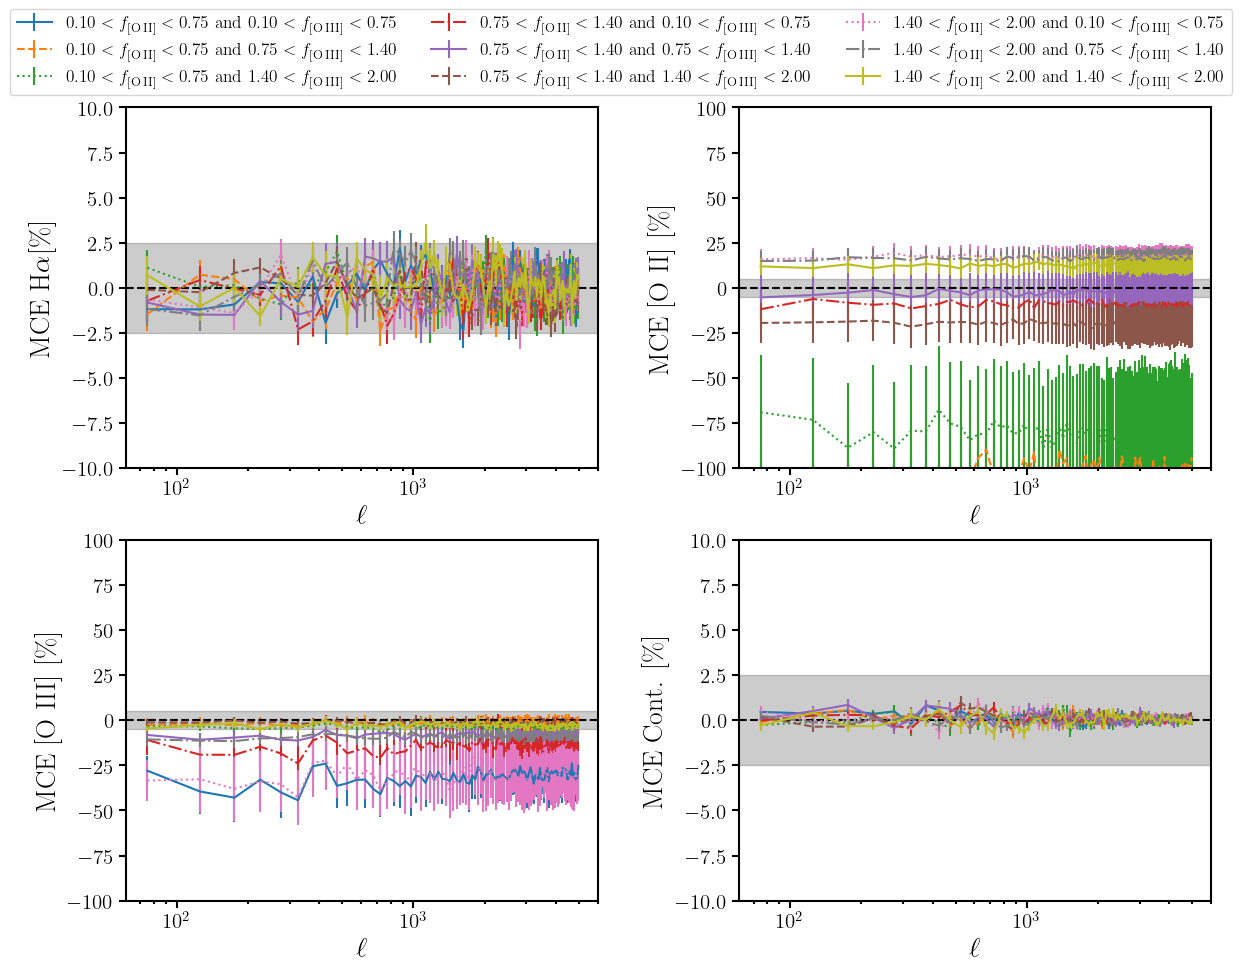

In [ ]:
Cl_int = np.load("Cl_Ha_0.npy")
ls = Cl_int[0,0,1:]

p_mean1, y_mean1, std_mean1, m1, sm1, N1 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 0.10, 0.10, 0.75, 0.75, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2, cont=True)
p_mean2, y_mean2, std_mean2, m2, sm2, N2 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 0.10, 0.75, 0.75, 1.40, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2, cont=True)
p_mean3, y_mean3, std_mean3, m3, sm3, N3 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 0.10, 1.40, 0.75, 2.00, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2, cont=True)
p_mean4, y_mean4, std_mean4, m4, sm4, N4 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 0.75, 0.10, 1.40, 0.75, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2, cont=True)
p_mean5, y_mean5, std_mean5, m5, sm5, N5 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 0.75, 0.75, 1.40, 1.40, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2, cont=True)
p_mean6, y_mean6, std_mean6, m6, sm6, N6 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 0.75, 1.40, 1.40, 2.00, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2, cont=True)
p_mean7, y_mean7, std_mean7, m7, sm7, N7 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 1.40, 0.10, 2.00, 0.75, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2, cont=True)
p_mean8, y_mean8, std_mean8, m8, sm8, N8 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 1.40, 0.75, 2.00, 1.40, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2, cont=True)
p_mean9, y_mean9, std_mean9, m9, sm9, N9 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 1.40, 1.40, 2.00, 2.00, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2, cont=True)

sel = (ls> 30.) & (ls < 5000)
l_plot = ls[sel]

fig, ax = plt.subplots(2, 2, figsize=(6*2+2, 4.5*2+1.3))

#Ha correction
ax[0,0].errorbar(l_plot, (1 - p_mean1[:lenl]/y_mean1[:lenl]) * 100., yerr=std_mean1[:lenl]/np.abs(y_mean1[:lenl])/np.sqrt(N1)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='solid')
ax[0,0].errorbar(l_plot, (1 - p_mean2[:lenl]/y_mean2[:lenl]) * 100., yerr=std_mean2[:lenl]/np.abs(y_mean2[:lenl])/np.sqrt(N2)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='dashed')
ax[0,0].errorbar(l_plot, (1 - p_mean3[:lenl]/y_mean3[:lenl]) * 100., yerr=std_mean3[:lenl]/np.abs(y_mean3[:lenl])/np.sqrt(N3)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='dotted')
ax[0,0].errorbar(l_plot, (1 - p_mean4[:lenl]/y_mean4[:lenl]) * 100., yerr=std_mean4[:lenl]/np.abs(y_mean4[:lenl])/np.sqrt(N4)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='dashdot')
ax[0,0].errorbar(l_plot, (1 - p_mean5[:lenl]/y_mean5[:lenl]) * 100., yerr=std_mean5[:lenl]/np.abs(y_mean5[:lenl])/np.sqrt(N5)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='solid')
ax[0,0].errorbar(l_plot, (1 - p_mean6[:lenl]/y_mean6[:lenl]) * 100., yerr=std_mean6[:lenl]/np.abs(y_mean6[:lenl])/np.sqrt(N6)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='dashed')
ax[0,0].errorbar(l_plot, (1 - p_mean7[:lenl]/y_mean7[:lenl]) * 100., yerr=std_mean7[:lenl]/np.abs(y_mean7[:lenl])/np.sqrt(N7)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='dotted')
ax[0,0].errorbar(l_plot, (1 - p_mean8[:lenl]/y_mean8[:lenl]) * 100., yerr=std_mean8[:lenl]/np.abs(y_mean8[:lenl])/np.sqrt(N8)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='dashdot')
ax[0,0].errorbar(l_plot, (1 - p_mean9[:lenl]/y_mean9[:lenl]) * 100., yerr=std_mean9[:lenl]/np.abs(y_mean9[:lenl])/np.sqrt(N9)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='solid')

ax[0,0].axhline(0, color='k', linestyle='dashed')
ax[0,0].set_xscale('log')
ax[0,0].set_xlabel('$\\ell$')
ax[0,0].set_ylim(-10,10)
ax[0,0].set_xlim(0.,6000)
ax[0,0].set_ylabel('''MCE H$\\alpha$[$\\%$]''')

ax[0,0].fill_between([0., 6000], -2.5, 2.5, alpha=.2, color='k')

ax[0,0].legend(ncols=3, loc='lower center', bbox_to_anchor=(1.05,1.01), fontsize=12.5)

#OII correction
ax[0,1].errorbar(l_plot, (1 - p_mean1[lenl:lenl*2]/y_mean1[lenl:lenl*2]) * 100., yerr=std_mean1[lenl:lenl*2]/np.abs(y_mean1[lenl:lenl*2])/np.sqrt(N1)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='solid')
ax[0,1].errorbar(l_plot, (1 - p_mean2[lenl:lenl*2]/y_mean2[lenl:lenl*2]) * 100., yerr=std_mean2[lenl:lenl*2]/np.abs(y_mean2[lenl:lenl*2])/np.sqrt(N2)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='dashed')
ax[0,1].errorbar(l_plot, (1 - p_mean3[lenl:lenl*2]/y_mean3[lenl:lenl*2]) * 100., yerr=std_mean3[lenl:lenl*2]/np.abs(y_mean3[lenl:lenl*2])/np.sqrt(N3)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='dotted')
ax[0,1].errorbar(l_plot, (1 - p_mean4[lenl:lenl*2]/y_mean4[lenl:lenl*2]) * 100., yerr=std_mean4[lenl:lenl*2]/np.abs(y_mean4[lenl:lenl*2])/np.sqrt(N4)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='dashdot')
ax[0,1].errorbar(l_plot, (1 - p_mean5[lenl:lenl*2]/y_mean5[lenl:lenl*2]) * 100., yerr=std_mean5[lenl:lenl*2]/np.abs(y_mean5[lenl:lenl*2])/np.sqrt(N5)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='solid')
ax[0,1].errorbar(l_plot, (1 - p_mean6[lenl:lenl*2]/y_mean6[lenl:lenl*2]) * 100., yerr=std_mean6[lenl:lenl*2]/np.abs(y_mean6[lenl:lenl*2])/np.sqrt(N6)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='dashed')
ax[0,1].errorbar(l_plot, (1 - p_mean7[lenl:lenl*2]/y_mean7[lenl:lenl*2]) * 100., yerr=std_mean7[lenl:lenl*2]/np.abs(y_mean7[lenl:lenl*2])/np.sqrt(N7)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='dotted')
ax[0,1].errorbar(l_plot, (1 - p_mean8[lenl:lenl*2]/y_mean8[lenl:lenl*2]) * 100., yerr=std_mean8[lenl:lenl*2]/np.abs(y_mean8[lenl:lenl*2])/np.sqrt(N8)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='dashdot')
ax[0,1].errorbar(l_plot, (1 - p_mean9[lenl:lenl*2]/y_mean9[lenl:lenl*2]) * 100., yerr=std_mean9[lenl:lenl*2]/np.abs(y_mean9[lenl:lenl*2])/np.sqrt(N9)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='solid')


ax[0,1].axhline(0, color='k', linestyle='dashed')
ax[0,1].set_xscale('log')
ax[0,1].set_xlabel('$\\ell$')
ax[0,1].set_ylim(-100,100)
ax[0,1].set_xlim(0.,6000)
ax[0,1].set_ylabel('''MCE [O II] [$\\%$]''')

ax[0,1].fill_between([0., 6000], -5, 5, alpha=.2, color='k')

#OIII correction
ax[1,0].errorbar(l_plot, (1 - p_mean1[lenl*2:lenl*3]/y_mean1[lenl*2:lenl*3]) * 100., yerr=std_mean1[lenl*2:lenl*3]/np.abs(y_mean1[lenl*2:lenl*3])/np.sqrt(N1)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='solid')
ax[1,0].errorbar(l_plot, (1 - p_mean2[lenl*2:lenl*3]/y_mean2[lenl*2:lenl*3]) * 100., yerr=std_mean2[lenl*2:lenl*3]/np.abs(y_mean2[lenl*2:lenl*3])/np.sqrt(N2)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='dashed')
ax[1,0].errorbar(l_plot, (1 - p_mean3[lenl*2:lenl*3]/y_mean3[lenl*2:lenl*3]) * 100., yerr=std_mean3[lenl*2:lenl*3]/np.abs(y_mean3[lenl*2:lenl*3])/np.sqrt(N3)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='dotted')
ax[1,0].errorbar(l_plot, (1 - p_mean4[lenl*2:lenl*3]/y_mean4[lenl*2:lenl*3]) * 100., yerr=std_mean4[lenl*2:lenl*3]/np.abs(y_mean4[lenl*2:lenl*3])/np.sqrt(N4)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='dashdot')
ax[1,0].errorbar(l_plot, (1 - p_mean5[lenl*2:lenl*3]/y_mean5[lenl*2:lenl*3]) * 100., yerr=std_mean5[lenl*2:lenl*3]/np.abs(y_mean5[lenl*2:lenl*3])/np.sqrt(N5)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='solid')
ax[1,0].errorbar(l_plot, (1 - p_mean6[lenl*2:lenl*3]/y_mean6[lenl*2:lenl*3]) * 100., yerr=std_mean6[lenl*2:lenl*3]/np.abs(y_mean6[lenl*2:lenl*3])/np.sqrt(N6)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='dashed')
ax[1,0].errorbar(l_plot, (1 - p_mean7[lenl*2:lenl*3]/y_mean7[lenl*2:lenl*3]) * 100., yerr=std_mean7[lenl*2:lenl*3]/np.abs(y_mean7[lenl*2:lenl*3])/np.sqrt(N7)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='dotted')
ax[1,0].errorbar(l_plot, (1 - p_mean8[lenl*2:lenl*3]/y_mean8[lenl*2:lenl*3]) * 100., yerr=std_mean8[lenl*2:lenl*3]/np.abs(y_mean8[lenl*2:lenl*3])/np.sqrt(N8)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='dashdot')
ax[1,0].errorbar(l_plot, (1 - p_mean9[lenl*2:lenl*3]/y_mean9[lenl*2:lenl*3]) * 100., yerr=std_mean9[lenl*2:lenl*3]/np.abs(y_mean9[lenl*2:lenl*3])/np.sqrt(N9)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='solid')


ax[1,0].axhline(0, color='k', linestyle='dashed')
ax[1,0].set_xscale('log')
ax[1,0].set_xlabel('$\\ell$')
ax[1,0].set_ylim(-100,100)
ax[1,0].set_xlim(0.,6000)
ax[1,0].set_ylabel('''MCE [O III] [$\\%$]''')

ax[1,0].fill_between([0., 6000], -5, 5, alpha=.2, color='k')

#Continuum correction
ax[1,1].errorbar(l_plot, (1 - p_mean1[lenl*3:lenl*4]/y_mean1[lenl*3:lenl*4]) * 100., yerr=std_mean1[lenl*3:lenl*4]/np.abs(y_mean1[lenl*3:lenl*4])/np.sqrt(N1)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='solid')
ax[1,1].errorbar(l_plot, (1 - p_mean2[lenl*3:lenl*4]/y_mean2[lenl*3:lenl*4]) * 100., yerr=std_mean2[lenl*3:lenl*4]/np.abs(y_mean2[lenl*3:lenl*4])/np.sqrt(N2)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='dashed')
ax[1,1].errorbar(l_plot, (1 - p_mean3[lenl*3:lenl*4]/y_mean3[lenl*3:lenl*4]) * 100., yerr=std_mean3[lenl*3:lenl*4]/np.abs(y_mean3[lenl*3:lenl*4])/np.sqrt(N3)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='dotted')
ax[1,1].errorbar(l_plot, (1 - p_mean4[lenl*3:lenl*4]/y_mean4[lenl*3:lenl*4]) * 100., yerr=std_mean4[lenl*3:lenl*4]/np.abs(y_mean4[lenl*3:lenl*4])/np.sqrt(N4)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='dashdot')
ax[1,1].errorbar(l_plot, (1 - p_mean5[lenl*3:lenl*4]/y_mean5[lenl*3:lenl*4]) * 100., yerr=std_mean5[lenl*3:lenl*4]/np.abs(y_mean5[lenl*3:lenl*4])/np.sqrt(N5)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='solid')
ax[1,1].errorbar(l_plot, (1 - p_mean6[lenl*3:lenl*4]/y_mean6[lenl*3:lenl*4]) * 100., yerr=std_mean6[lenl*3:lenl*4]/np.abs(y_mean6[lenl*3:lenl*4])/np.sqrt(N6)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='dashed')
ax[1,1].errorbar(l_plot, (1 - p_mean7[lenl*3:lenl*4]/y_mean7[lenl*3:lenl*4]) * 100., yerr=std_mean7[lenl*3:lenl*4]/np.abs(y_mean7[lenl*3:lenl*4])/np.sqrt(N7)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='dotted')
ax[1,1].errorbar(l_plot, (1 - p_mean8[lenl*3:lenl*4]/y_mean8[lenl*3:lenl*4]) * 100., yerr=std_mean8[lenl*3:lenl*4]/np.abs(y_mean8[lenl*3:lenl*4])/np.sqrt(N8)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='dashdot')
ax[1,1].errorbar(l_plot, (1 - p_mean9[lenl*3:lenl*4]/y_mean9[lenl*3:lenl*4]) * 100., yerr=std_mean9[lenl*3:lenl*4]/np.abs(y_mean9[lenl*3:lenl*4])/np.sqrt(N9)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='solid')


ax[1,1].axhline(0, color='k', linestyle='dashed')
ax[1,1].set_xscale('log')
ax[1,1].set_xlabel('$\\ell$')
ax[1,1].set_ylim(-10,10)
ax[1,1].set_xlim(0.,6000)
ax[1,1].set_ylabel('''MCE Cont. [$\\%$]''')

ax[1,1].fill_between([0., 6000], -2.5, 2.5, alpha=.2, color='k')

plt.subplots_adjust(wspace=0.3)

#plt.savefig('../figures/MCE-scatter01-Cont-multich.pdf', bbox_inches='tight')
plt.show()

In [87]:
grads = compute_input_gradients(model, test_dataloader)
print(grads.shape)

(594,)


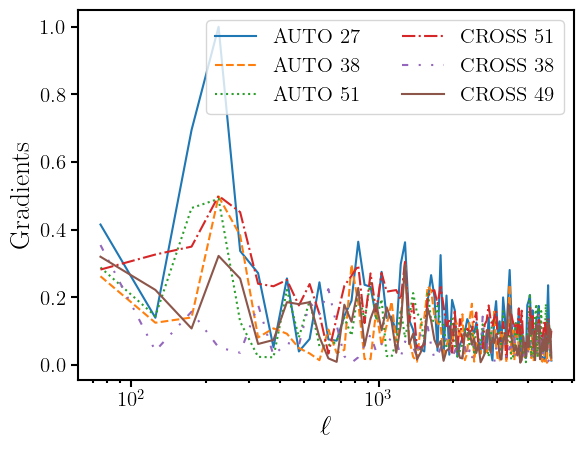

In [ ]:
Cl_int = np.load("Cl_Ha_0.npy")
ls = Cl_int[0,0,1:]


sel = (ls> 30.) & (ls < 5000)
l_plot = ls[sel]

maxgrad = np.max(grads)

#Ha correction
plt.semilogx(l_plot, grads[:lenl] / maxgrad, label='AUTO 27', linestyle='solid')
plt.semilogx(l_plot, grads[lenl:lenl*2] / maxgrad, label='AUTO 38', linestyle='dashed')
plt.semilogx(l_plot, grads[lenl*2:lenl*3] / maxgrad, label='AUTO 51', linestyle='dotted')
plt.semilogx(l_plot, grads[lenl*3:lenl*4] / maxgrad, label='CROSS 51', linestyle='dashdot')
plt.semilogx(l_plot, grads[lenl*4:lenl*5] / maxgrad, label='CROSS 38', linestyle= (0, (3, 5, 1, 5, 1, 5)))
plt.semilogx(l_plot, grads[lenl*5:lenl*6] / maxgrad, label='CROSS 49', linestyle= 'solid')

plt.xlabel('$\\ell$')
plt.ylabel('Gradients')
plt.legend(ncols=2)

plt.show()

#### Constrained, Target: H $\alpha$, interlopers: OII, OIII, channel 27, AUTO27+AUTO38+AUTO51+CROSS38+CROSS51+CROSS49+CROSS34(continuum) $\lambda=0.05$ scatter 01

In [ ]:
dir = '../trained-models/Ha_OII_OIII_Cont_scattered01-ch27-A27A38A51C38C51C49XC-l5e-2/NoLMItNet-Logloss-sb1024-component-corrections-moments/'

min_corr = np.load(dir+'min_correction.npy')
max_corr = np.load(dir+'max_correction.npy')

min_Cls = np.load(dir+'min_Cls.npy')
max_Cls = np.load(dir+'max_Cls.npy')

Cls, labels, lenl, max_corr, min_corr = NLIM.load_Cls_auto_and_cross("local-Cls_Ha_OII_OIII_Cont_1024-scattered-01-ContX.csv", 27, 5000, 30, True, True, Z_names=['Z_OII', 'Z_OIII'], Z_min=np.array([0.1,0.1]), Z_max=np.array([2.0,2.0]), auto_names=['Ha_OII_OIII_Cont'], cross_names=['OII_all_cross_1', 'OIII_all_cross_1'], true_names=['Ha', 'OII', 'OIII', 'Cont'], contam_name='Ha_OII_OIII_Cont', input_channels=np.array([27,38,51]), add_cross=['OIII_all_cross', 'Cont_all_cross'], add_channel=[38,27])

Cls = NINf.maxmin_corr(Cls, max_Cls, min_Cls)
norm = np.ones(len(Cls))

train_fraction = 0.75
val_fraction = 0.9

n_train = int(len(Cls)*train_fraction)
n_val = int(len(Cls)*val_fraction)
    
Cls_test = Cls[n_val:]

labels_test = labels[n_val:]

norm_test = np.array(norm[n_val:, np.newaxis])

test = NIN.PkDataset(Cls_test, labels_test, norm_test)

test_batch = 6
test_dataloader = DataLoader(test, batch_size=test_batch, shuffle=False)

1 64 32
2 32 16
3 16 32
4 32 64
5 64 128
6 128 256


/home/cagliari/Documents/Work/LAPTh/interloper-IM/trained-models/../src/NoInterNet_model.py:203: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.lo

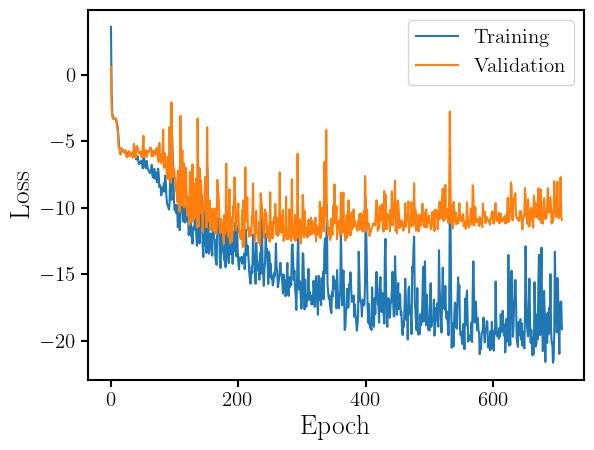

In [50]:
input_size = lenl * 7
output_size = lenl * 4
neurons, n_out = 64, 64 * 4
n_min = 16

model = NLIM.NoLIMItNet_fraction_compress_inference(input_size, neurons, output_size, n_out, n_min, 2).to(device)
NIN.resume(model, dir+"best_model-64.pth", device)

plot_history(dir)

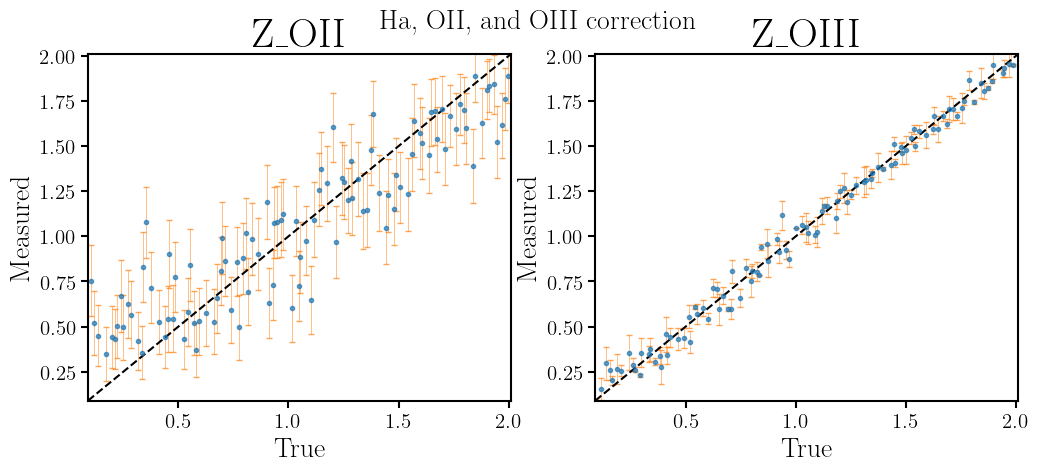

MSE error: 0.029487059


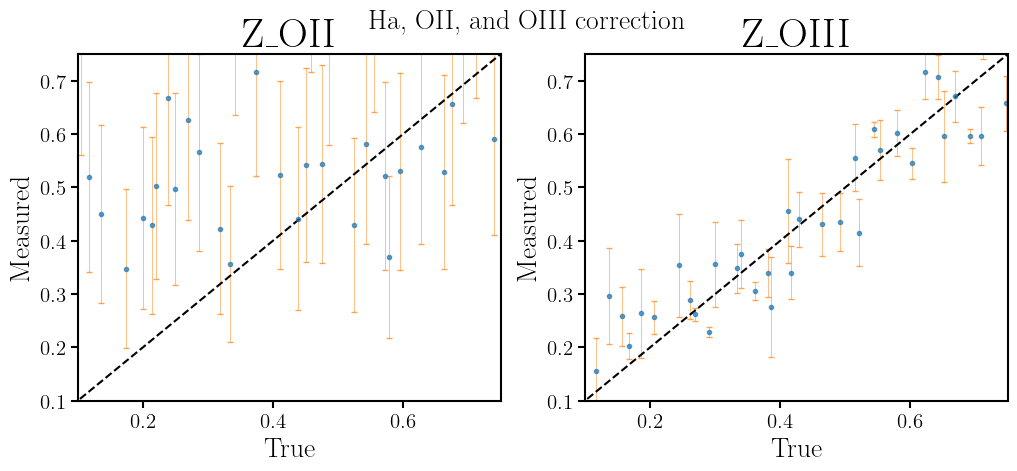

MSE error: 0.029487073


In [51]:
plot_fraction(test, model, lenl=lenl, device=device, norm_Z=True, save=None, limits=[0.09, 2.01], title='Ha, OII, and OIII correction', Z_names=['Z_OII', 'Z_OIII'], Z_min=np.array([0.1,0.1]), Z_max=np.array([2.0,2.0]), NZ=2, cont=True)
plot_fraction(test, model, lenl=lenl, device=device, norm_Z=True, save=None, limits=[0.1, 0.75], title='Ha, OII, and OIII correction', Z_names=['Z_OII', 'Z_OIII'], Z_min=np.array([0.1,0.1]), Z_max=np.array([2.0,2.0]), NZ=2, cont=True)

In [52]:
MSE_chi2(test, model, lenl, device, norm_Z=True, thresh=1e-3, Z_min=np.array([0.1,0.1]), Z_max=np.array([2.0,2.0]), NZ=2, names=['OII', 'OIII'], comp=4)

OII
0
MSE: 0.055700015
Reduced chi2: 1.5218002171192355
OIII
1
MSE: 0.003287259
Reduced chi2: 6.572605170092537


In [ ]:
plot_fraction(test, model, lenl=lenl, device=device, norm_Z=True, save=None, limits=[0.09, 2.01], title='', Z_names=['[OII]', '[OIII]'], Z_min=np.array([0.1,0.1]), Z_max=np.array([2.0,2.0]), NZ=2, cont=True)


/tmp/ipykernel_7579/423638466.py:34: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax[0,0].set_xlim(0.,6000)
/tmp/ipykernel_7579/423638466.py:57: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax[0,1].set_xlim(0.,6000)
/tmp/ipykernel_7579/423638466.py:78: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax[1,0].set_xlim(0.,6000)
/tmp/ipykernel_7579/423638466.py:99: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax[1,1].set_xlim(0.,6000)


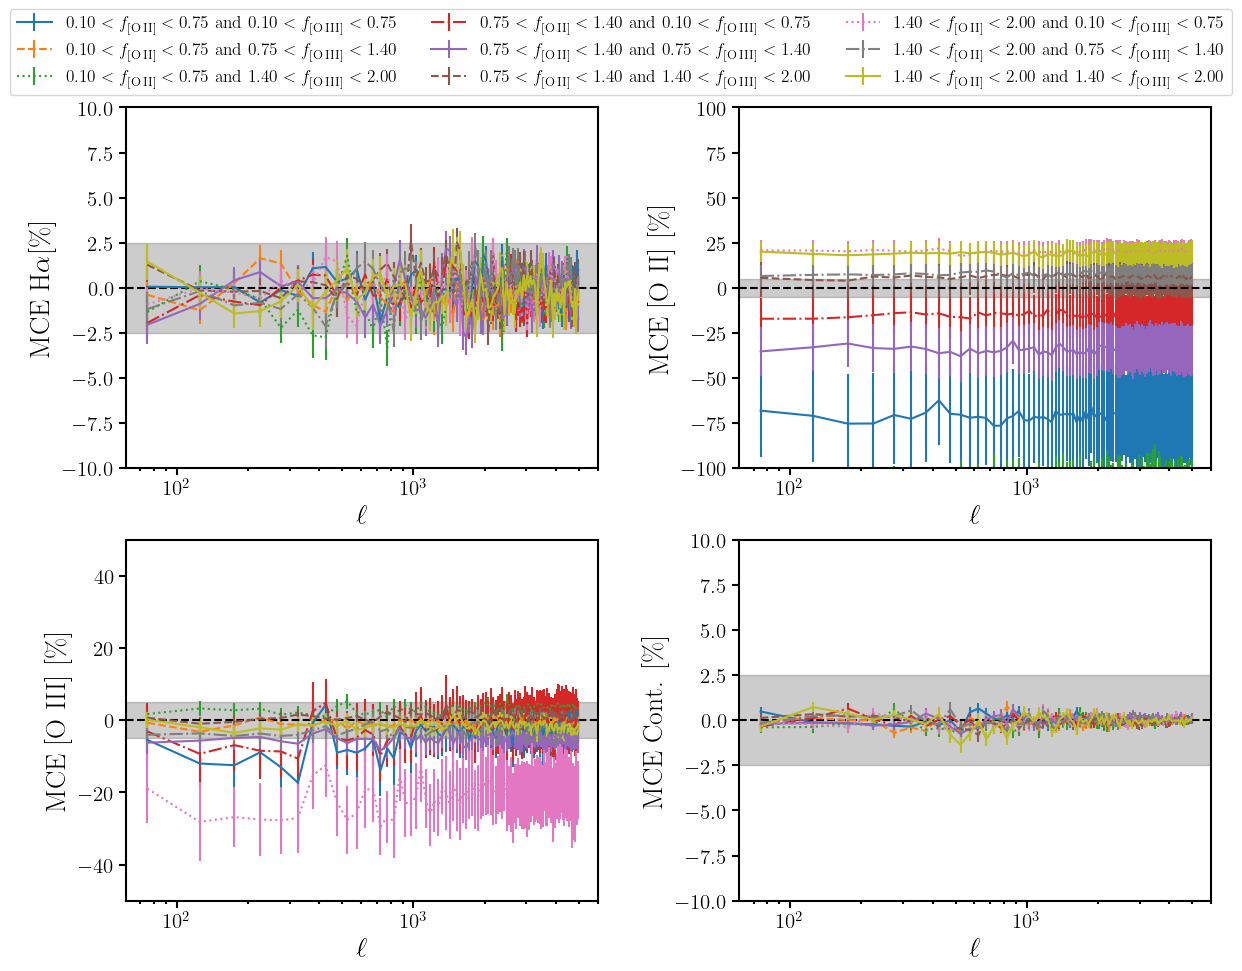

In [ ]:
Cl_int = np.load("Cl_Ha_0.npy")
ls = Cl_int[0,0,1:]

p_mean1, y_mean1, std_mean1, m1, sm1, N1 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 0.10, 0.10, 0.75, 0.75, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2, cont=True)
p_mean2, y_mean2, std_mean2, m2, sm2, N2 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 0.10, 0.75, 0.75, 1.40, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2, cont=True)
p_mean3, y_mean3, std_mean3, m3, sm3, N3 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 0.10, 1.40, 0.75, 2.00, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2, cont=True)
p_mean4, y_mean4, std_mean4, m4, sm4, N4 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 0.75, 0.10, 1.40, 0.75, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2, cont=True)
p_mean5, y_mean5, std_mean5, m5, sm5, N5 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 0.75, 0.75, 1.40, 1.40, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2, cont=True)
p_mean6, y_mean6, std_mean6, m6, sm6, N6 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 0.75, 1.40, 1.40, 2.00, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2, cont=True)
p_mean7, y_mean7, std_mean7, m7, sm7, N7 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 1.40, 0.10, 2.00, 0.75, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2, cont=True)
p_mean8, y_mean8, std_mean8, m8, sm8, N8 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 1.40, 0.75, 2.00, 1.40, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2, cont=True)
p_mean9, y_mean9, std_mean9, m9, sm9, N9 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 1.40, 1.40, 2.00, 2.00, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2, cont=True)

sel = (ls> 30.) & (ls < 5000)
l_plot = ls[sel]

fig, ax = plt.subplots(2, 2, figsize=(6*2+2, 4.5*2+1.3))

#Ha correction
ax[0,0].errorbar(l_plot, (1 - p_mean1[:lenl]/y_mean1[:lenl]) * 100., yerr=std_mean1[:lenl]/np.abs(y_mean1[:lenl])/np.sqrt(N1)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='solid')
ax[0,0].errorbar(l_plot, (1 - p_mean2[:lenl]/y_mean2[:lenl]) * 100., yerr=std_mean2[:lenl]/np.abs(y_mean2[:lenl])/np.sqrt(N2)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='dashed')
ax[0,0].errorbar(l_plot, (1 - p_mean3[:lenl]/y_mean3[:lenl]) * 100., yerr=std_mean3[:lenl]/np.abs(y_mean3[:lenl])/np.sqrt(N3)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='dotted')
ax[0,0].errorbar(l_plot, (1 - p_mean4[:lenl]/y_mean4[:lenl]) * 100., yerr=std_mean4[:lenl]/np.abs(y_mean4[:lenl])/np.sqrt(N4)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='dashdot')
ax[0,0].errorbar(l_plot, (1 - p_mean5[:lenl]/y_mean5[:lenl]) * 100., yerr=std_mean5[:lenl]/np.abs(y_mean5[:lenl])/np.sqrt(N5)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='solid')
ax[0,0].errorbar(l_plot, (1 - p_mean6[:lenl]/y_mean6[:lenl]) * 100., yerr=std_mean6[:lenl]/np.abs(y_mean6[:lenl])/np.sqrt(N6)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='dashed')
ax[0,0].errorbar(l_plot, (1 - p_mean7[:lenl]/y_mean7[:lenl]) * 100., yerr=std_mean7[:lenl]/np.abs(y_mean7[:lenl])/np.sqrt(N7)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='dotted')
ax[0,0].errorbar(l_plot, (1 - p_mean8[:lenl]/y_mean8[:lenl]) * 100., yerr=std_mean8[:lenl]/np.abs(y_mean8[:lenl])/np.sqrt(N8)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='dashdot')
ax[0,0].errorbar(l_plot, (1 - p_mean9[:lenl]/y_mean9[:lenl]) * 100., yerr=std_mean9[:lenl]/np.abs(y_mean9[:lenl])/np.sqrt(N9)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='solid')

ax[0,0].axhline(0, color='k', linestyle='dashed')
ax[0,0].set_xscale('log')
ax[0,0].set_xlabel('$\\ell$')
ax[0,0].set_ylim(-10,10)
ax[0,0].set_xlim(0.,6000)
ax[0,0].set_ylabel('''MCE H$\\alpha$[$\\%$]''')

ax[0,0].fill_between([0., 6000], -2.5, 2.5, alpha=.2, color='k')

ax[0,0].legend(ncols=3, loc='lower center', bbox_to_anchor=(1.05,1.01), fontsize=12.5)

#OII correction
ax[0,1].errorbar(l_plot, (1 - p_mean1[lenl:lenl*2]/y_mean1[lenl:lenl*2]) * 100., yerr=std_mean1[lenl:lenl*2]/np.abs(y_mean1[lenl:lenl*2])/np.sqrt(N1)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='solid')
ax[0,1].errorbar(l_plot, (1 - p_mean2[lenl:lenl*2]/y_mean2[lenl:lenl*2]) * 100., yerr=std_mean2[lenl:lenl*2]/np.abs(y_mean2[lenl:lenl*2])/np.sqrt(N2)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='dashed')
ax[0,1].errorbar(l_plot, (1 - p_mean3[lenl:lenl*2]/y_mean3[lenl:lenl*2]) * 100., yerr=std_mean3[lenl:lenl*2]/np.abs(y_mean3[lenl:lenl*2])/np.sqrt(N3)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='dotted')
ax[0,1].errorbar(l_plot, (1 - p_mean4[lenl:lenl*2]/y_mean4[lenl:lenl*2]) * 100., yerr=std_mean4[lenl:lenl*2]/np.abs(y_mean4[lenl:lenl*2])/np.sqrt(N4)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='dashdot')
ax[0,1].errorbar(l_plot, (1 - p_mean5[lenl:lenl*2]/y_mean5[lenl:lenl*2]) * 100., yerr=std_mean5[lenl:lenl*2]/np.abs(y_mean5[lenl:lenl*2])/np.sqrt(N5)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='solid')
ax[0,1].errorbar(l_plot, (1 - p_mean6[lenl:lenl*2]/y_mean6[lenl:lenl*2]) * 100., yerr=std_mean6[lenl:lenl*2]/np.abs(y_mean6[lenl:lenl*2])/np.sqrt(N6)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='dashed')
ax[0,1].errorbar(l_plot, (1 - p_mean7[lenl:lenl*2]/y_mean7[lenl:lenl*2]) * 100., yerr=std_mean7[lenl:lenl*2]/np.abs(y_mean7[lenl:lenl*2])/np.sqrt(N7)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='dotted')
ax[0,1].errorbar(l_plot, (1 - p_mean8[lenl:lenl*2]/y_mean8[lenl:lenl*2]) * 100., yerr=std_mean8[lenl:lenl*2]/np.abs(y_mean8[lenl:lenl*2])/np.sqrt(N8)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='dashdot')
ax[0,1].errorbar(l_plot, (1 - p_mean9[lenl:lenl*2]/y_mean9[lenl:lenl*2]) * 100., yerr=std_mean9[lenl:lenl*2]/np.abs(y_mean9[lenl:lenl*2])/np.sqrt(N9)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='solid')


ax[0,1].axhline(0, color='k', linestyle='dashed')
ax[0,1].set_xscale('log')
ax[0,1].set_xlabel('$\\ell$')
ax[0,1].set_ylim(-100,100)
ax[0,1].set_xlim(0.,6000)
ax[0,1].set_ylabel('''MCE [O II] [$\\%$]''')

ax[0,1].fill_between([0., 6000], -5, 5, alpha=.2, color='k')

#OIII correction
ax[1,0].errorbar(l_plot, (1 - p_mean1[lenl*2:lenl*3]/y_mean1[lenl*2:lenl*3]) * 100., yerr=std_mean1[lenl*2:lenl*3]/np.abs(y_mean1[lenl*2:lenl*3])/np.sqrt(N1)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='solid')
ax[1,0].errorbar(l_plot, (1 - p_mean2[lenl*2:lenl*3]/y_mean2[lenl*2:lenl*3]) * 100., yerr=std_mean2[lenl*2:lenl*3]/np.abs(y_mean2[lenl*2:lenl*3])/np.sqrt(N2)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='dashed')
ax[1,0].errorbar(l_plot, (1 - p_mean3[lenl*2:lenl*3]/y_mean3[lenl*2:lenl*3]) * 100., yerr=std_mean3[lenl*2:lenl*3]/np.abs(y_mean3[lenl*2:lenl*3])/np.sqrt(N3)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='dotted')
ax[1,0].errorbar(l_plot, (1 - p_mean4[lenl*2:lenl*3]/y_mean4[lenl*2:lenl*3]) * 100., yerr=std_mean4[lenl*2:lenl*3]/np.abs(y_mean4[lenl*2:lenl*3])/np.sqrt(N4)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='dashdot')
ax[1,0].errorbar(l_plot, (1 - p_mean5[lenl*2:lenl*3]/y_mean5[lenl*2:lenl*3]) * 100., yerr=std_mean5[lenl*2:lenl*3]/np.abs(y_mean5[lenl*2:lenl*3])/np.sqrt(N5)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='solid')
ax[1,0].errorbar(l_plot, (1 - p_mean6[lenl*2:lenl*3]/y_mean6[lenl*2:lenl*3]) * 100., yerr=std_mean6[lenl*2:lenl*3]/np.abs(y_mean6[lenl*2:lenl*3])/np.sqrt(N6)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='dashed')
ax[1,0].errorbar(l_plot, (1 - p_mean7[lenl*2:lenl*3]/y_mean7[lenl*2:lenl*3]) * 100., yerr=std_mean7[lenl*2:lenl*3]/np.abs(y_mean7[lenl*2:lenl*3])/np.sqrt(N7)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='dotted')
ax[1,0].errorbar(l_plot, (1 - p_mean8[lenl*2:lenl*3]/y_mean8[lenl*2:lenl*3]) * 100., yerr=std_mean8[lenl*2:lenl*3]/np.abs(y_mean8[lenl*2:lenl*3])/np.sqrt(N8)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='dashdot')
ax[1,0].errorbar(l_plot, (1 - p_mean9[lenl*2:lenl*3]/y_mean9[lenl*2:lenl*3]) * 100., yerr=std_mean9[lenl*2:lenl*3]/np.abs(y_mean9[lenl*2:lenl*3])/np.sqrt(N9)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='solid')


ax[1,0].axhline(0, color='k', linestyle='dashed')
ax[1,0].set_xscale('log')
ax[1,0].set_xlabel('$\\ell$')
ax[1,0].set_ylim(-50,50)
ax[1,0].set_xlim(0.,6000)
ax[1,0].set_ylabel('''MCE [O III] [$\\%$]''')

ax[1,0].fill_between([0., 6000], -5, 5, alpha=.2, color='k')

#Continuum correction
ax[1,1].errorbar(l_plot, (1 - p_mean1[lenl*3:lenl*4]/y_mean1[lenl*3:lenl*4]) * 100., yerr=std_mean1[lenl*3:lenl*4]/np.abs(y_mean1[lenl*3:lenl*4])/np.sqrt(N1)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='solid')
ax[1,1].errorbar(l_plot, (1 - p_mean2[lenl*3:lenl*4]/y_mean2[lenl*3:lenl*4]) * 100., yerr=std_mean2[lenl*3:lenl*4]/np.abs(y_mean2[lenl*3:lenl*4])/np.sqrt(N2)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='dashed')
ax[1,1].errorbar(l_plot, (1 - p_mean3[lenl*3:lenl*4]/y_mean3[lenl*3:lenl*4]) * 100., yerr=std_mean3[lenl*3:lenl*4]/np.abs(y_mean3[lenl*3:lenl*4])/np.sqrt(N3)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='dotted')
ax[1,1].errorbar(l_plot, (1 - p_mean4[lenl*3:lenl*4]/y_mean4[lenl*3:lenl*4]) * 100., yerr=std_mean4[lenl*3:lenl*4]/np.abs(y_mean4[lenl*3:lenl*4])/np.sqrt(N4)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='dashdot')
ax[1,1].errorbar(l_plot, (1 - p_mean5[lenl*3:lenl*4]/y_mean5[lenl*3:lenl*4]) * 100., yerr=std_mean5[lenl*3:lenl*4]/np.abs(y_mean5[lenl*3:lenl*4])/np.sqrt(N5)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='solid')
ax[1,1].errorbar(l_plot, (1 - p_mean6[lenl*3:lenl*4]/y_mean6[lenl*3:lenl*4]) * 100., yerr=std_mean6[lenl*3:lenl*4]/np.abs(y_mean6[lenl*3:lenl*4])/np.sqrt(N6)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='dashed')
ax[1,1].errorbar(l_plot, (1 - p_mean7[lenl*3:lenl*4]/y_mean7[lenl*3:lenl*4]) * 100., yerr=std_mean7[lenl*3:lenl*4]/np.abs(y_mean7[lenl*3:lenl*4])/np.sqrt(N7)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='dotted')
ax[1,1].errorbar(l_plot, (1 - p_mean8[lenl*3:lenl*4]/y_mean8[lenl*3:lenl*4]) * 100., yerr=std_mean8[lenl*3:lenl*4]/np.abs(y_mean8[lenl*3:lenl*4])/np.sqrt(N8)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='dashdot')
ax[1,1].errorbar(l_plot, (1 - p_mean9[lenl*3:lenl*4]/y_mean9[lenl*3:lenl*4]) * 100., yerr=std_mean9[lenl*3:lenl*4]/np.abs(y_mean9[lenl*3:lenl*4])/np.sqrt(N9)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='solid')


ax[1,1].axhline(0, color='k', linestyle='dashed')
ax[1,1].set_xscale('log')
ax[1,1].set_xlabel('$\\ell$')
ax[1,1].set_ylim(-10,10)
ax[1,1].set_xlim(0.,6000)
ax[1,1].set_ylabel('''MCE Cont. [$\\%$]''')

ax[1,1].fill_between([0., 6000], -2.5, 2.5, alpha=.2, color='k')

plt.subplots_adjust(wspace=0.3)

#plt.savefig('../figures/MCE-scatter01-Cont-multichXC.pdf', bbox_inches='tight')
plt.show()

#### Constrained, Target: H $\alpha$, interlopers: OII, OIII, channel 27, AUTO27+AUTO38+AUTO51+CROSS38+CROSS51+CROSS49 $\lambda=0.05$ rescaled .015 scatter 01

In [ ]:
dir = '../trained-models/Ha_OII_OIII_015Cont_scattered01-ch27-A27A38A51C38C51C49-l5e-2/NoLMItNet-Logloss-sb1024-component-corrections-moments/'

min_corr = np.load(dir+'min_correction.npy')
max_corr = np.load(dir+'max_correction.npy')

min_Cls = np.load(dir+'min_Cls.npy')
max_Cls = np.load(dir+'max_Cls.npy')

Cls, labels, lenl, max_corr, min_corr = NLIM.load_Cls_auto_and_cross("local-Cls_Ha_OII_OIII_015Cont_1024-scattered-01.csv", 27, 5000, 30, True, True, Z_names=['Z_OII', 'Z_OIII'], Z_min=np.array([0.1,0.1]), Z_max=np.array([2.0,2.0]), auto_names=['Ha_OII_OIII_Cont'], cross_names=['OII_all_cross_1', 'OIII_all_cross_1'], true_names=['Ha', 'OII', 'OIII', 'Cont'], contam_name='Ha_OII_OIII_Cont', input_channels=np.array([27,38,51]), add_cross=['OIII_all_cross'], add_channel=[38])

Cls = NINf.maxmin_corr(Cls, max_Cls, min_Cls)
norm = np.ones(len(Cls))

train_fraction = 0.75
val_fraction = 0.9

n_train = int(len(Cls)*train_fraction)
n_val = int(len(Cls)*val_fraction)
    
Cls_test = Cls[n_val:]

labels_test = labels[n_val:]

norm_test = np.array(norm[n_val:, np.newaxis])

test = NIN.PkDataset(Cls_test, labels_test, norm_test)

test_batch = 6
test_dataloader = DataLoader(test, batch_size=test_batch, shuffle=False)

1 64 32
2 32 16
3 16 32
4 32 64
5 64 128
6 128 256


/home/cagliari/Documents/Work/LAPTh/interloper-IM/trained-models/../src/NoInterNet_model.py:203: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.lo

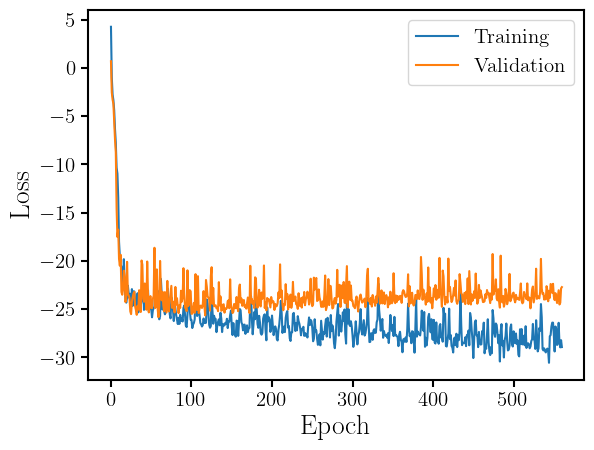

In [42]:
input_size = lenl * 6
output_size = lenl * 4
neurons, n_out = 64, 64 * 4
n_min = 16

model = NLIM.NoLIMItNet_fraction_compress_inference(input_size, neurons, output_size, n_out, n_min, 2).to(device)
NIN.resume(model, dir+"best_model-64.pth", device)

plot_history(dir)

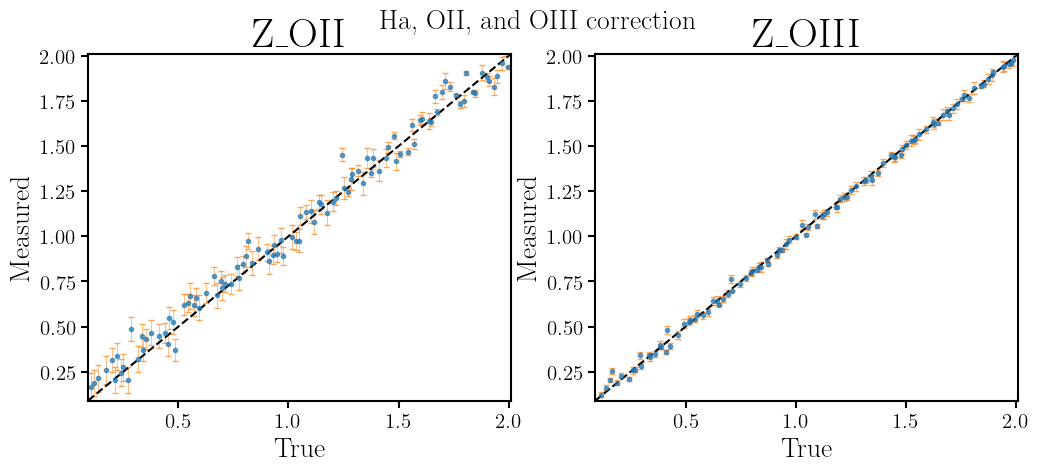

MSE error: 0.00259871


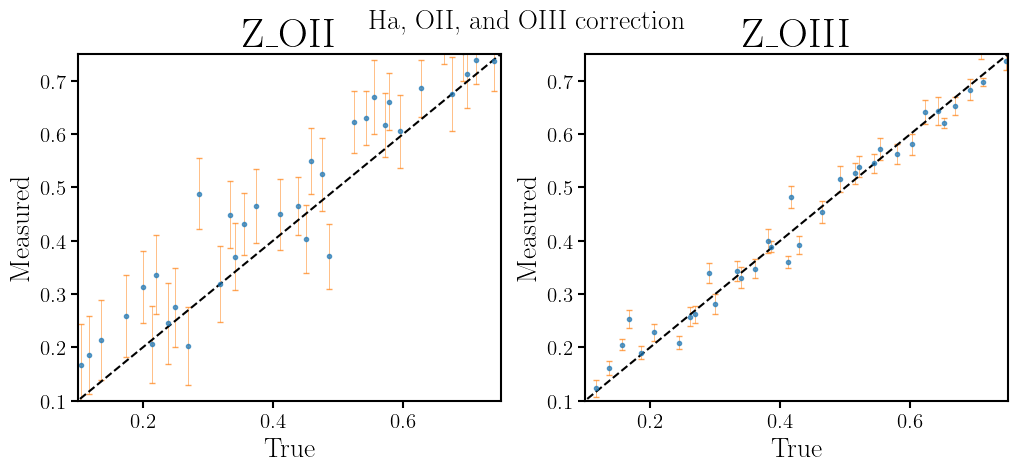

MSE error: 0.0025987108


In [43]:
plot_fraction(test, model, lenl=lenl, device=device, norm_Z=True, save=None, limits=[0.09, 2.01], title='Ha, OII, and OIII correction', Z_names=['Z_OII', 'Z_OIII'], Z_min=np.array([0.1,0.1]), Z_max=np.array([2.0,2.0]), NZ=2, cont=True)
plot_fraction(test, model, lenl=lenl, device=device, norm_Z=True, save=None, limits=[0.1, 0.75], title='Ha, OII, and OIII correction', Z_names=['Z_OII', 'Z_OIII'], Z_min=np.array([0.1,0.1]), Z_max=np.array([2.0,2.0]), NZ=2, cont=True)

In [44]:
MSE_chi2(test, model, lenl, device, norm_Z=True, thresh=1e-3, Z_min=np.array([0.1,0.1]), Z_max=np.array([2.0,2.0]), NZ=2, names=['OII', 'OIII'], comp=4)

OII
0
MSE: 0.0047548297
Reduced chi2: 7.060608502730583
OIII
0
MSE: 0.00044259027
Reduced chi2: 1.9432084166887895


In [ ]:
plot_fraction(test, model, lenl=lenl, device=device, norm_Z=True, save=None, limits=[0.09, 2.01], title='', Z_names=['[OII]', '[OIII]'], Z_min=np.array([0.1,0.1]), Z_max=np.array([2.0,2.0]), NZ=2, cont=True)


/tmp/ipykernel_7579/3166797516.py:34: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax[0,0].set_xlim(0.,6000)
/tmp/ipykernel_7579/3166797516.py:57: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax[0,1].set_xlim(0.,6000)
/tmp/ipykernel_7579/3166797516.py:78: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax[1,0].set_xlim(0.,6000)
/tmp/ipykernel_7579/3166797516.py:99: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax[1,1].set_xlim(0.,6000)


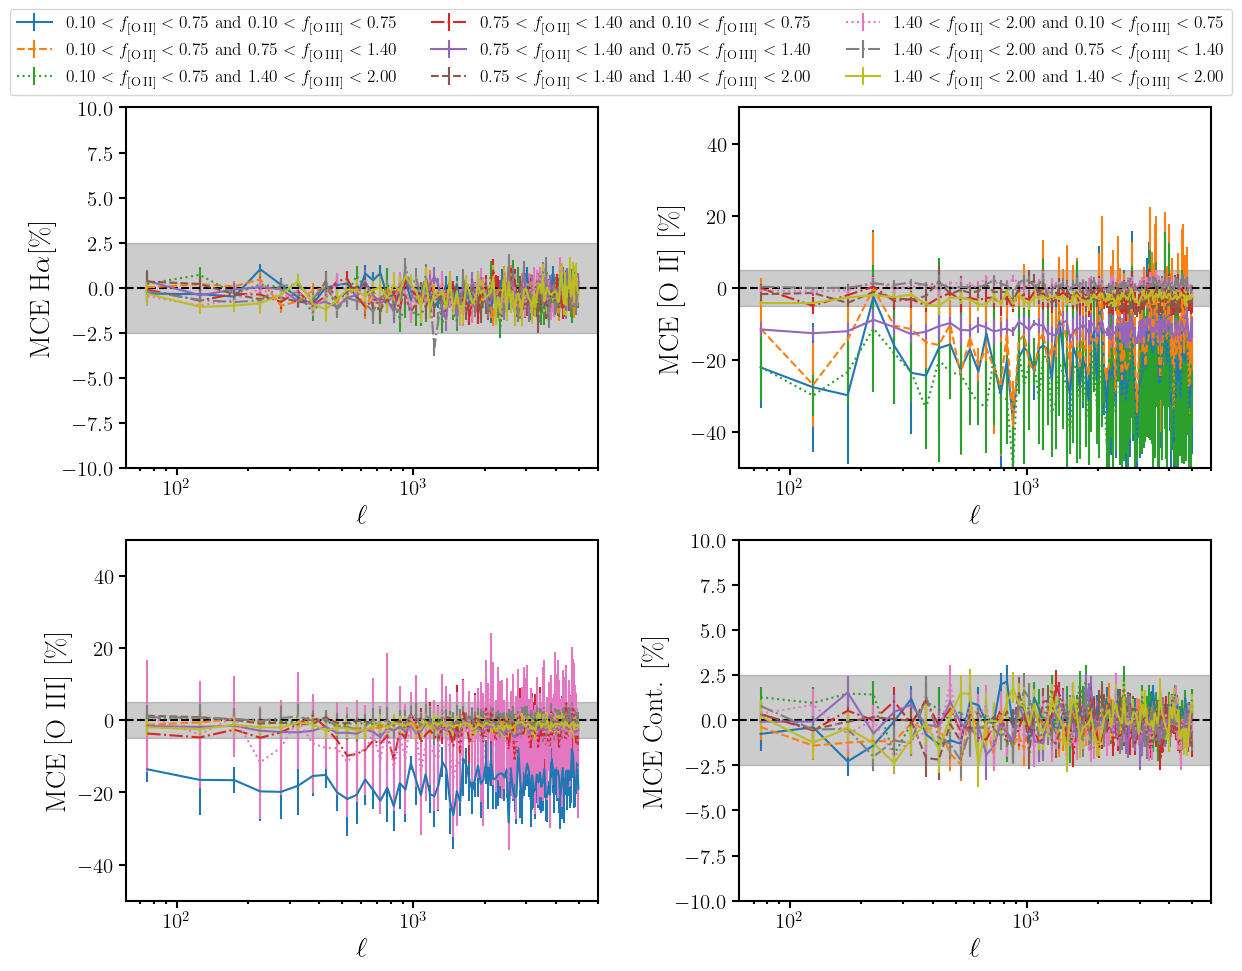

In [ ]:
Cl_int = np.load("Cl_Ha_0.npy")
ls = Cl_int[0,0,1:]

p_mean1, y_mean1, std_mean1, m1, sm1, N1 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 0.10, 0.10, 0.75, 0.75, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2, cont=True)
p_mean2, y_mean2, std_mean2, m2, sm2, N2 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 0.10, 0.75, 0.75, 1.40, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2, cont=True)
p_mean3, y_mean3, std_mean3, m3, sm3, N3 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 0.10, 1.40, 0.75, 2.00, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2, cont=True)
p_mean4, y_mean4, std_mean4, m4, sm4, N4 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 0.75, 0.10, 1.40, 0.75, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2, cont=True)
p_mean5, y_mean5, std_mean5, m5, sm5, N5 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 0.75, 0.75, 1.40, 1.40, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2, cont=True)
p_mean6, y_mean6, std_mean6, m6, sm6, N6 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 0.75, 1.40, 1.40, 2.00, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2, cont=True)
p_mean7, y_mean7, std_mean7, m7, sm7, N7 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 1.40, 0.10, 2.00, 0.75, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2, cont=True)
p_mean8, y_mean8, std_mean8, m8, sm8, N8 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 1.40, 0.75, 2.00, 1.40, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2, cont=True)
p_mean9, y_mean9, std_mean9, m9, sm9, N9 = plot_mean_error_f(test, model, 5000, ls, device, lenl, 1.40, 1.40, 2.00, 2.00, l_min=30, norm_Z=True, max_corr=max_corr, min_corr=min_corr, NZ=2, cont=True)

sel = (ls> 30.) & (ls < 5000)
l_plot = ls[sel]

fig, ax = plt.subplots(2, 2, figsize=(6*2+2, 4.5*2+1.3))

#Ha correction
ax[0,0].errorbar(l_plot, (1 - p_mean1[:lenl]/y_mean1[:lenl]) * 100., yerr=std_mean1[:lenl]/np.abs(y_mean1[:lenl])/np.sqrt(N1)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='solid')
ax[0,0].errorbar(l_plot, (1 - p_mean2[:lenl]/y_mean2[:lenl]) * 100., yerr=std_mean2[:lenl]/np.abs(y_mean2[:lenl])/np.sqrt(N2)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='dashed')
ax[0,0].errorbar(l_plot, (1 - p_mean3[:lenl]/y_mean3[:lenl]) * 100., yerr=std_mean3[:lenl]/np.abs(y_mean3[:lenl])/np.sqrt(N3)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='dotted')
ax[0,0].errorbar(l_plot, (1 - p_mean4[:lenl]/y_mean4[:lenl]) * 100., yerr=std_mean4[:lenl]/np.abs(y_mean4[:lenl])/np.sqrt(N4)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='dashdot')
ax[0,0].errorbar(l_plot, (1 - p_mean5[:lenl]/y_mean5[:lenl]) * 100., yerr=std_mean5[:lenl]/np.abs(y_mean5[:lenl])/np.sqrt(N5)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='solid')
ax[0,0].errorbar(l_plot, (1 - p_mean6[:lenl]/y_mean6[:lenl]) * 100., yerr=std_mean6[:lenl]/np.abs(y_mean6[:lenl])/np.sqrt(N6)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='dashed')
ax[0,0].errorbar(l_plot, (1 - p_mean7[:lenl]/y_mean7[:lenl]) * 100., yerr=std_mean7[:lenl]/np.abs(y_mean7[:lenl])/np.sqrt(N7)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='dotted')
ax[0,0].errorbar(l_plot, (1 - p_mean8[:lenl]/y_mean8[:lenl]) * 100., yerr=std_mean8[:lenl]/np.abs(y_mean8[:lenl])/np.sqrt(N8)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='dashdot')
ax[0,0].errorbar(l_plot, (1 - p_mean9[:lenl]/y_mean9[:lenl]) * 100., yerr=std_mean9[:lenl]/np.abs(y_mean9[:lenl])/np.sqrt(N9)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='solid')

ax[0,0].axhline(0, color='k', linestyle='dashed')
ax[0,0].set_xscale('log')
ax[0,0].set_xlabel('$\\ell$')
ax[0,0].set_ylim(-10,10)
ax[0,0].set_xlim(0.,6000)
ax[0,0].set_ylabel('''MCE H$\\alpha$[$\\%$]''')

ax[0,0].fill_between([0., 6000], -2.5, 2.5, alpha=.2, color='k')

ax[0,0].legend(ncols=3, loc='lower center', bbox_to_anchor=(1.05,1.01), fontsize=12.5)

#OII correction
ax[0,1].errorbar(l_plot, (1 - p_mean1[lenl:lenl*2]/y_mean1[lenl:lenl*2]) * 100., yerr=std_mean1[lenl:lenl*2]/np.abs(y_mean1[lenl:lenl*2])/np.sqrt(N1)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='solid')
ax[0,1].errorbar(l_plot, (1 - p_mean2[lenl:lenl*2]/y_mean2[lenl:lenl*2]) * 100., yerr=std_mean2[lenl:lenl*2]/np.abs(y_mean2[lenl:lenl*2])/np.sqrt(N2)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='dashed')
ax[0,1].errorbar(l_plot, (1 - p_mean3[lenl:lenl*2]/y_mean3[lenl:lenl*2]) * 100., yerr=std_mean3[lenl:lenl*2]/np.abs(y_mean3[lenl:lenl*2])/np.sqrt(N3)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='dotted')
ax[0,1].errorbar(l_plot, (1 - p_mean4[lenl:lenl*2]/y_mean4[lenl:lenl*2]) * 100., yerr=std_mean4[lenl:lenl*2]/np.abs(y_mean4[lenl:lenl*2])/np.sqrt(N4)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='dashdot')
ax[0,1].errorbar(l_plot, (1 - p_mean5[lenl:lenl*2]/y_mean5[lenl:lenl*2]) * 100., yerr=std_mean5[lenl:lenl*2]/np.abs(y_mean5[lenl:lenl*2])/np.sqrt(N5)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='solid')
ax[0,1].errorbar(l_plot, (1 - p_mean6[lenl:lenl*2]/y_mean6[lenl:lenl*2]) * 100., yerr=std_mean6[lenl:lenl*2]/np.abs(y_mean6[lenl:lenl*2])/np.sqrt(N6)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='dashed')
ax[0,1].errorbar(l_plot, (1 - p_mean7[lenl:lenl*2]/y_mean7[lenl:lenl*2]) * 100., yerr=std_mean7[lenl:lenl*2]/np.abs(y_mean7[lenl:lenl*2])/np.sqrt(N7)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='dotted')
ax[0,1].errorbar(l_plot, (1 - p_mean8[lenl:lenl*2]/y_mean8[lenl:lenl*2]) * 100., yerr=std_mean8[lenl:lenl*2]/np.abs(y_mean8[lenl:lenl*2])/np.sqrt(N8)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='dashdot')
ax[0,1].errorbar(l_plot, (1 - p_mean9[lenl:lenl*2]/y_mean9[lenl:lenl*2]) * 100., yerr=std_mean9[lenl:lenl*2]/np.abs(y_mean9[lenl:lenl*2])/np.sqrt(N9)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='solid')


ax[0,1].axhline(0, color='k', linestyle='dashed')
ax[0,1].set_xscale('log')
ax[0,1].set_xlabel('$\\ell$')
ax[0,1].set_ylim(-50,50)
ax[0,1].set_xlim(0.,6000)
ax[0,1].set_ylabel('''MCE [O II] [$\\%$]''')

ax[0,1].fill_between([0., 6000], -5, 5, alpha=.2, color='k')

#OIII correction
ax[1,0].errorbar(l_plot, (1 - p_mean1[lenl*2:lenl*3]/y_mean1[lenl*2:lenl*3]) * 100., yerr=std_mean1[lenl*2:lenl*3]/np.abs(y_mean1[lenl*2:lenl*3])/np.sqrt(N1)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='solid')
ax[1,0].errorbar(l_plot, (1 - p_mean2[lenl*2:lenl*3]/y_mean2[lenl*2:lenl*3]) * 100., yerr=std_mean2[lenl*2:lenl*3]/np.abs(y_mean2[lenl*2:lenl*3])/np.sqrt(N2)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='dashed')
ax[1,0].errorbar(l_plot, (1 - p_mean3[lenl*2:lenl*3]/y_mean3[lenl*2:lenl*3]) * 100., yerr=std_mean3[lenl*2:lenl*3]/np.abs(y_mean3[lenl*2:lenl*3])/np.sqrt(N3)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='dotted')
ax[1,0].errorbar(l_plot, (1 - p_mean4[lenl*2:lenl*3]/y_mean4[lenl*2:lenl*3]) * 100., yerr=std_mean4[lenl*2:lenl*3]/np.abs(y_mean4[lenl*2:lenl*3])/np.sqrt(N4)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='dashdot')
ax[1,0].errorbar(l_plot, (1 - p_mean5[lenl*2:lenl*3]/y_mean5[lenl*2:lenl*3]) * 100., yerr=std_mean5[lenl*2:lenl*3]/np.abs(y_mean5[lenl*2:lenl*3])/np.sqrt(N5)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='solid')
ax[1,0].errorbar(l_plot, (1 - p_mean6[lenl*2:lenl*3]/y_mean6[lenl*2:lenl*3]) * 100., yerr=std_mean6[lenl*2:lenl*3]/np.abs(y_mean6[lenl*2:lenl*3])/np.sqrt(N6)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='dashed')
ax[1,0].errorbar(l_plot, (1 - p_mean7[lenl*2:lenl*3]/y_mean7[lenl*2:lenl*3]) * 100., yerr=std_mean7[lenl*2:lenl*3]/np.abs(y_mean7[lenl*2:lenl*3])/np.sqrt(N7)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='dotted')
ax[1,0].errorbar(l_plot, (1 - p_mean8[lenl*2:lenl*3]/y_mean8[lenl*2:lenl*3]) * 100., yerr=std_mean8[lenl*2:lenl*3]/np.abs(y_mean8[lenl*2:lenl*3])/np.sqrt(N8)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='dashdot')
ax[1,0].errorbar(l_plot, (1 - p_mean9[lenl*2:lenl*3]/y_mean9[lenl*2:lenl*3]) * 100., yerr=std_mean9[lenl*2:lenl*3]/np.abs(y_mean9[lenl*2:lenl*3])/np.sqrt(N9)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='solid')


ax[1,0].axhline(0, color='k', linestyle='dashed')
ax[1,0].set_xscale('log')
ax[1,0].set_xlabel('$\\ell$')
ax[1,0].set_ylim(-50,50)
ax[1,0].set_xlim(0.,6000)
ax[1,0].set_ylabel('''MCE [O III] [$\\%$]''')

ax[1,0].fill_between([0., 6000], -5, 5, alpha=.2, color='k')

#Continuum correction
ax[1,1].errorbar(l_plot, (1 - p_mean1[lenl*3:lenl*4]/y_mean1[lenl*3:lenl*4]) * 100., yerr=std_mean1[lenl*3:lenl*4]/np.abs(y_mean1[lenl*3:lenl*4])/np.sqrt(N1)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='solid')
ax[1,1].errorbar(l_plot, (1 - p_mean2[lenl*3:lenl*4]/y_mean2[lenl*3:lenl*4]) * 100., yerr=std_mean2[lenl*3:lenl*4]/np.abs(y_mean2[lenl*3:lenl*4])/np.sqrt(N2)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='dashed')
ax[1,1].errorbar(l_plot, (1 - p_mean3[lenl*3:lenl*4]/y_mean3[lenl*3:lenl*4]) * 100., yerr=std_mean3[lenl*3:lenl*4]/np.abs(y_mean3[lenl*3:lenl*4])/np.sqrt(N3)*100., label='$0.10 < f_{\\rm [O\,II]} < 0.75$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='dotted')
ax[1,1].errorbar(l_plot, (1 - p_mean4[lenl*3:lenl*4]/y_mean4[lenl*3:lenl*4]) * 100., yerr=std_mean4[lenl*3:lenl*4]/np.abs(y_mean4[lenl*3:lenl*4])/np.sqrt(N4)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='dashdot')
ax[1,1].errorbar(l_plot, (1 - p_mean5[lenl*3:lenl*4]/y_mean5[lenl*3:lenl*4]) * 100., yerr=std_mean5[lenl*3:lenl*4]/np.abs(y_mean5[lenl*3:lenl*4])/np.sqrt(N5)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='solid')
ax[1,1].errorbar(l_plot, (1 - p_mean6[lenl*3:lenl*4]/y_mean6[lenl*3:lenl*4]) * 100., yerr=std_mean6[lenl*3:lenl*4]/np.abs(y_mean6[lenl*3:lenl*4])/np.sqrt(N6)*100., label='$0.75 < f_{\\rm [O\,II]} < 1.40$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='dashed')
ax[1,1].errorbar(l_plot, (1 - p_mean7[lenl*3:lenl*4]/y_mean7[lenl*3:lenl*4]) * 100., yerr=std_mean7[lenl*3:lenl*4]/np.abs(y_mean7[lenl*3:lenl*4])/np.sqrt(N7)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $0.10 < f_{\\rm [O\,III]} < 0.75$', linestyle='dotted')
ax[1,1].errorbar(l_plot, (1 - p_mean8[lenl*3:lenl*4]/y_mean8[lenl*3:lenl*4]) * 100., yerr=std_mean8[lenl*3:lenl*4]/np.abs(y_mean8[lenl*3:lenl*4])/np.sqrt(N8)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $0.75 < f_{\\rm [O\,III]} < 1.40$', linestyle='dashdot')
ax[1,1].errorbar(l_plot, (1 - p_mean9[lenl*3:lenl*4]/y_mean9[lenl*3:lenl*4]) * 100., yerr=std_mean9[lenl*3:lenl*4]/np.abs(y_mean9[lenl*3:lenl*4])/np.sqrt(N9)*100., label='$1.40 < f_{\\rm [O\,II]} < 2.00$ and $1.40 < f_{\\rm [O\,III]} < 2.00$', linestyle='solid')


ax[1,1].axhline(0, color='k', linestyle='dashed')
ax[1,1].set_xscale('log')
ax[1,1].set_xlabel('$\\ell$')
ax[1,1].set_ylim(-10,10)
ax[1,1].set_xlim(0.,6000)
ax[1,1].set_ylabel('''MCE Cont. [$\\%$]''')

ax[1,1].fill_between([0., 6000], -2.5, 2.5, alpha=.2, color='k')

plt.subplots_adjust(wspace=0.3)

#plt.savefig('../figures/MCE-scatter01-015Cont-multich.pdf', bbox_inches='tight')
plt.show()

##### Multiple trainings

1 64 32
2 32 16
3 16 32
4 32 64
5 64 128
6 128 256


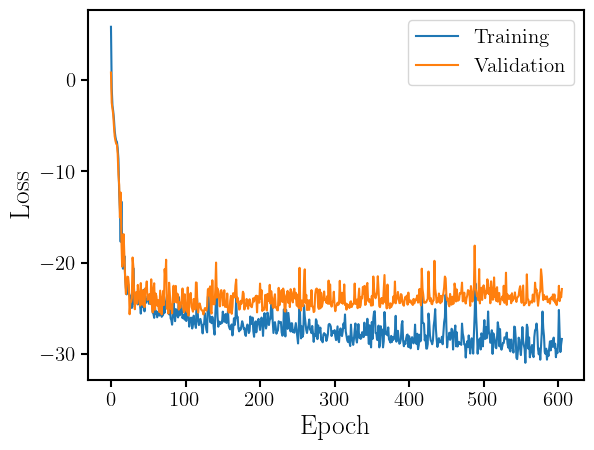

1 64 32
2 32 16
3 16 32
4 32 64
5 64 128
6 128 256


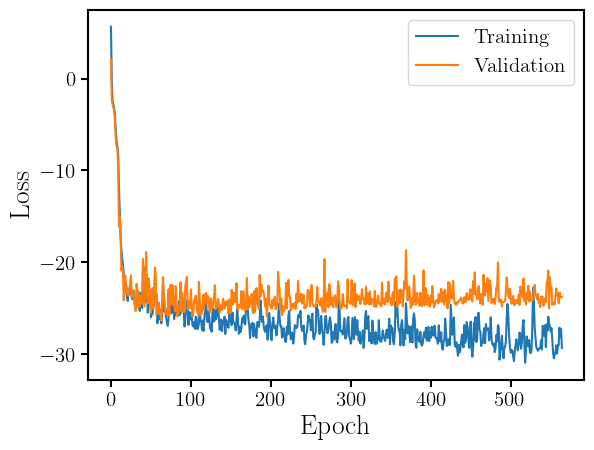

1 64 32
2 32 16
3 16 32
4 32 64
5 64 128
6 128 256


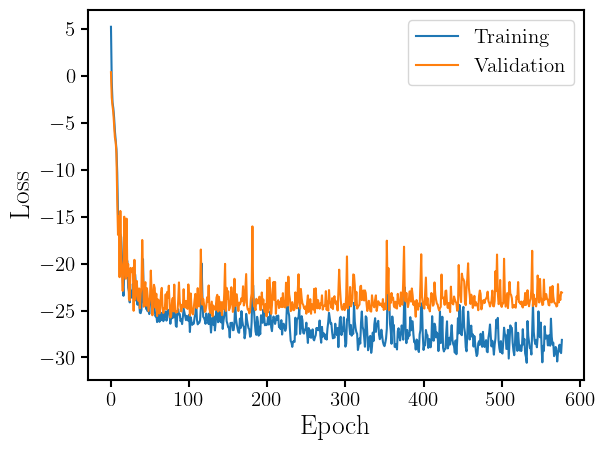

1 64 32
2 32 16
3 16 32
4 32 64
5 64 128
6 128 256


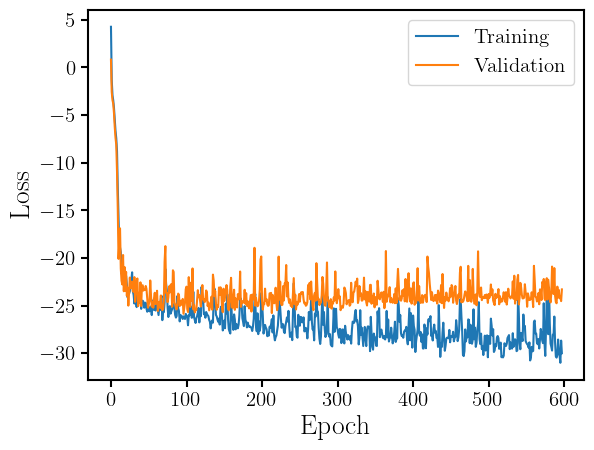

In [ ]:
dir = '../trained-models/Ha_OII_OIII_015Cont_scattered01-ch27-A27A38A51C38C51C49-l5e-2/NoLMItNet-Logloss-sb1024-component-corrections-moments-realization2/'

model2 = NLIM.NoLIMItNet_fraction_compress_inference(input_size, neurons, output_size, n_out, n_min, 2).to(device)
NIN.resume(model2, dir+"best_model-64.pth", device)

plot_history(dir)

dir = '../trained-models/Ha_OII_OIII_015Cont_scattered01-ch27-A27A38A51C38C51C49-l5e-2/NoLMItNet-Logloss-sb1024-component-corrections-moments-realization3/'

model3 = NLIM.NoLIMItNet_fraction_compress_inference(input_size, neurons, output_size, n_out, n_min, 2).to(device)
NIN.resume(model3, dir+"best_model-64.pth", device)

plot_history(dir)

dir = '../trained-models/Ha_OII_OIII_015Cont_scattered01-ch27-A27A38A51C38C51C49-l5e-2/NoLMItNet-Logloss-sb1024-component-corrections-moments-realization4/'

model4 = NLIM.NoLIMItNet_fraction_compress_inference(input_size, neurons, output_size, n_out, n_min, 2).to(device)
NIN.resume(model4, dir+"best_model-64.pth", device)

plot_history(dir)

dir = '../trained-models/Ha_OII_OIII_015Cont_scattered01-ch27-A27A38A51C38C51C49-l5e-2/NoLMItNet-Logloss-sb1024-component-corrections-moments-realization5/'

model5 = NLIM.NoLIMItNet_fraction_compress_inference(input_size, neurons, output_size, n_out, n_min, 2).to(device)
NIN.resume(model5, dir+"best_model-64.pth", device)

plot_history(dir)

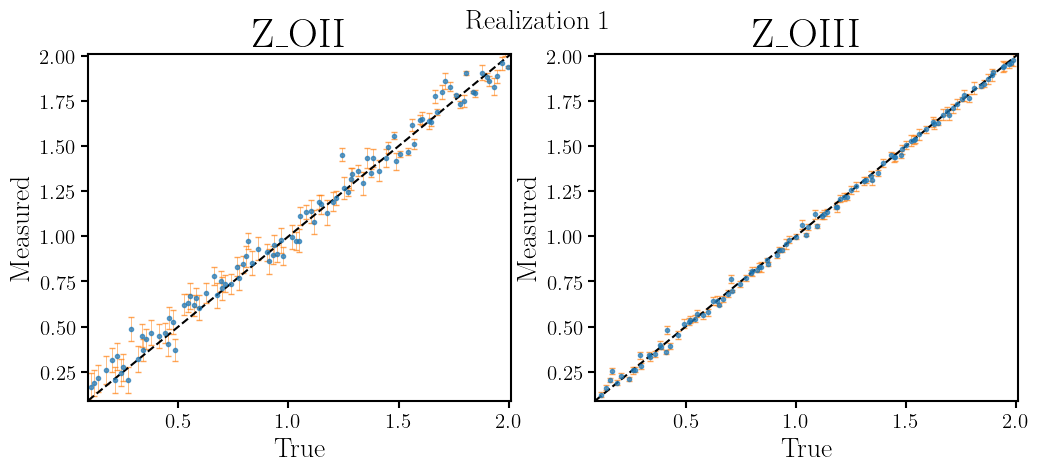

MSE error: 0.002598711


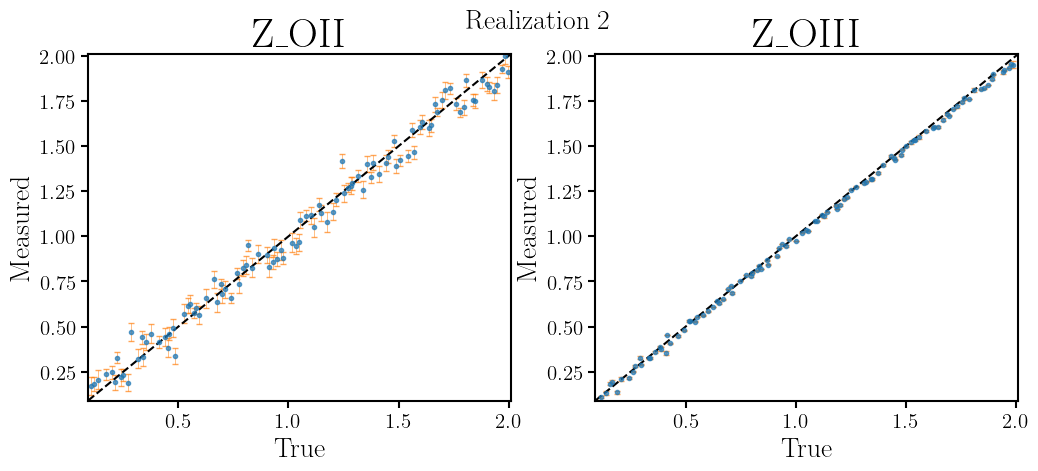

MSE error: 0.0023919735


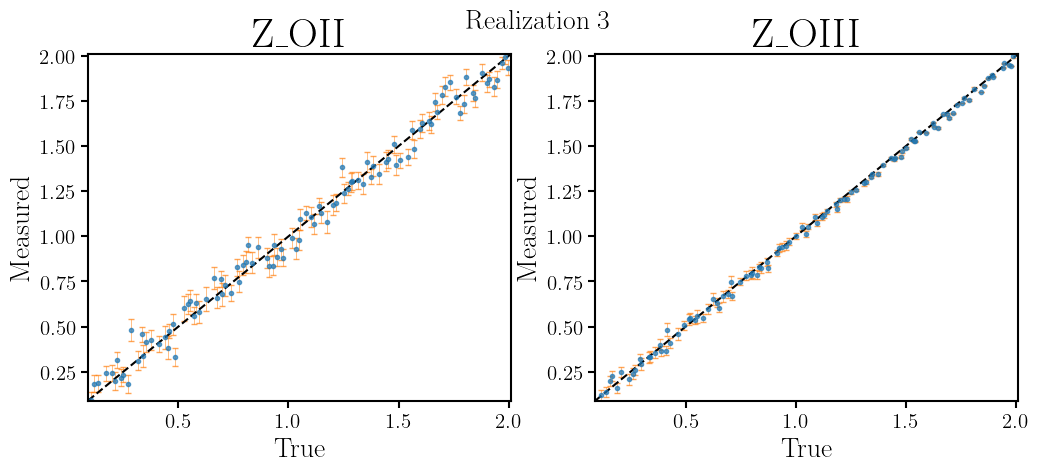

MSE error: 0.0023525488


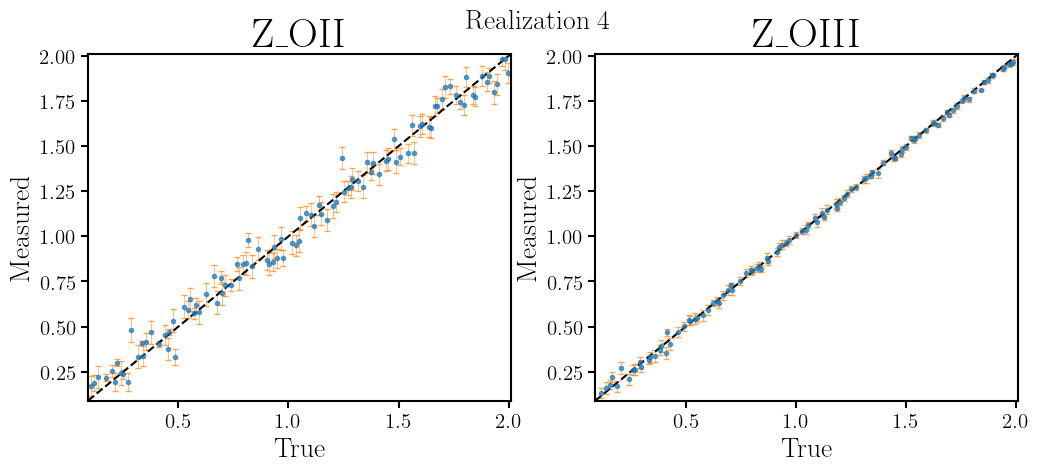

MSE error: 0.0023681894


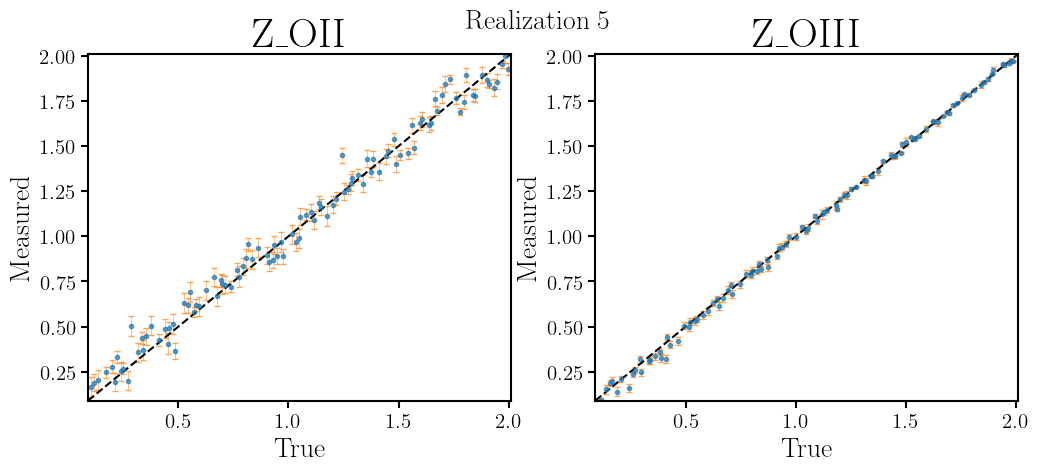

MSE error: 0.0026378022


In [46]:
plot_fraction(test, model, lenl=lenl, device=device, norm_Z=True, save=None, limits=[0.09, 2.01], title='Realization 1', Z_names=['Z_OII', 'Z_OIII'], Z_min=np.array([0.1,0.1]), Z_max=np.array([2.0,2.0]), NZ=2, cont=True)
plot_fraction(test, model2, lenl=lenl, device=device, norm_Z=True, save=None, limits=[0.09, 2.01], title='Realization 2', Z_names=['Z_OII', 'Z_OIII'], Z_min=np.array([0.1,0.1]), Z_max=np.array([2.0,2.0]), NZ=2, cont=True)
plot_fraction(test, model3, lenl=lenl, device=device, norm_Z=True, save=None, limits=[0.09, 2.01], title='Realization 3', Z_names=['Z_OII', 'Z_OIII'], Z_min=np.array([0.1,0.1]), Z_max=np.array([2.0,2.0]), NZ=2, cont=True)
plot_fraction(test, model4, lenl=lenl, device=device, norm_Z=True, save=None, limits=[0.09, 2.01], title='Realization 4', Z_names=['Z_OII', 'Z_OIII'], Z_min=np.array([0.1,0.1]), Z_max=np.array([2.0,2.0]), NZ=2, cont=True)
plot_fraction(test, model5, lenl=lenl, device=device, norm_Z=True, save=None, limits=[0.09, 2.01], title='Realization 5', Z_names=['Z_OII', 'Z_OIII'], Z_min=np.array([0.1,0.1]), Z_max=np.array([2.0,2.0]), NZ=2, cont=True)


In [101]:
MSE_chi2(test, model, lenl, device, norm_Z=True, thresh=1e-3, Z_min=np.array([0.1,0.1]), Z_max=np.array([2.0,2.0]), NZ=2, names=['OII', 'OIII'], comp=4)
MSE_chi2(test, model2, lenl, device, norm_Z=True, thresh=1e-3, Z_min=np.array([0.1,0.1]), Z_max=np.array([2.0,2.0]), NZ=2, names=['OII', 'OIII'], comp=4)
MSE_chi2(test, model3, lenl, device, norm_Z=True, thresh=1e-3, Z_min=np.array([0.1,0.1]), Z_max=np.array([2.0,2.0]), NZ=2, names=['OII', 'OIII'], comp=4)
MSE_chi2(test, model4, lenl, device, norm_Z=True, thresh=1e-3, Z_min=np.array([0.1,0.1]), Z_max=np.array([2.0,2.0]), NZ=2, names=['OII', 'OIII'], comp=4)
MSE_chi2(test, model5, lenl, device, norm_Z=True, thresh=1e-3, Z_min=np.array([0.1,0.1]), Z_max=np.array([2.0,2.0]), NZ=2, names=['OII', 'OIII'], comp=4)

OII
0
MSE: 0.0047548274
Reduced chi2: 7.060601391838592
OIII
0
MSE: 0.00044259042
Reduced chi2: 1.9432104906989534
OII
0
MSE: 0.004380693
Reduced chi2: 2.944364084780795
OIII
13
MSE: 0.0004009486
Reduced chi2: 39.86618249393204
OII
0
MSE: 0.0041842195
Reduced chi2: 1.7122208678606645
OIII
3
MSE: 0.0005305943
Reduced chi2: 16.569442600879853
OII
0
MSE: 0.0044073965
Reduced chi2: 2.76751946014108
OIII
0
MSE: 0.00032898228
Reduced chi2: 1.3675591922500758
OII
0
MSE: 0.0047664605
Reduced chi2: 3.0812742362902004
OIII
6
MSE: 0.00052591733
Reduced chi2: 1.7773729342858768


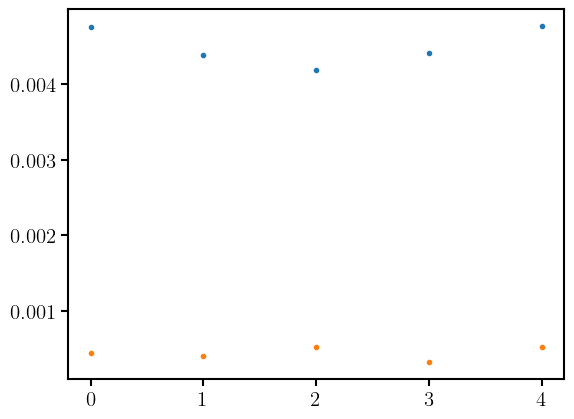

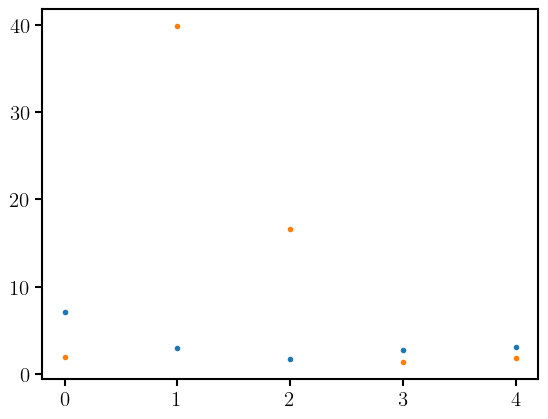

In [48]:
mseOII = [0.0047548274, 0.004380693, 0.0041842195, 0.0044073965, 0.0047664605]
chi2OII= [7.060601391838592, 2.944364084780795, 1.7122208678606645, 2.76751946014108,  3.0812742362902004]
mseOIII = [0.00044259042, 0.0004009486, 0.0005305943,  0.00032898228, 0.00052591733]
chi2OIII = [1.9432104906989534, 39.86618249393204, 16.569442600879853,  1.3675591922500758, 1.7773729342858768]

plt.plot(mseOII, '.')
plt.plot(mseOIII,'.')
plt.show()

plt.plot(chi2OII, '.')
plt.plot(chi2OIII, '.')
plt.show()

/tmp/ipykernel_24894/3672489142.py:22: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax[row,0].set_xlim(0.,6000)
/tmp/ipykernel_24894/3672489142.py:40: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax[row,1].set_xlim(0.,6000)
/tmp/ipykernel_24894/3672489142.py:58: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax[row,2].set_xlim(0.,6000)
/tmp/ipykernel_24894/3672489142.py:76: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax[row,3].set_xlim(0.,6000)


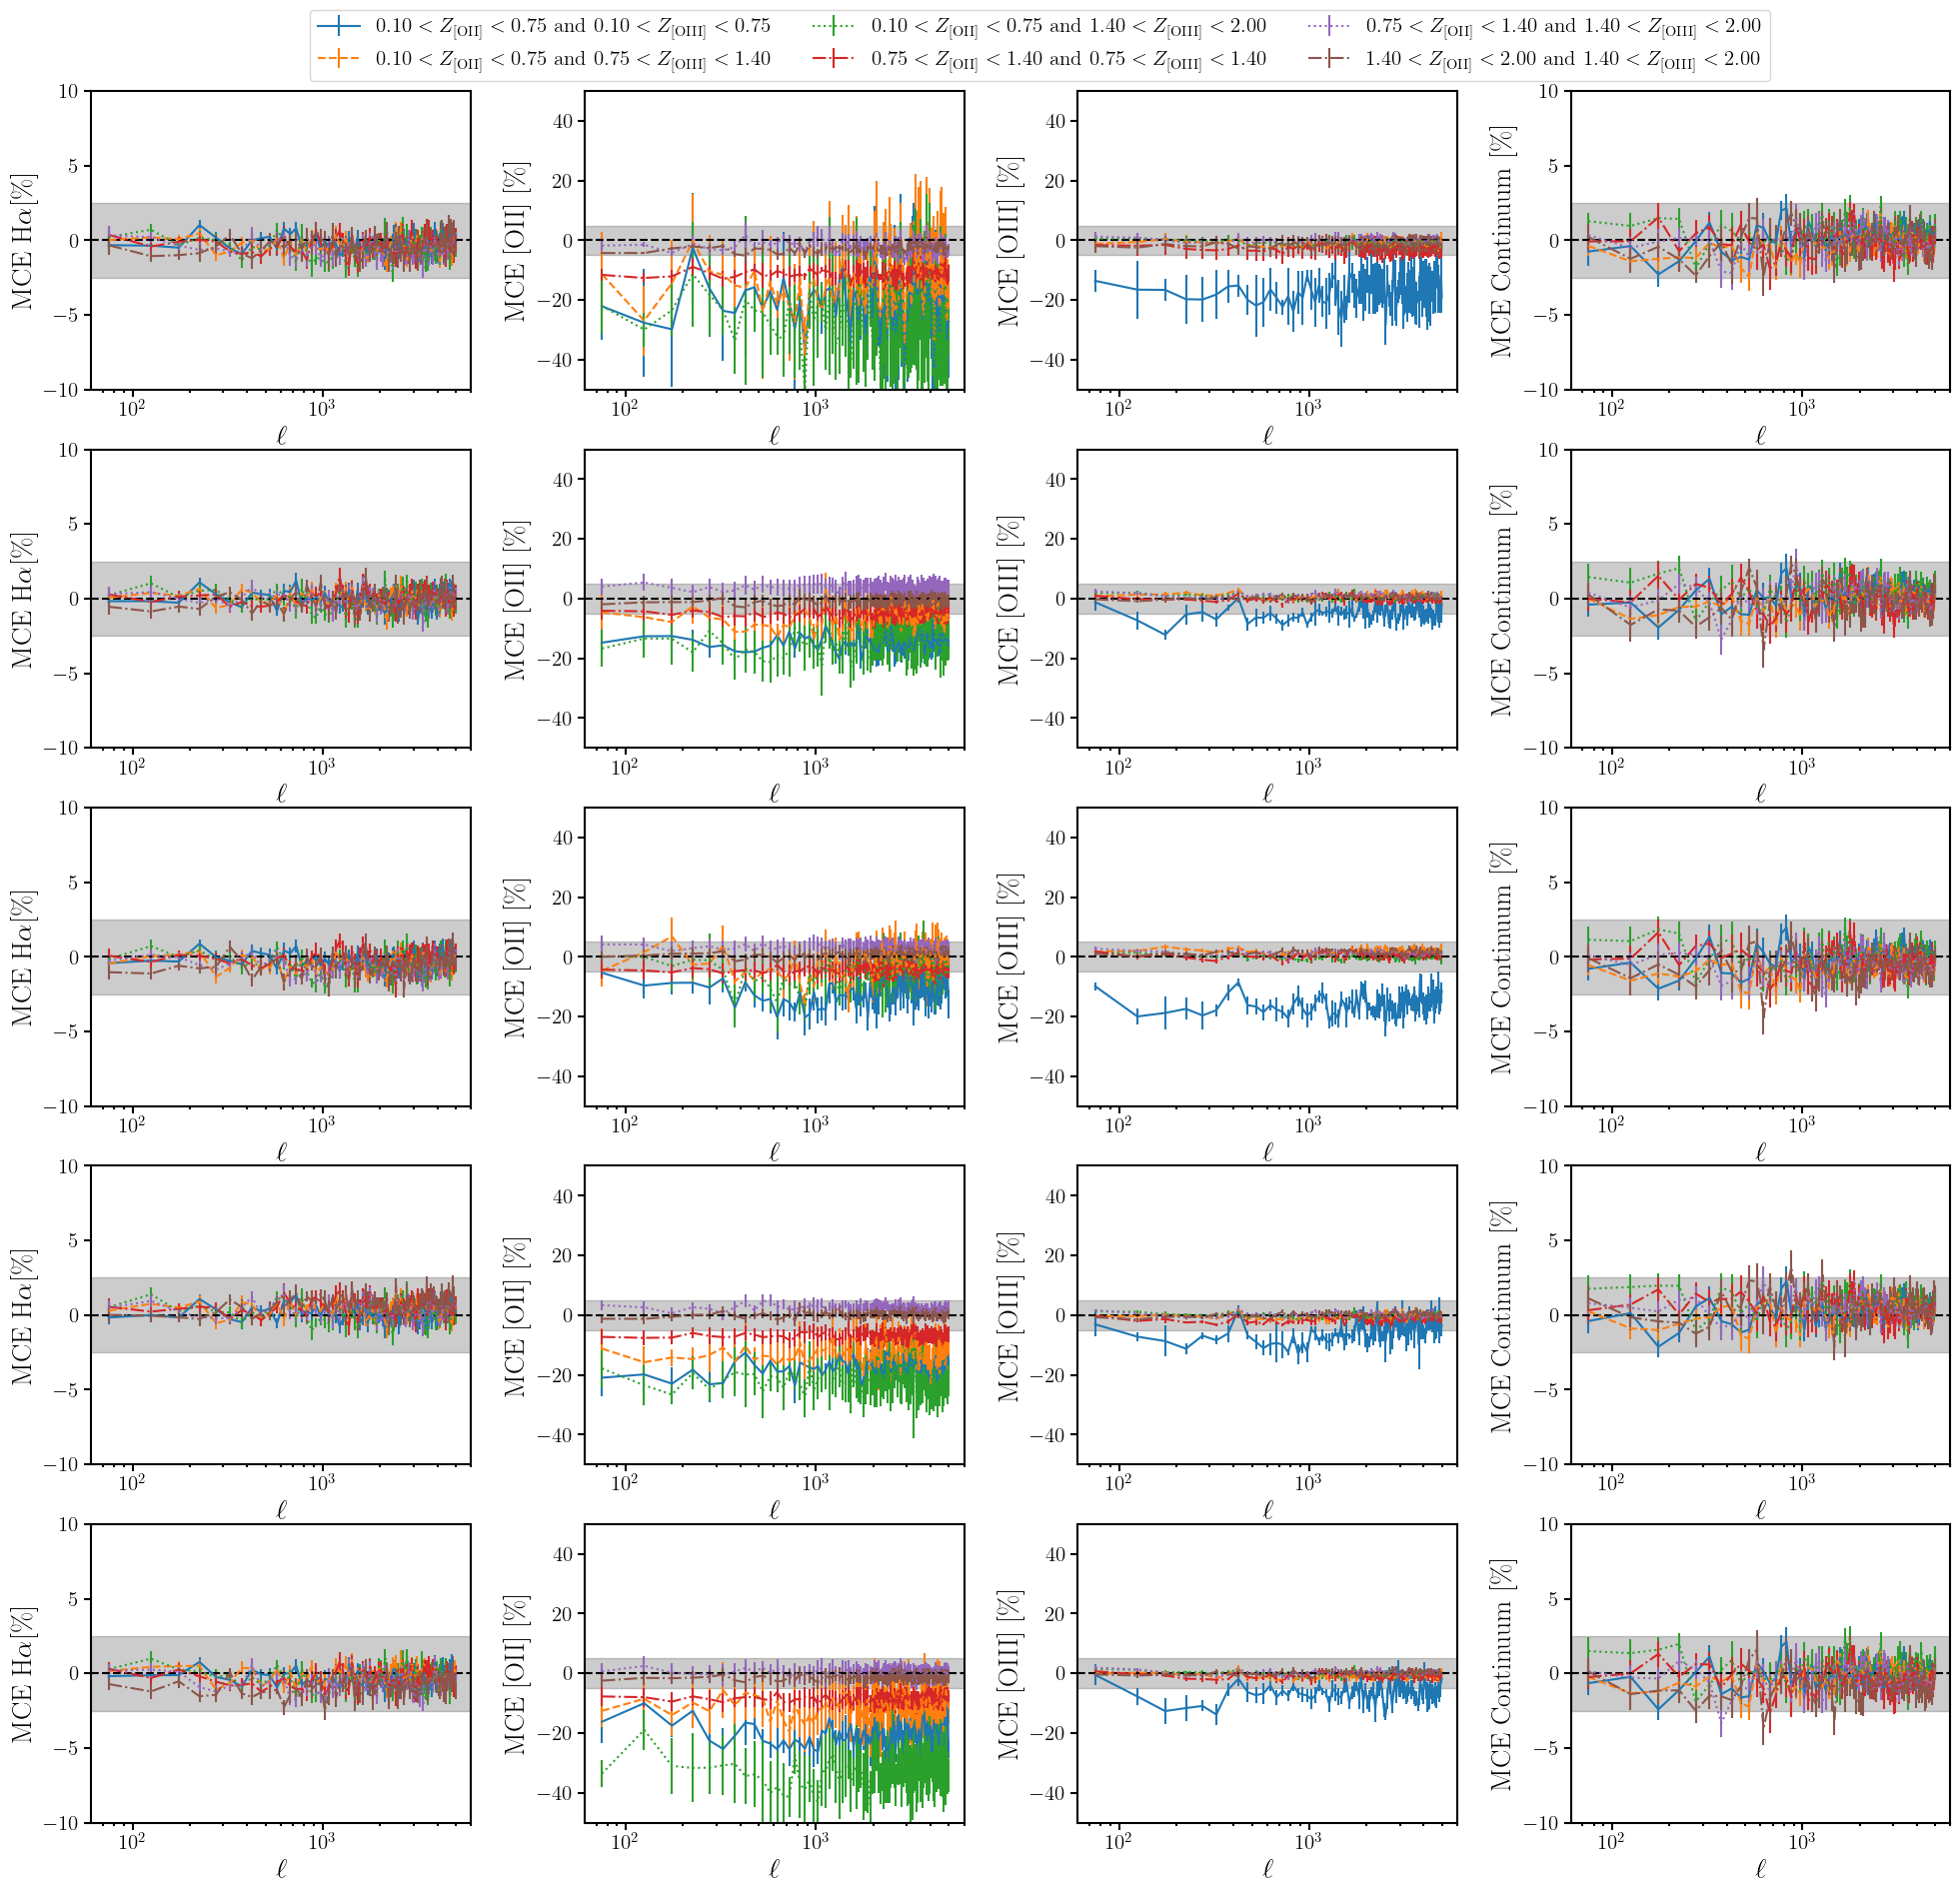

In [ ]:
Cl_int = np.load("/home/cagliari/Documents/Work/LAPTh/Cls/Ha/Cl_Ha_0.npy")
ls = Cl_int[0,0,1:]

sel = (ls> 30.) & (ls < 5000)
l_plot = ls[sel]

fig, ax = plt.subplots(5, 4, figsize=(6*4, 4.5*5))

MCE_multiple_realizations(model, 0, ax, l_plot, lenl, test, ls, device, max_corr, min_corr)
ax[0,0].legend(ncols=3, loc='lower center', bbox_to_anchor=(2.5,0.999))
MCE_multiple_realizations(model2, 1, ax, l_plot, lenl, test, ls, device, max_corr, min_corr)
MCE_multiple_realizations(model3, 2, ax, l_plot, lenl, test, ls, device, max_corr, min_corr)
MCE_multiple_realizations(model4, 3, ax, l_plot, lenl, test, ls, device, max_corr, min_corr)
MCE_multiple_realizations(model5, 4, ax, l_plot, lenl, test, ls, device, max_corr, min_corr)

plt.subplots_adjust(wspace=0.3)

plt.show()